#### Machine Learning Model To Predict The Success Of Bank Telemarketing Calls

Telemarketing contact is one of the primary ways banks approach customers in order to sell their products and, as such, is an important factor to optimize such businesses' operations.

In that spirit, the following project takes extensive direct marketing phone-call campaigns' information from a Portuguese bank, gathered from the period of May 2008 until November 2010 and formulates two classification machine learning models, each predicting a Yes or No response to the question: Will this client subscribe to a long-term deposit with the bank?

Those models will help the bank to employ better customer-targeting techniques in the future and increase the chances of an increased ROI related to such campaigns. Specifically, they can be defined as follows:

*   The Actionable Model: our primary, deployable model, which categorizes each customer as a buyer, or not, of the bank's long-term deposit with a "Yes", or a "No", respectively. This model requires for us to drop the column "duration" from consideration, as we'd want our predictions to be suitable for pre-call analysis, and that column is populated with the time-duration values of each call, which naturally can only be known after call-contact has been established and finished. The column's inclusion would introduce pernicious "data-leakage" into our model.
*   The Benchmarking Model: this non-deployable model serves as mere academical comparison to our Actionable Model, by showing how far off the latter's predictions are from those done under the better - but unsuitable for the Actional Model - conditions of the Benchmarking Model, those being the inclusion of the "duration" column.

### 1. Data Importing & Initial Data Preprocessing

In [3]:
# Libraries to import:



import pandas as pd
import numpy as np
from pathlib import Path

from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import roc_auc_score, average_precision_score, brier_score_loss, precision_recall_curve

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

USE_LGBM = True
try:
    from lightgbm import LGBMClassifier
    USE_LGBM = True
except Exception:
    pass

SEED = 42
np.random.seed(SEED)



In [6]:
# Importing and visualization of the dataset

# Out of the 4 different datasets we could have worked on, we've chosen to work on "bank-additional-full" as our sole source of data.

# We did so because the latter's the most complete out of those 4 datasets and any dataset-merging was ruled out due to the fact there isn't a way of uniquely identifying each row on the datasets we'd merge, a necessary condition for a fully trustworthy merge.

# Indeed, datasets "bank" and "bank-full" both lack 5 macroeconomic metrics that are present on both "bank-additional" and "bank-additional-full":

#   -> emp.var.rate
#   -> cons.price.idx
#   -> cons.conf.idx
#   -> euribor3m
#   -> nr.employed

# Additionally, "bank-additional", which also has those aforecited 5 macroeconomic metrics, has only a small fraction of the contacts' data that "bank-additional-full" has.

# Therefore, naturally, "bank-additional-full" is our best option as source of input.

path = r'C:\Users\DELL\OneDrive\Data Science\Bank_Telemarketing_Prediction_EDSB25_1\data\raw\bank-additional-full.csv'
df = pd.read_csv(path, sep=';')



# quick check
print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [7]:
# Basic sanitary data preprocessing on the dataset

df.columns = [c.strip().replace('.', '_') for c in df.columns]
df['y'] = (df['y'].str.lower().str.strip() == 'yes').astype(int)

print(df.shape)
df.head()

(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp_var_rate    41188 non-null  float64
 16  cons_price_idx  41188 non-null  float64
 17  cons_conf_idx   41188 non-null 

In [9]:
 # Definition of what columns should be included in either of the above-described models

categoricals = ["job","marital","education","default","housing","loan","contact","month","day_of_week","poutcome"]
numericals = ["age","campaign","pdays","previous","emp_var_rate","cons_price_idx","cons_conf_idx","euribor3m","nr_employed"]

X_act = df[categoricals + numericals].copy()   # actionable (no duration)
X_bmk = df[categoricals + ["duration"] + numericals].copy()  # benchmark (with duration)
y = df["y"].values

In [10]:
# Combine X_act with y using assign
df_act = X_act.assign(y=y)

# Inspect
df_act.head()


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,57,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,37,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,40,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,56,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0


In [11]:
# Data preprocessing:

#ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=True)
#scaler = StandardScaler()

# actionable: no 'duration'
#preprocess_act = ColumnTransformer([
 #   ("cat", ohe, categoricals),
  #  ("num", scaler, numericals),
#])

# benchmark: includes 'duration' as numeric
#numericals_bmk = numericals + ["duration"]
#preprocess_bmk = ColumnTransformer([
 #   ("cat", ohe, categoricals),
  #  ("num", scaler, numericals_bmk),
#])



In [12]:
## PROFESSOR SAID BE CAREFUL WITH DATA LEAKAGE AND STUDY IMBALANCE (SEE IF THE LATER EXISTS OR IT DOESN'T AND THEN TREAT IT)

## PROFESSOR ALSO SAID THAT WE SHOULD PRESENT THE CONFUSION MATRIXES FOR THE TRAINING SET (IN-SAMPLE DATA) AND FOR THE TESTING SET (OUT-OF-SAMPLE DATA)

### 2. Exploratory Data Analysis (EDA) & Further Data Preprocessing


In [13]:
# Treatment Of Potentially-Existing Missing Values:

print("Missing values before handling:")
print(df_act.isnull().sum())

Missing values before handling:
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
poutcome          0
age               0
campaign          0
pdays             0
previous          0
emp_var_rate      0
cons_price_idx    0
cons_conf_idx     0
euribor3m         0
nr_employed       0
y                 0
dtype: int64


In [14]:
# Description of each numerical column's metadata (count, mean, std, quartiles, min/max)

print("\nDescriptive statistics for numerical columns:")
df_act.describe()


Descriptive statistics for numerical columns:


,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911,0.112654
std,10.42125,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528,0.316173
min,17.00000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000,0.000000
25%,32.00000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000,0.000000
50%,38.00000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000,0.000000
75%,47.00000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000,0.000000
max,98.00000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000,1.000000


In [15]:
# Identification Of Each Column's Type

df_act.dtypes

job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
poutcome           object
age                 int64
campaign            int64
pdays               int64
previous            int64
emp_var_rate      float64
cons_price_idx    float64
cons_conf_idx     float64
euribor3m         float64
nr_employed       float64
y                   int64
dtype: object

In [ ]:
df_act.columns


Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'age', 'campaign', 'pdays',
       'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx',
       'euribor3m', 'nr_employed', 'y'],
      dtype='object')

In [18]:
#!pip install ydata-profiling

from pandas_profiling import ProfileReport

profile = ProfileReport(df_act, title="Pandas Profiling Report", explorative=True)
profile

ModuleNotFoundError: No module named 'pkg_resources'

In [19]:
duplicates = df_act[df_act.duplicated()]
duplicates

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,age,campaign,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y
10,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,nonexistent,41,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
11,services,single,high.school,no,yes,no,telephone,may,mon,nonexistent,25,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
16,blue-collar,married,basic.6y,no,yes,no,telephone,may,mon,nonexistent,35,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
31,technician,married,unknown,no,yes,no,telephone,may,mon,nonexistent,59,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
104,admin.,divorced,university.degree,no,no,no,telephone,may,mon,nonexistent,52,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39985,admin.,single,high.school,no,no,no,cellular,jun,tue,nonexistent,27,2,999,0,-1.7,94.055,-39.8,0.761,4991.6,1
40401,student,single,unknown,no,yes,no,cellular,aug,thu,nonexistent,31,2,999,0,-1.7,94.027,-38.3,0.904,4991.6,1
40404,entrepreneur,married,university.degree,no,yes,no,cellular,aug,thu,nonexistent,41,1,999,0,-1.7,94.027,-38.3,0.904,4991.6,1
40806,technician,married,professional.course,no,yes,no,cellular,sep,thu,failure,35,1,999,2,-1.1,94.199,-37.5,0.878,4963.6,0


In [20]:
# Elimination Of Duplicate Rows

df_act.drop_duplicates(inplace=True)


In [21]:
# Confirmation That The Elimination of Duplicate Rows From The Dataframe That'll Serve As Basis For Our Actionable Model Was Done Correctly

num_duplicates = df_act.duplicated().sum()
print(f"Number of duplicate rows: {num_duplicates}")

Number of duplicate rows: 0


In [22]:
# Cap outliers in numerical columns
for col in ['campaign', 'previous']:
    upper_bound = df_act[col].quantile(0.99)
    df_act[col] = np.where(df_act[col] > upper_bound, upper_bound, df_act[col])


# Check value counts for categorical columns to identify inconsistencies
categorical_cols = df_act.select_dtypes(include='object').columns
numerical_cols = df_act.select_dtypes(include='int').columns

print("\nValue counts for categorical columns:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df_act[col].value_counts())


Value counts for categorical columns:

Column: job
job
admin.           9873
blue-collar      8835
technician       6404
services         3801
management       2820
retired          1683
entrepreneur     1405
self-employed    1386
housemaid        1028
unemployed        992
student           852
unknown           325
Name: count, dtype: int64

Column: marital
marital
married     23869
single      10997
divorced     4459
unknown        79
Name: count, dtype: int64

Column: education
education
university.degree      11561
high.school             9121
basic.9y                5785
professional.course     5018
basic.4y                3993
basic.6y                2222
unknown                 1686
illiterate                18
Name: count, dtype: int64

Column: default
default
no         31135
unknown     8266
yes            3
Name: count, dtype: int64

Column: housing
housing
yes        20561
no         17863
unknown      980
Name: count, dtype: int64

Column: loan
loan
no         32248
yes 

In [23]:
# Create 'age_group' feature
# An 'age_group' feature that bins age allows ML models to capture differences in age between broad groups instead of forcing them to learn complex non-linear splits
bins = [0, 25, 50, 75, 100]
labels = ['youth', 'adult', 'senior', 'elderly']
df_act['age_group'] = pd.cut(df_act['age'], bins=bins, labels=labels, right=False)

# Create interaction term for 'housing' and 'loan'
# It's good practice as some ML models don't learn interactions unless explicitly stated
# Plus, explicitly stating this interaction is a potential improvement factor for ML models' performance, even if they intuitively do learn interactions already
df_act['housing_loan_interaction'] = df_act['housing'] + '_' + df_act['loan']

print(df_act.shape)
df_act.head(5)

(39404, 22)


,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,...,pdays,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,age_group,housing_loan_interaction
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,...,999,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_no
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,...,999,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_no
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,...,999,0.0,1.1,93.994,-36.4,4.857,5191.0,0,adult,yes_no
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,...,999,0.0,1.1,93.994,-36.4,4.857,5191.0,0,adult,no_no
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,...,999,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_yes


In [25]:
# Inputting the marital column's mode on its very small fraction of unknown values

mode_val = df_act['marital'].mode().iloc[0]
df_act['marital'] = df_act['marital'].replace('unknown', mode_val)


In [26]:
df_act["education"].value_counts()

education
university.degree      11561
high.school             9121
basic.9y                5785
professional.course     5018
basic.4y                3993
basic.6y                2222
unknown                 1686
illiterate                18
Name: count, dtype: int64

In [27]:

# Performance Of Feature Engineering On Column 'pdays', Namely Replacing The Misleading '999' Value By 'Never Contacted' And Binning The Remaining Values
# This Categorical Segmentation Is More Informative (Because More Intuitively Understood) For Whomever's Reading The Associated Report And Easier For ML Models To Use

# Step 1: Create a new column
df_act['pdays_cat'] = df_act['pdays']

# Step 2: Replace 999 with a string label
df_act['pdays_cat'] =df_act['pdays_cat'].replace(999, 'never_contacted')

# Step 3: Bin the remaining numeric values
df_act.loc[df_act['pdays_cat'] != 'never_contacted', 'pdays_cat'] = pd.cut(
    df_act.loc[df_act['pdays_cat'] != 'never_contacted', 'pdays_cat'].astype(int),
    bins=[-1, 3, 7, 15, np.inf],
    labels=['0-3', '4-7', '8-15', '16+']
)

# Step 4: Convert to category dtype (optional but recommended)
df_act['pdays_cat'] = df_act['pdays_cat'].astype('category')

# Step 5: Drop the original pdays column
df_act = df_act.drop(columns=['pdays'])

df_act[['pdays_cat']].value_counts(dropna=False)

pdays_cat      
never_contacted    37890
4-7                  636
0-3                  540
8-15                 300
16+                   38
Name: count, dtype: int64

In [28]:
df_act

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,...,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,age_group,housing_loan_interaction,pdays_cat
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_no,never_contacted
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_no,never_contacted
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,adult,yes_no,never_contacted
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,adult,no_no,never_contacted
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_yes,never_contacted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,...,0.0,-1.1,94.767,-50.8,1.028,4963.6,1,senior,yes_no,never_contacted
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,...,0.0,-1.1,94.767,-50.8,1.028,4963.6,0,adult,no_no,never_contacted
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,...,0.0,-1.1,94.767,-50.8,1.028,4963.6,0,senior,yes_no,never_contacted
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,...,0.0,-1.1,94.767,-50.8,1.028,4963.6,1,adult,no_no,never_contacted


In [29]:
print("\nValue counts for engineered categorical columns:")
for col in ['age_group', 'housing_loan_interaction']:
    print(f"\nColumn: {col}")
    print(df_act[col].value_counts())

print("\nData types of all columns:")
print(df_act.dtypes)


features_to_drop = ['default']

# Create the list of features to keep
features_to_keep = [col for col in df_act.columns if col not in features_to_drop + ['y']]

print(f"\nFeatures to drop: {features_to_drop}")
print(f"\nFeatures to keep ({len(features_to_keep)}): {features_to_keep}")


Value counts for engineered categorical columns:

Column: age_group
age_group
adult      30558
senior      7558
youth       1024
elderly      264
Name: count, dtype: int64

Column: housing_loan_interaction
housing_loan_interaction
yes_no             16917
no_no              15331
yes_yes             3644
no_yes              2532
unknown_unknown      980
Name: count, dtype: int64

Data types of all columns:
job                           object
marital                       object
education                     object
default                       object
housing                       object
loan                          object
contact                       object
month                         object
day_of_week                   object
poutcome                      object
age                            int64
campaign                     float64
previous                     float64
emp_var_rate                 float64
cons_price_idx               float64
cons_conf_idx                float

### 3. Chart-Plotting & Calculation Of Conversion Rates Per Each Value On Each Apt Column

Descriptive statistics for numerical features:
                age      campaign      previous  emp_var_rate  cons_price_idx  \
count  39404.000000  39404.000000  39404.000000  39404.000000    39404.000000   
mean      40.116105      2.558420      0.167699      0.064067       93.577538   
std       10.460328      2.385593      0.439868      1.577041        0.583820   
min       17.000000      1.000000      0.000000     -3.400000       92.201000   
25%       32.000000      1.000000      0.000000     -1.800000       93.075000   
50%       38.000000      2.000000      0.000000      1.100000       93.798000   
75%       47.000000      3.000000      0.000000      1.400000       93.994000   
max       98.000000     15.000000      2.000000      1.400000       94.767000   

       cons_conf_idx     euribor3m   nr_employed  
count   39404.000000  39404.000000  39404.000000  
mean      -40.499604      3.601243   5165.986481  
std         4.644327      1.742337     72.763866  
min       -50.80000

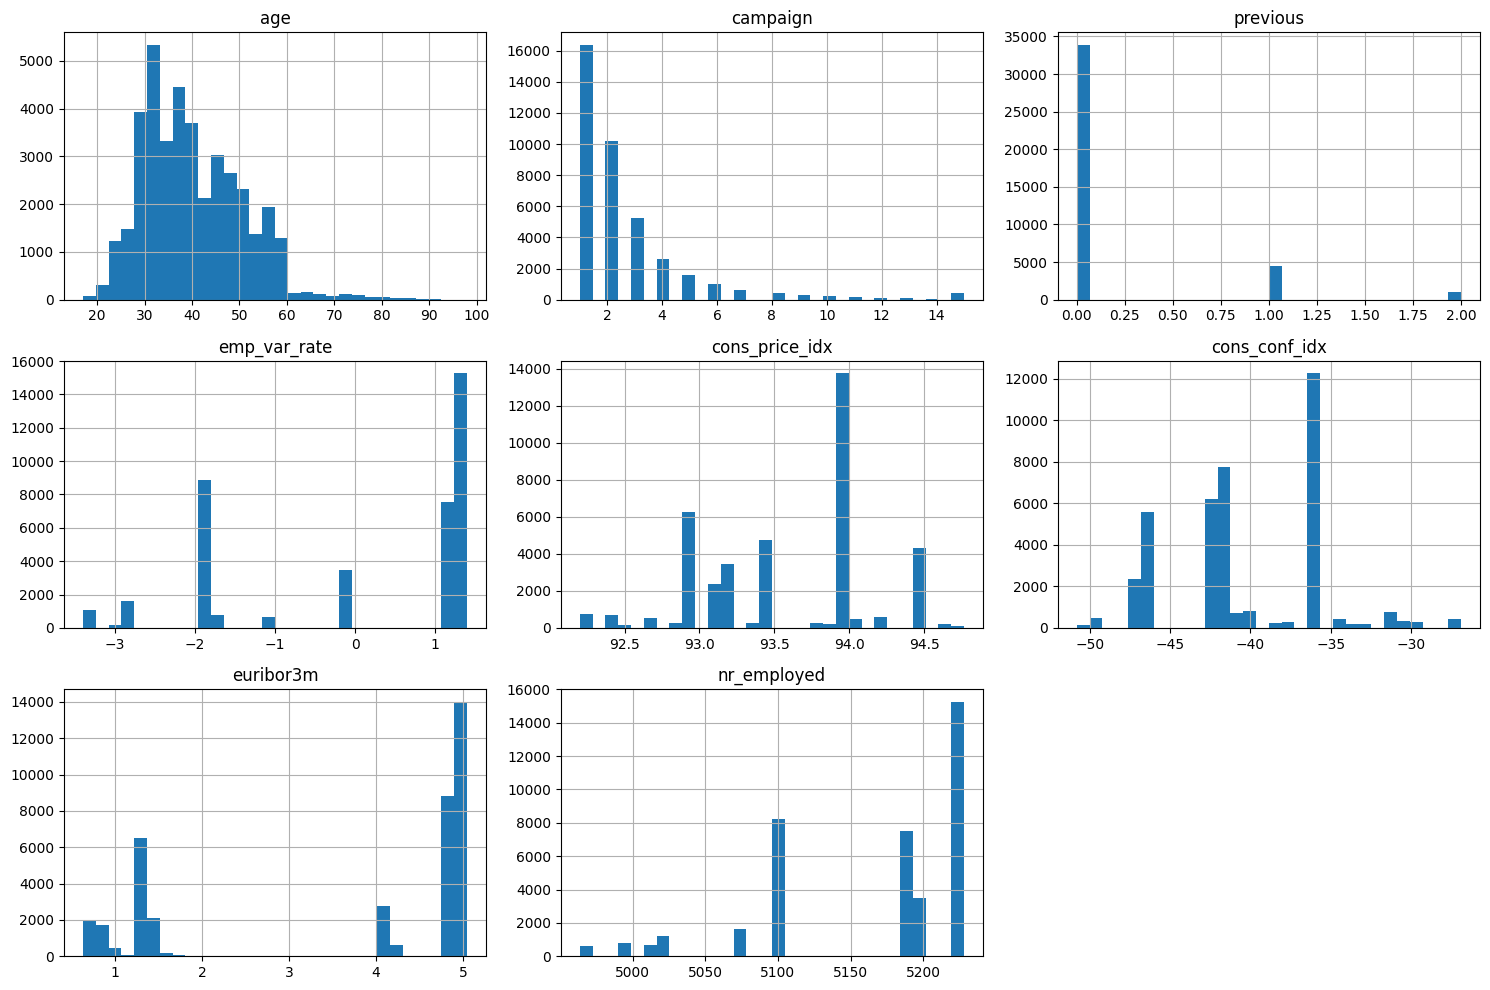

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_cols = ["age", "campaign", "previous", "emp_var_rate",
                  "cons_price_idx", "cons_conf_idx", "euribor3m",
                  "nr_employed"]   # removed pdays

categorical_cols = ["job", "marital", "education", "default",
                    "housing", "loan", "contact", "month",
                    "day_of_week", "poutcome", "pdays_cat", "age_group",
                    "housing_loan_interaction"]

# Analyze numerical features
print("Descriptive statistics for numerical features:")
print(df_act[numerical_cols].describe())

# Plot histograms for numerical features
df_act[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.tight_layout()
plt.show()


Value counts for categorical features:

Column: job
job
admin.           9873
blue-collar      8835
technician       6404
services         3801
management       2820
retired          1683
entrepreneur     1405
self-employed    1386
housemaid        1028
unemployed        992
student           852
unknown           325
Name: count, dtype: int64


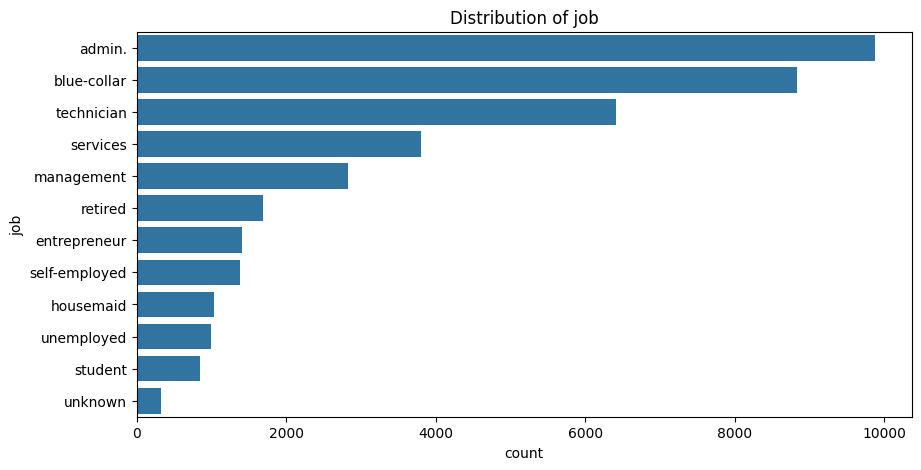


Column: marital
marital
married     23948
single      10997
divorced     4459
Name: count, dtype: int64


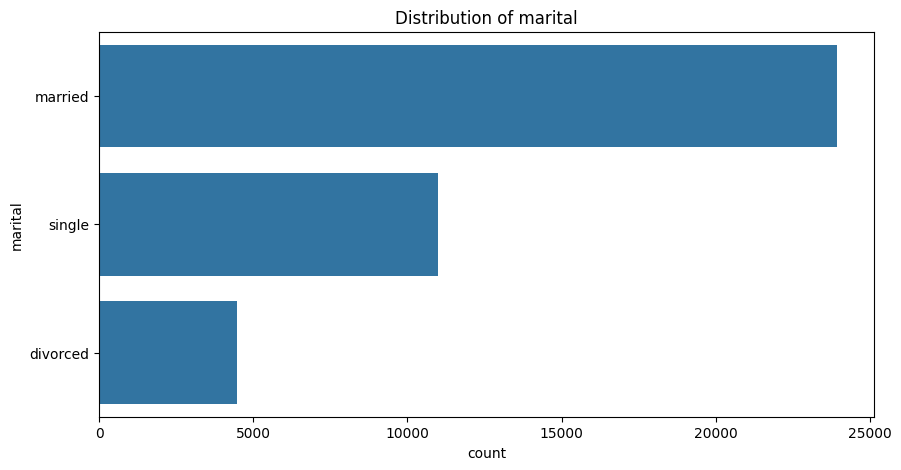


Column: education
education
university.degree      11561
high.school             9121
basic.9y                5785
professional.course     5018
basic.4y                3993
basic.6y                2222
unknown                 1686
illiterate                18
Name: count, dtype: int64


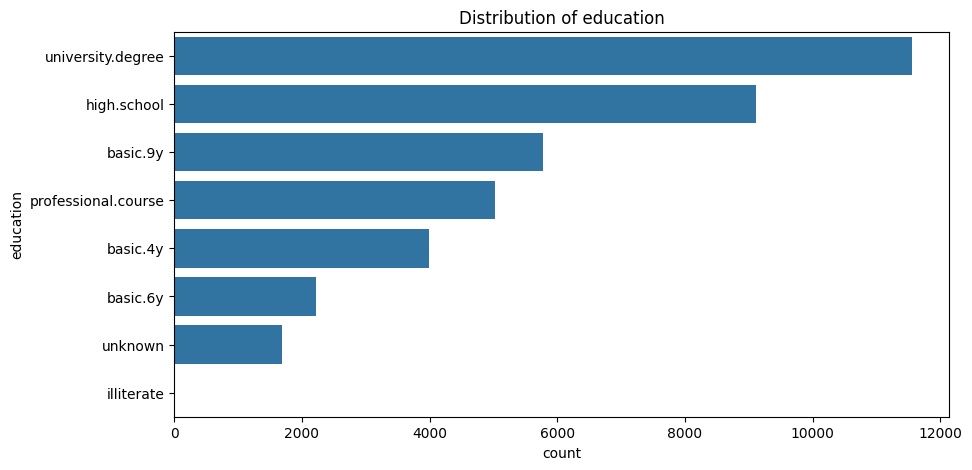


Column: default
default
no         31135
unknown     8266
yes            3
Name: count, dtype: int64


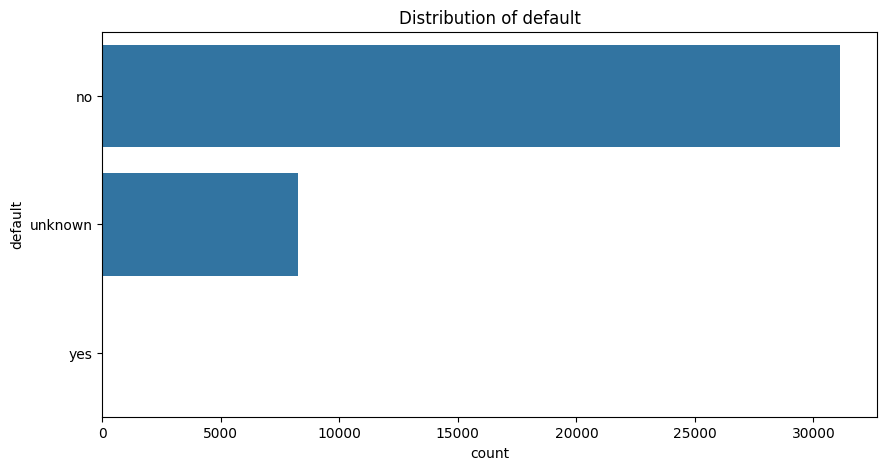


Column: housing
housing
yes        20561
no         17863
unknown      980
Name: count, dtype: int64


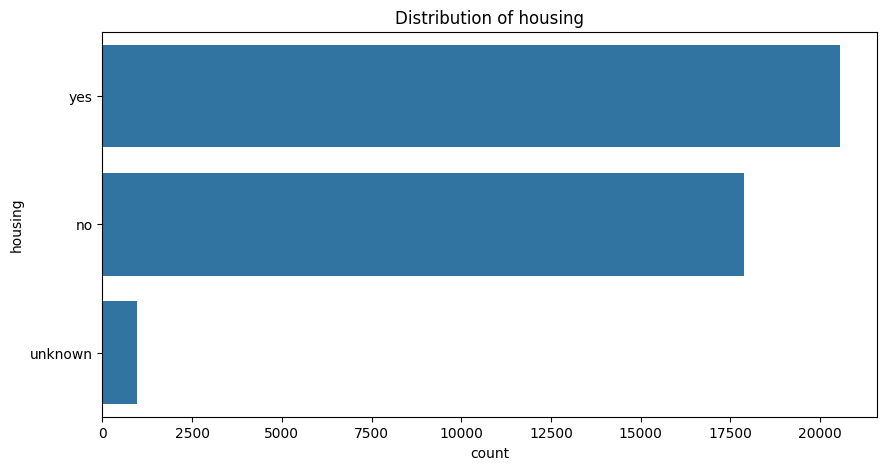


Column: loan
loan
no         32248
yes         6176
unknown      980
Name: count, dtype: int64


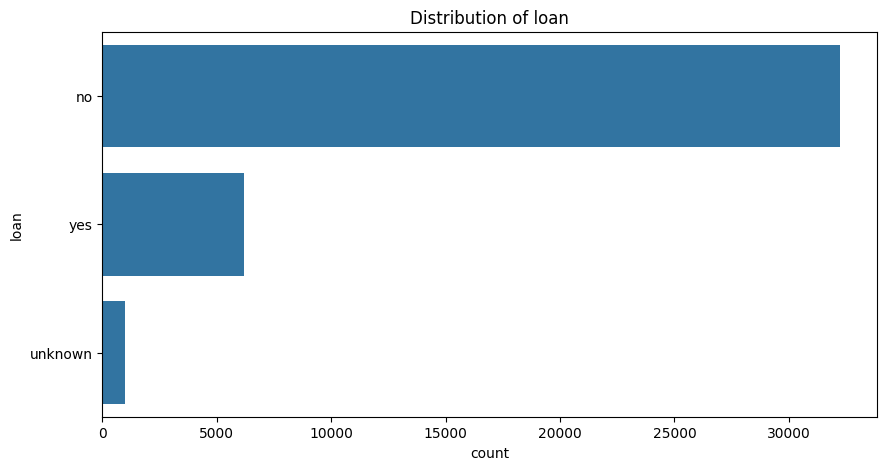


Column: contact
contact
cellular     24673
telephone    14731
Name: count, dtype: int64


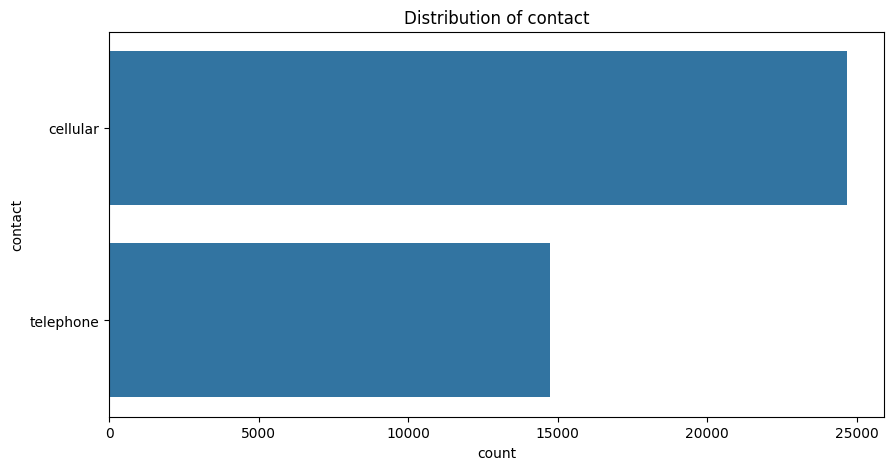


Column: month
month
may    13315
jul     6698
aug     5719
jun     5245
nov     3910
apr     2535
oct      707
sep      564
mar      530
dec      181
Name: count, dtype: int64


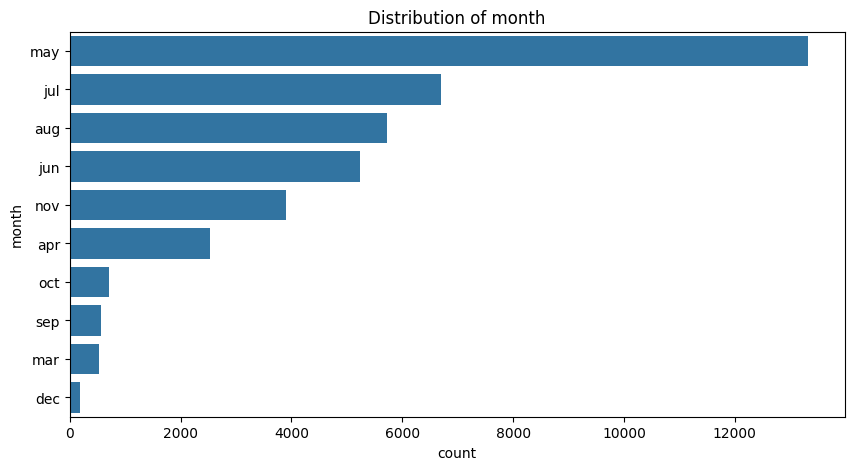


Column: day_of_week
day_of_week
thu    8197
mon    8188
wed    7760
tue    7708
fri    7551
Name: count, dtype: int64


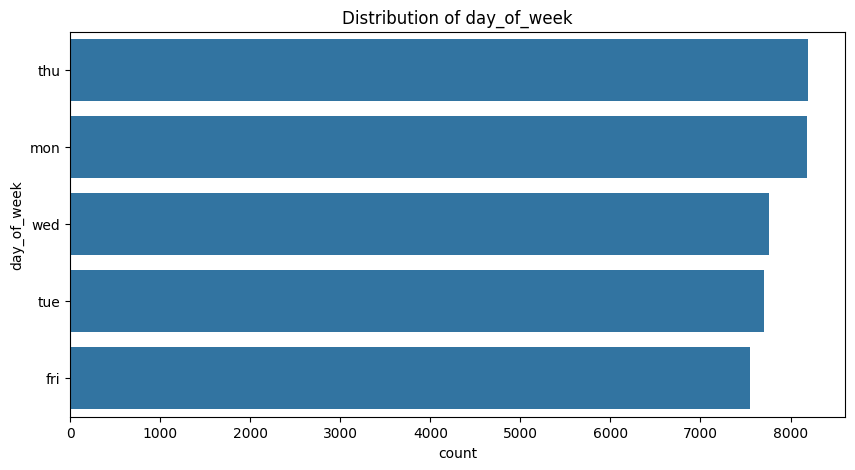


Column: poutcome
poutcome
nonexistent    33858
failure         4174
success         1372
Name: count, dtype: int64


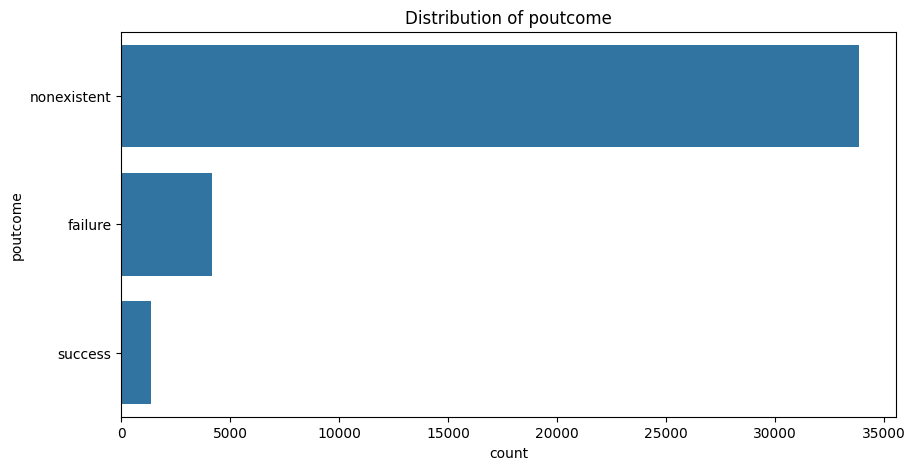


Column: pdays_cat
pdays_cat
never_contacted    37890
4-7                  636
0-3                  540
8-15                 300
16+                   38
Name: count, dtype: int64


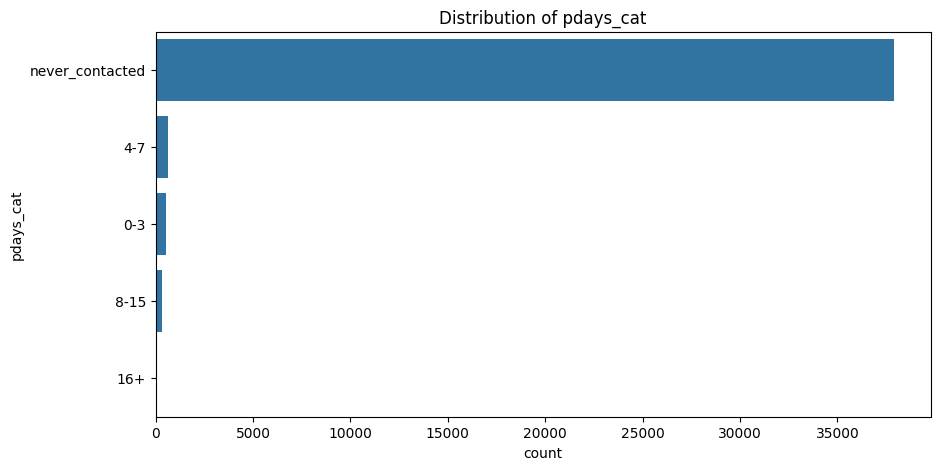


Column: age_group
age_group
adult      30558
senior      7558
youth       1024
elderly      264
Name: count, dtype: int64


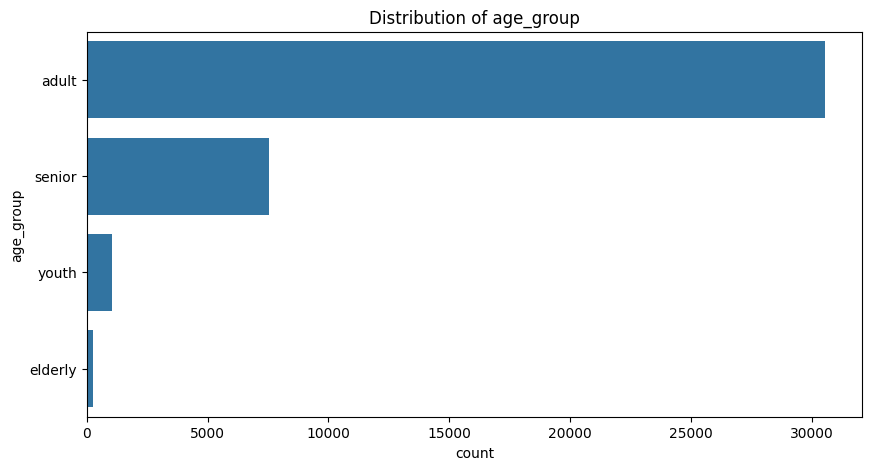


Column: housing_loan_interaction
housing_loan_interaction
yes_no             16917
no_no              15331
yes_yes             3644
no_yes              2532
unknown_unknown      980
Name: count, dtype: int64


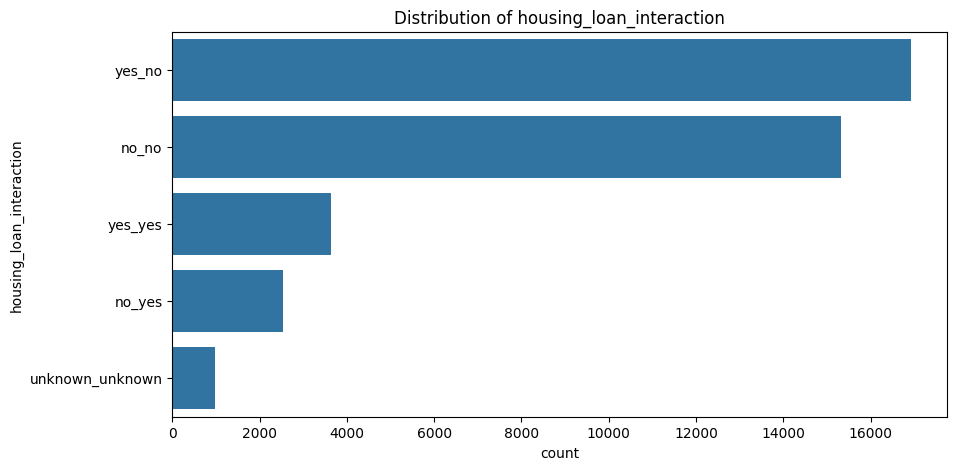

In [31]:
# Analyze categorical features
print("\nValue counts for categorical features:")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df_act[col].value_counts())

    # Plot bar plots for categorical features
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_act, y=col, order=df_act[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

Box plots of numerical features against the target variable 'y':


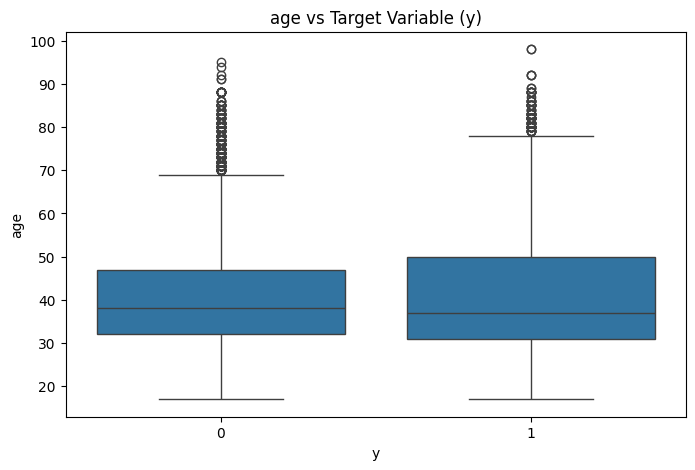

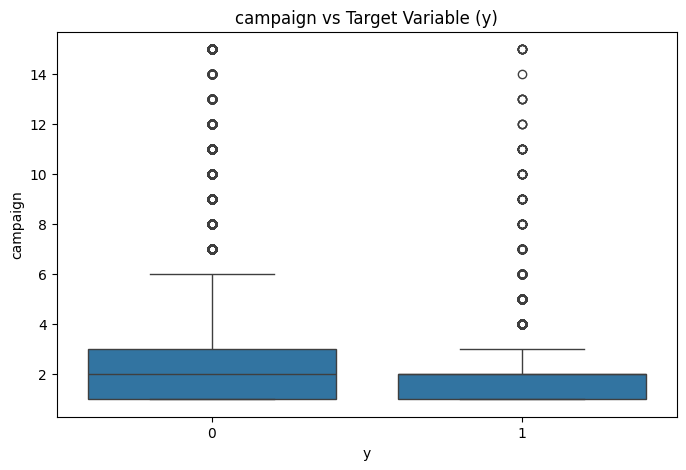

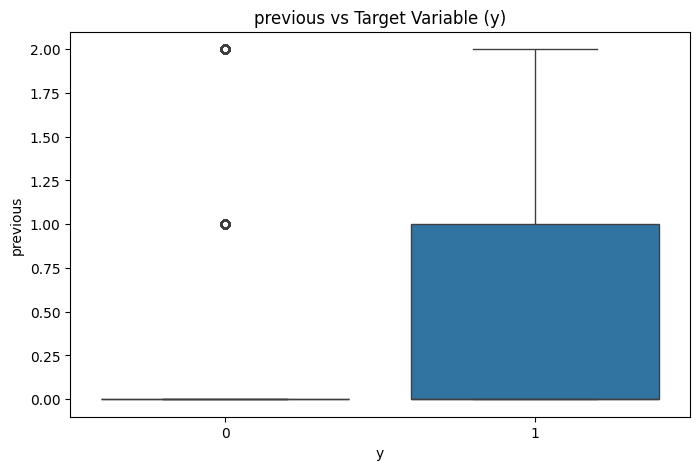

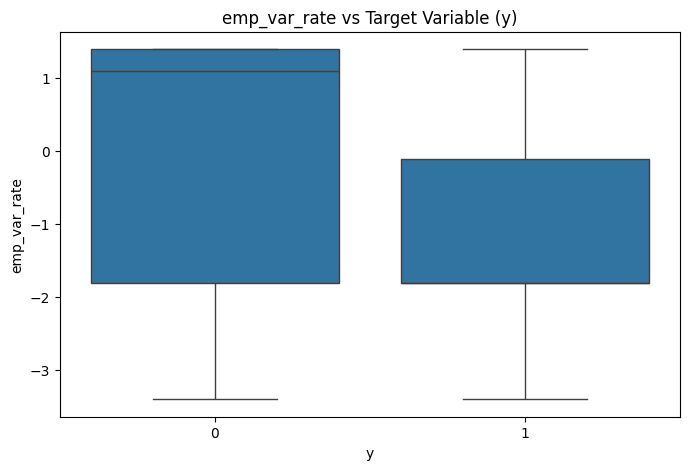

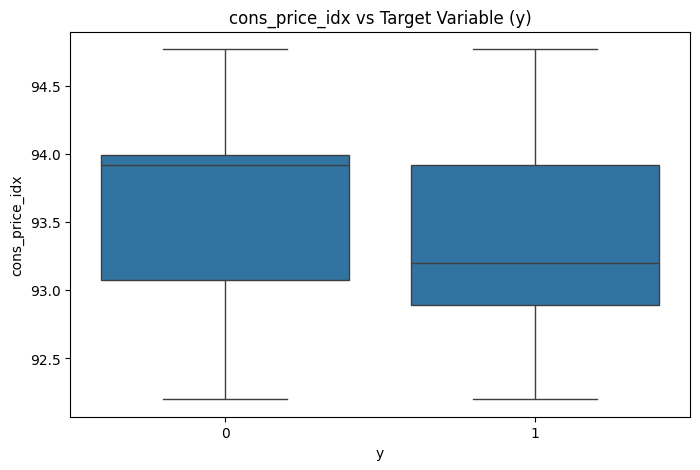

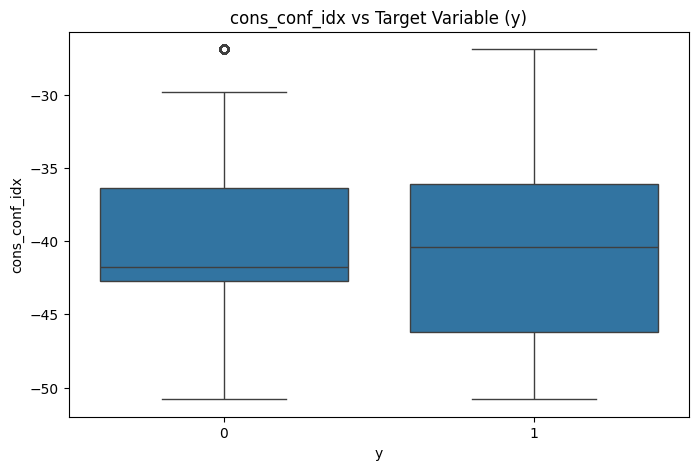

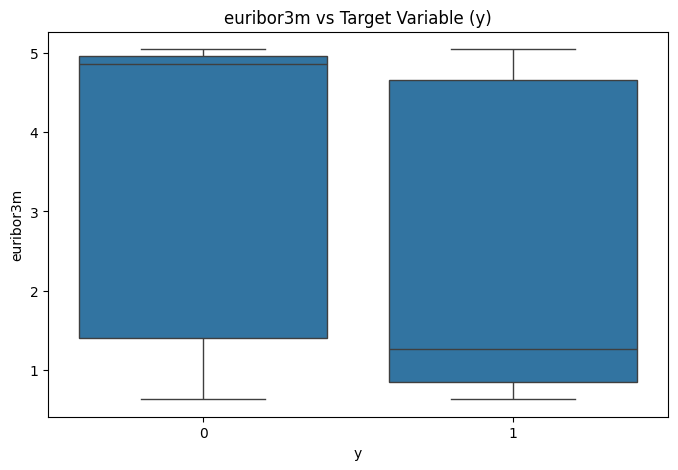

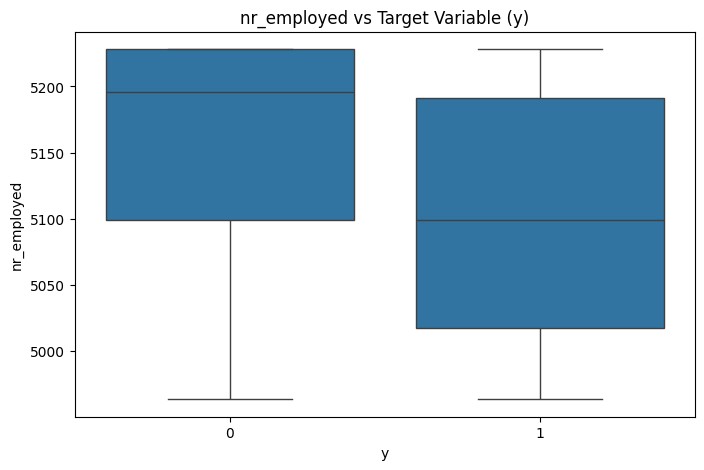


Correlation coefficients between numerical features and the target variable 'y':
y                 1.000000
previous          0.226061
cons_conf_idx     0.057146
age               0.028196
campaign         -0.076730
cons_price_idx   -0.137115
emp_var_rate     -0.298055
euribor3m        -0.307860
nr_employed      -0.354145
Name: y, dtype: float64


In [ ]:
# Analyze relationships between numerical features and the target variable

# 1. Create box plots for numerical features against the target variable 'y'
print("Box plots of numerical features against the target variable 'y':")
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_act, x='y', y=col)
    plt.title(f'{col} vs Target Variable (y)')
    plt.show()

# 2. Calculate the correlation matrix
numerical_df = df_act[numerical_cols].copy()
numerical_df['y'] = df_act['y']
correlation_matrix = numerical_df.corr()

# 3. Print the correlation coefficients with the target variable 'y'
print("\nCorrelation coefficients between numerical features and the target variable 'y':")
print(correlation_matrix['y'].sort_values(ascending=False))

Reasoning: Analyze the relationships between categorical features and the target variable using visualizations like bar plots or grouped bar plots.


Analyzing relationships between categorical features and the target variable 'y':


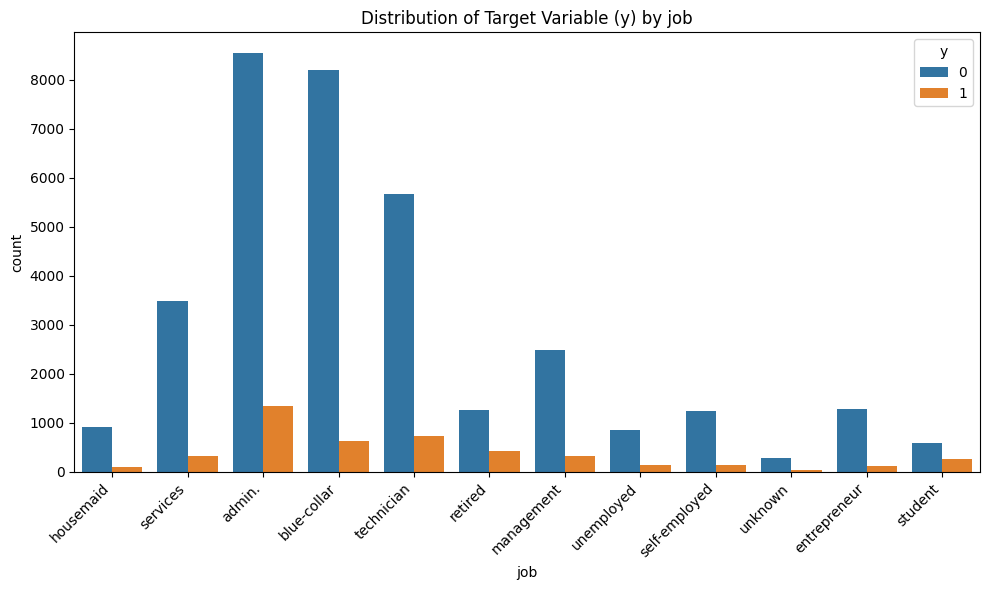

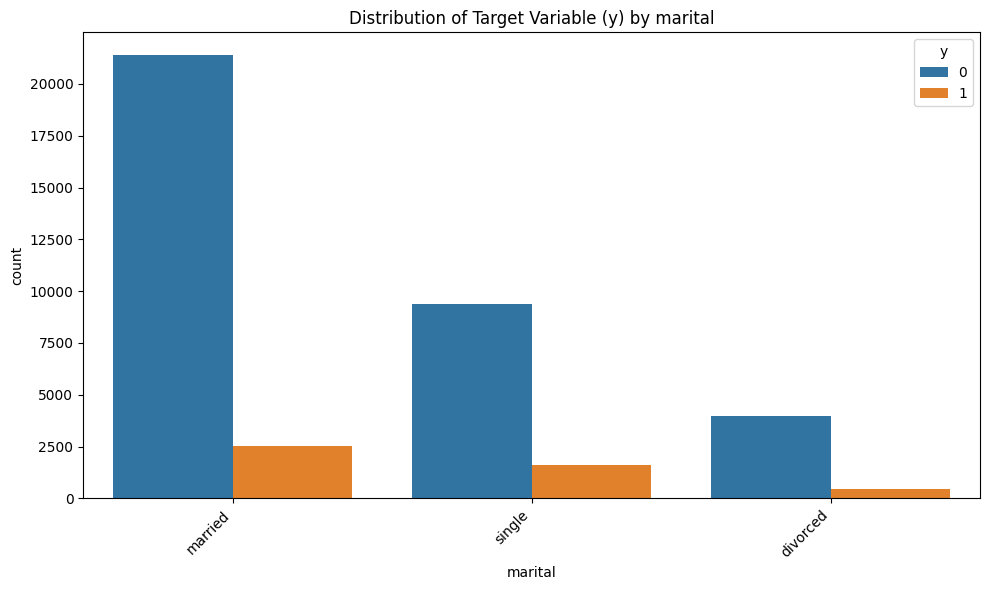

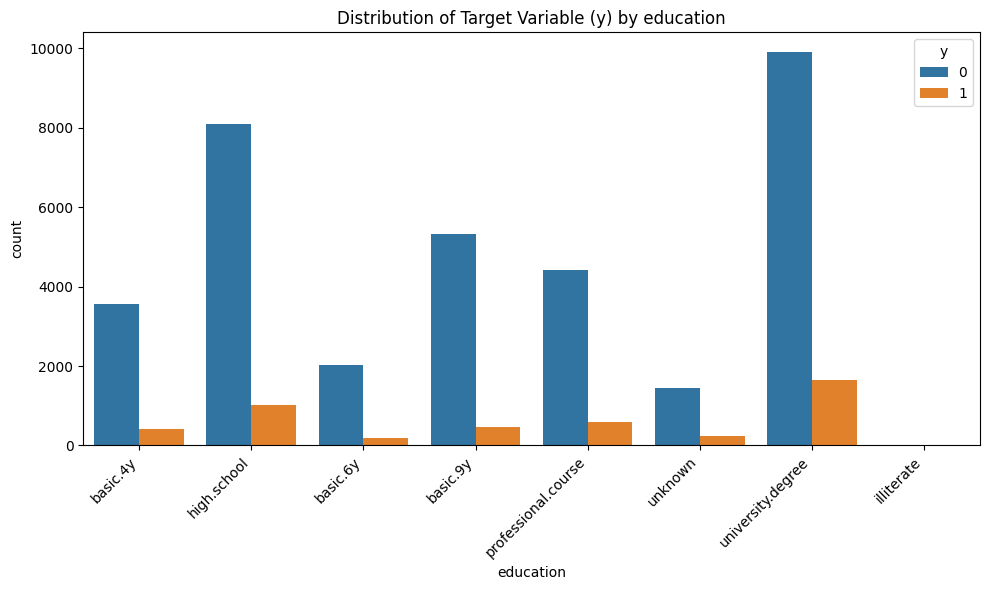

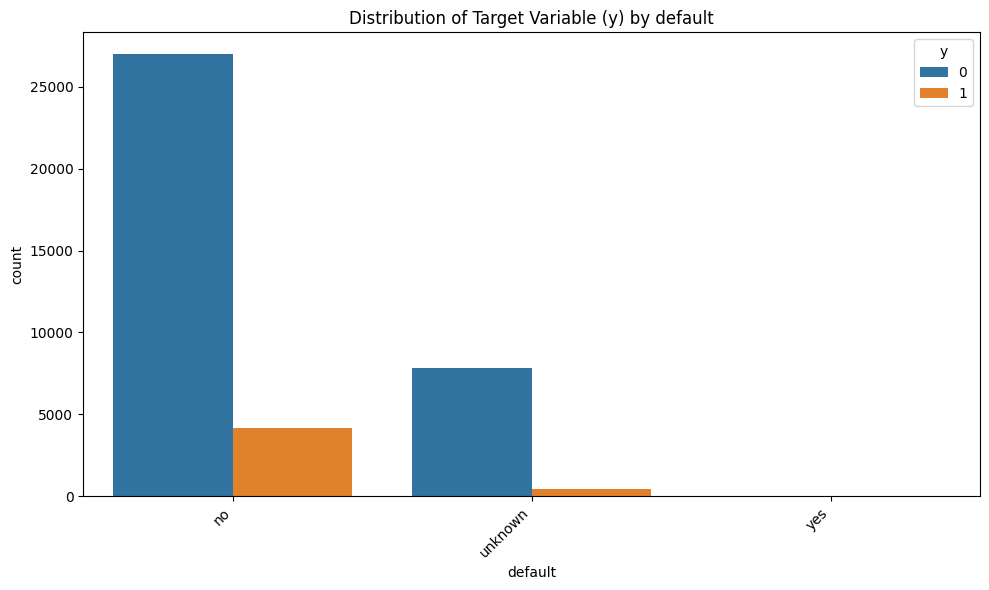

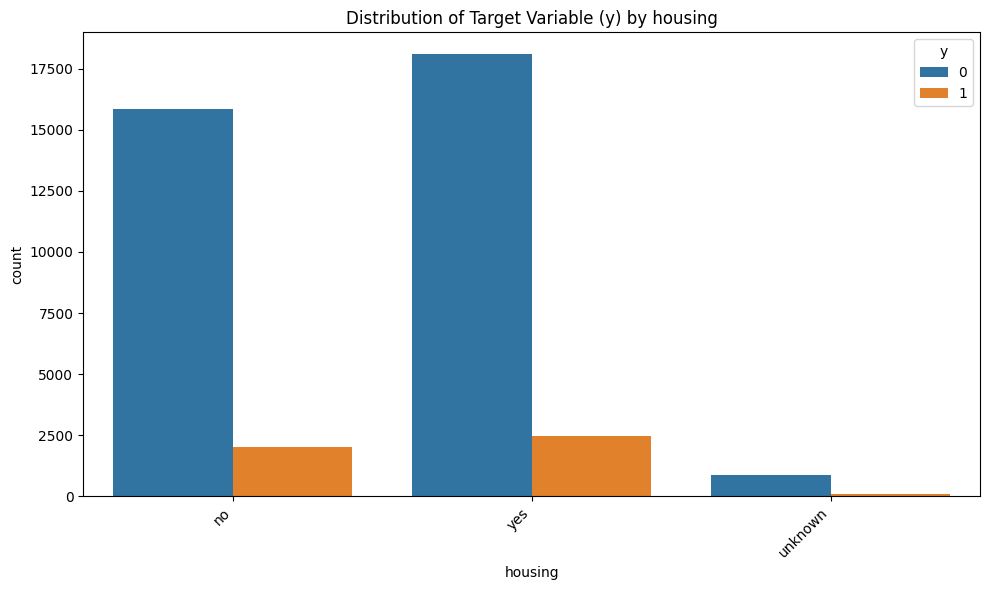

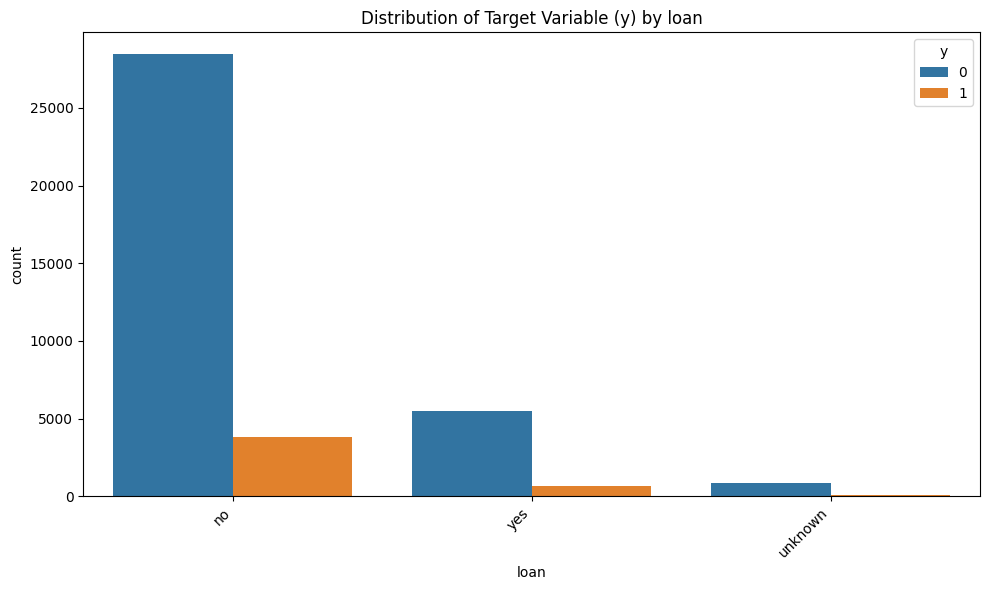

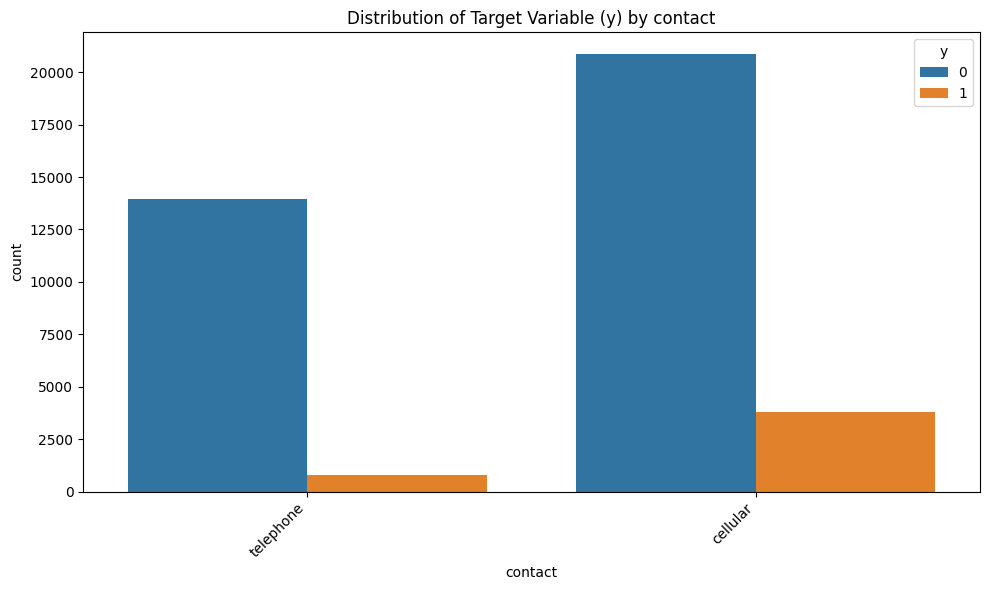

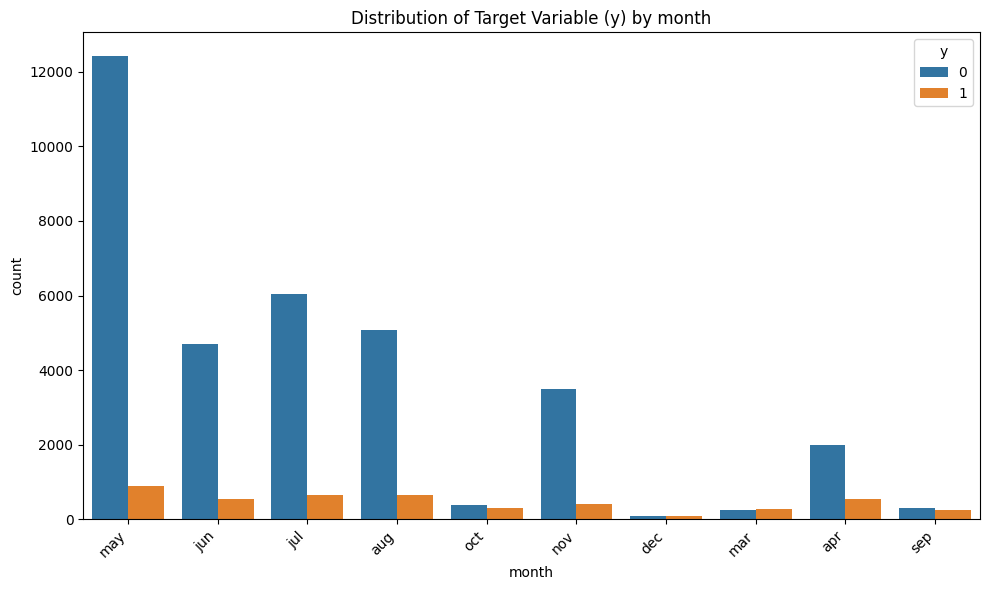

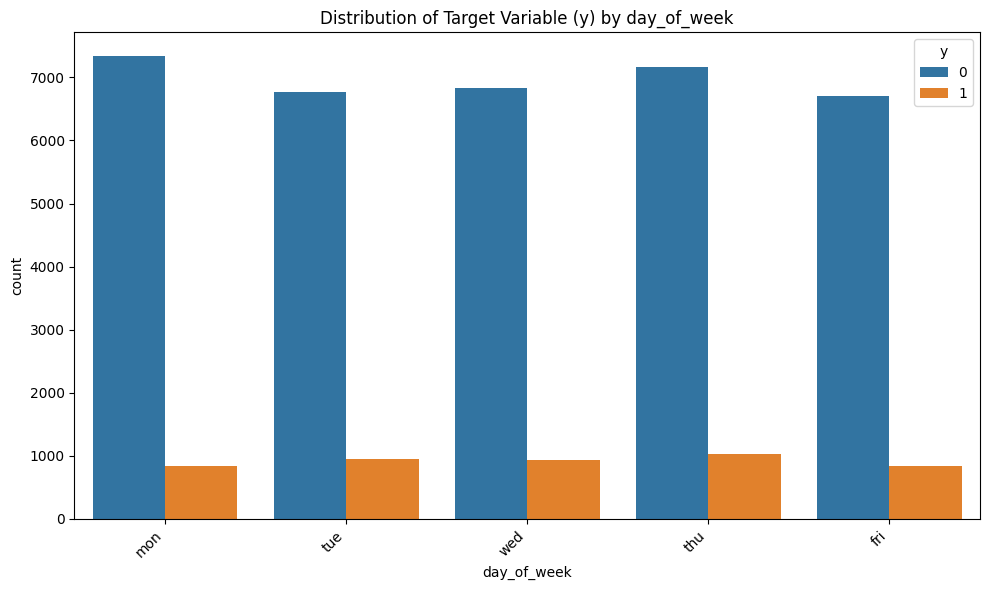

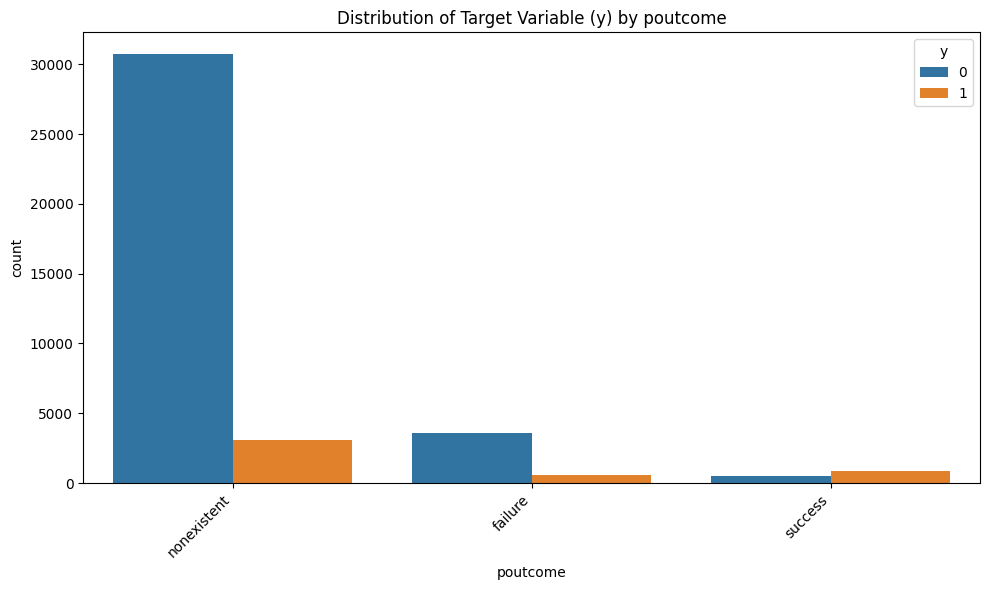

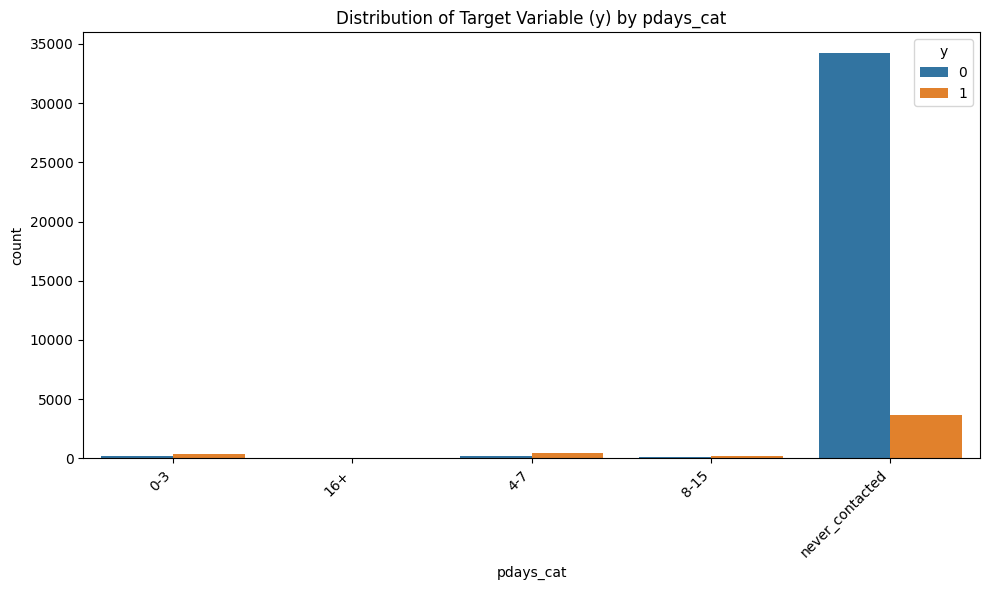

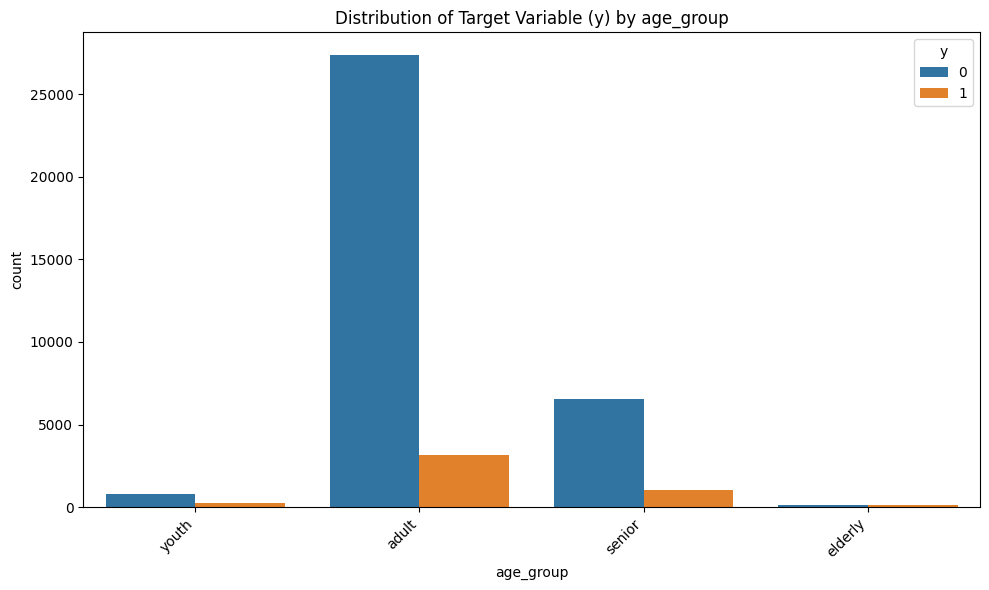

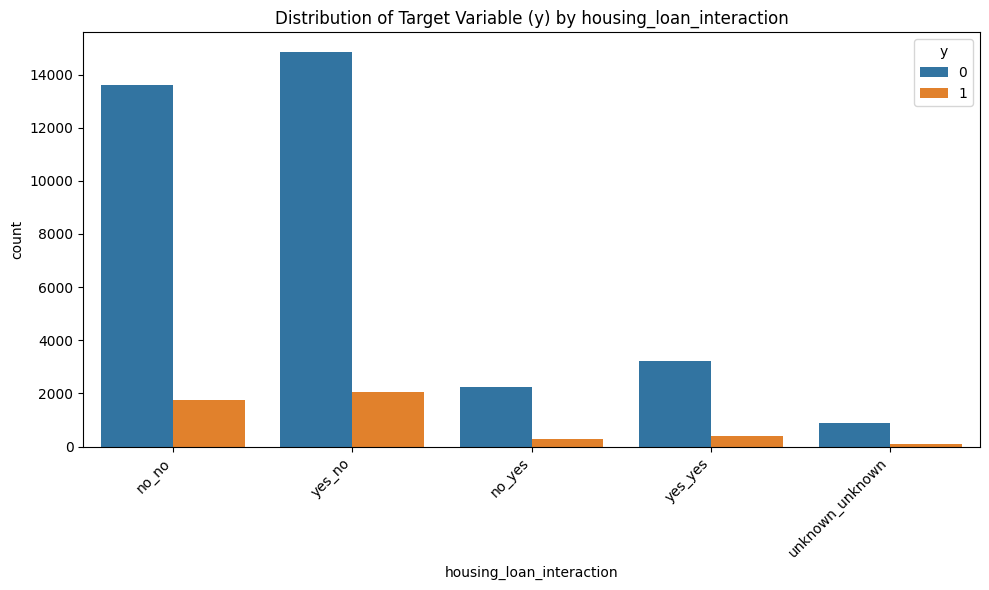

In [ ]:
# Analyze relationships between categorical features and the target variable

print("\nAnalyzing relationships between categorical features and the target variable 'y':")

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_act, x=col, hue='y')
    plt.title(f'Distribution of Target Variable (y) by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

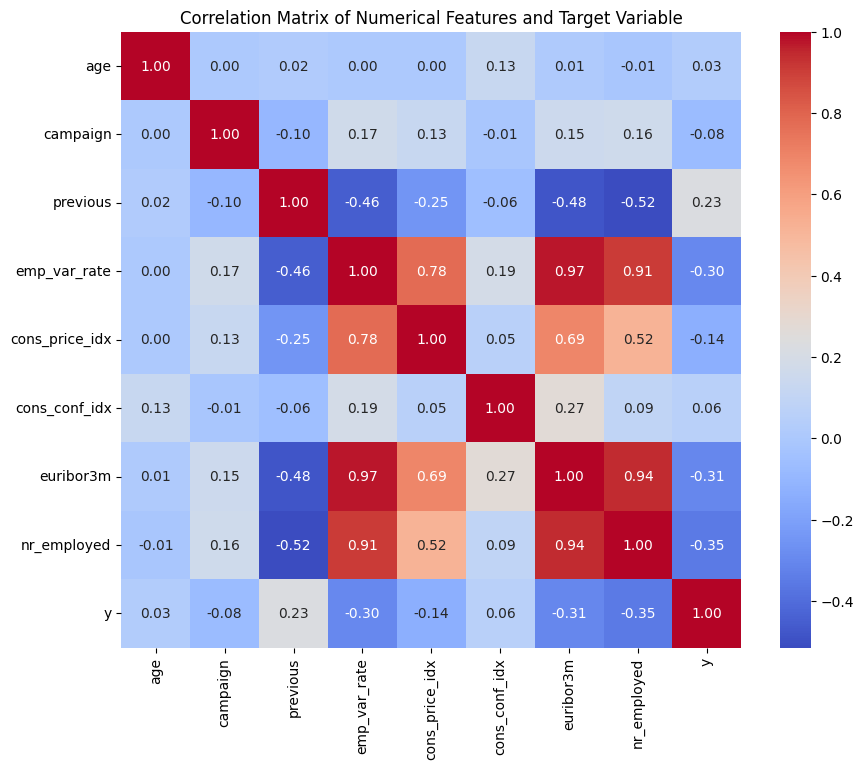

In [ ]:
# Create a pair plot for a subset of numerical features and the target variable

# Generate a heatmap of the correlation matrix for all numerical features and the target variable
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features and Target Variable')
plt.show()

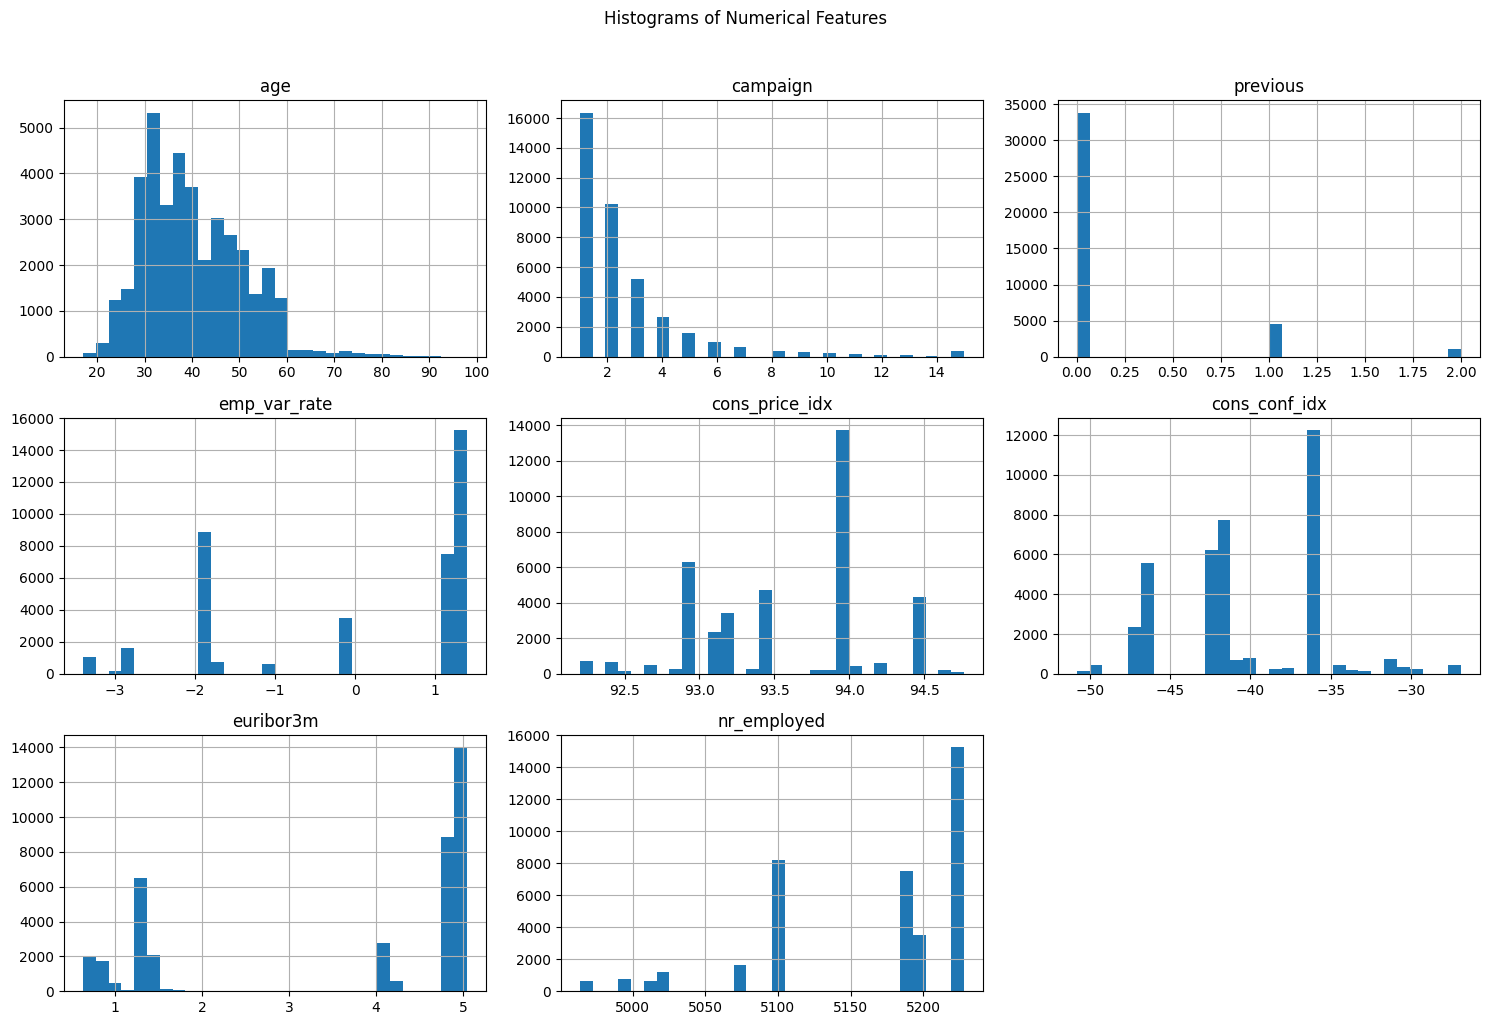

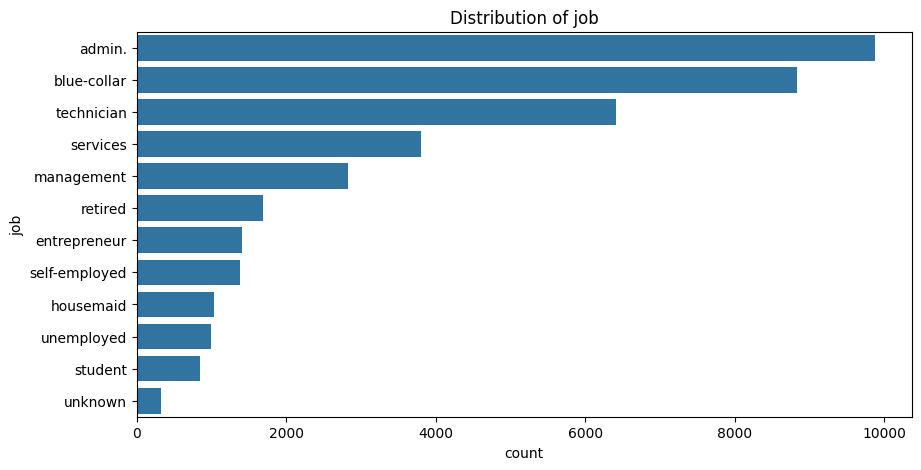

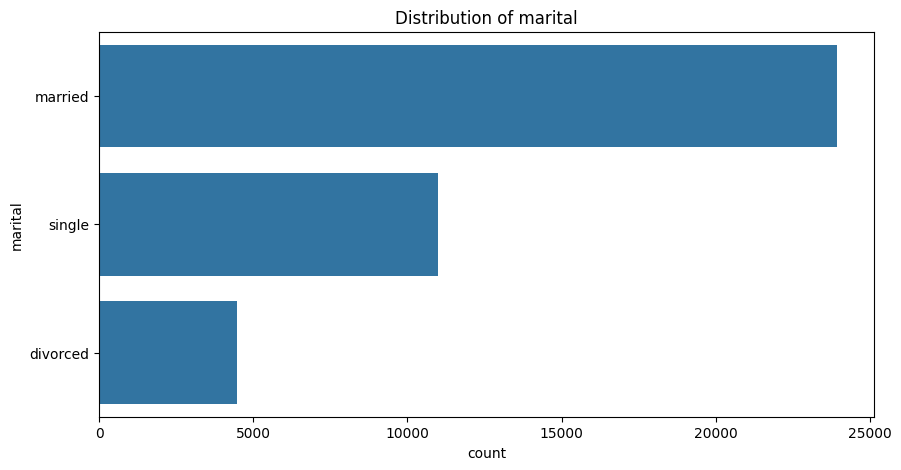

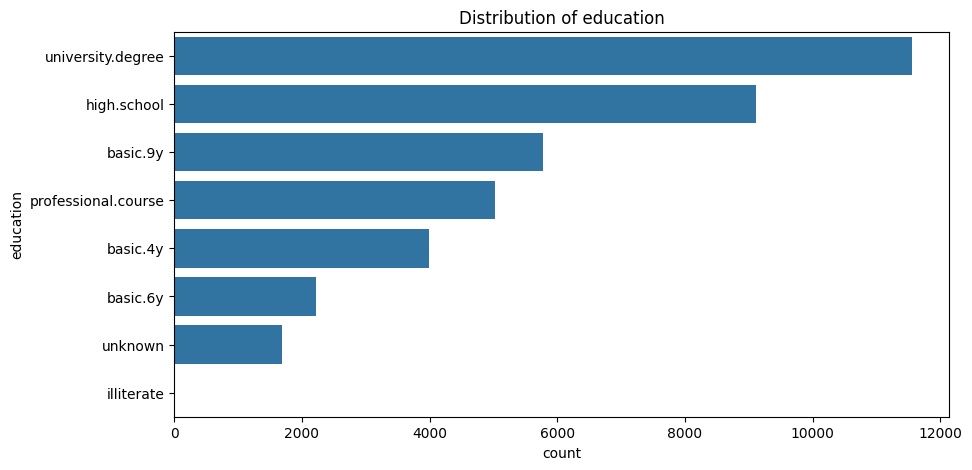

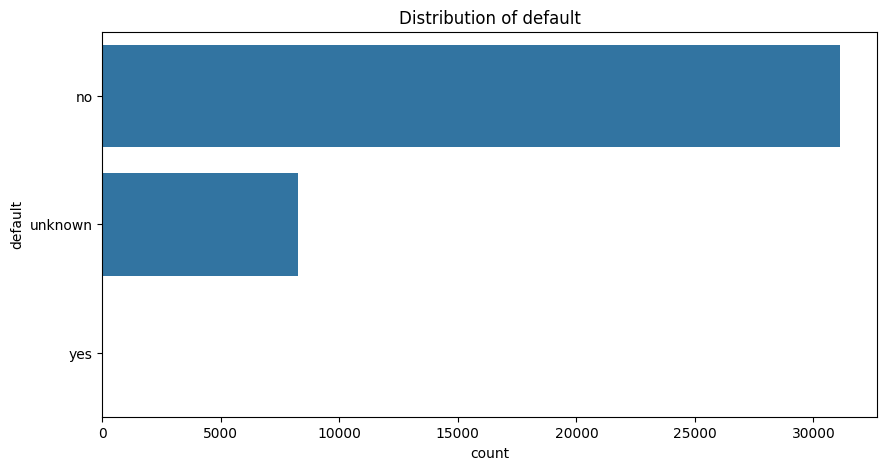

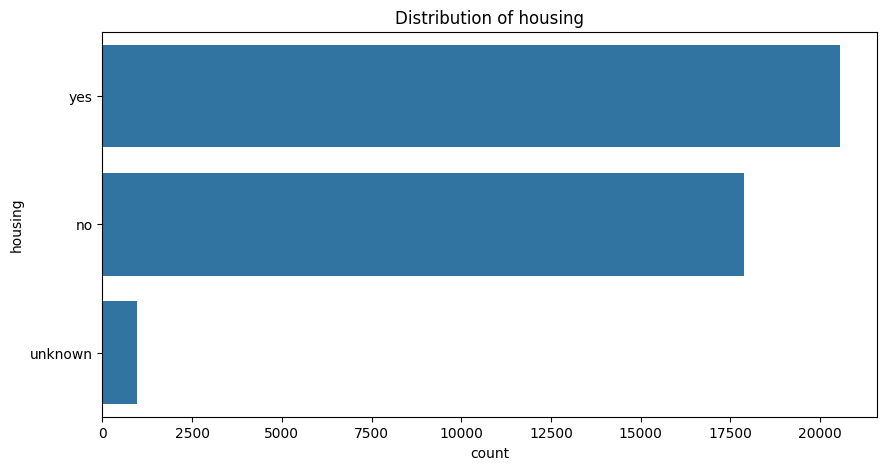

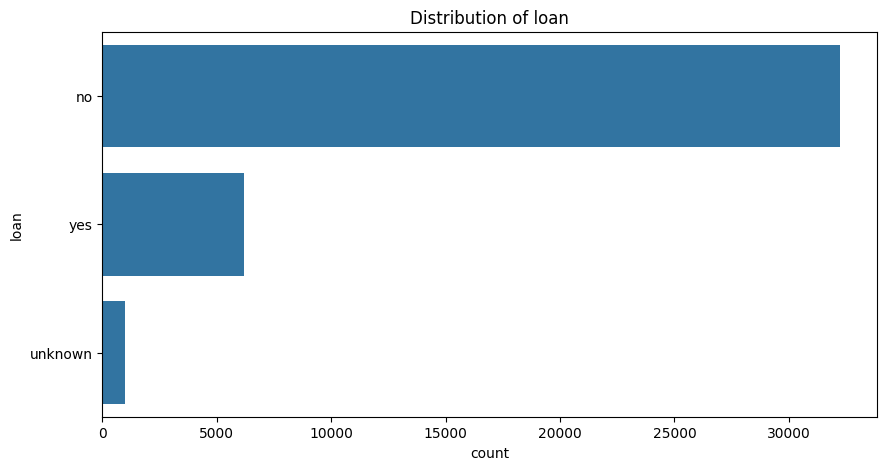

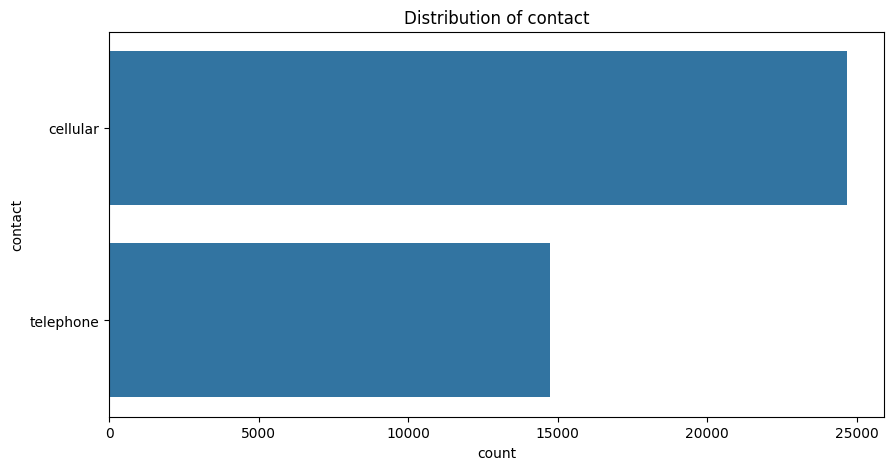

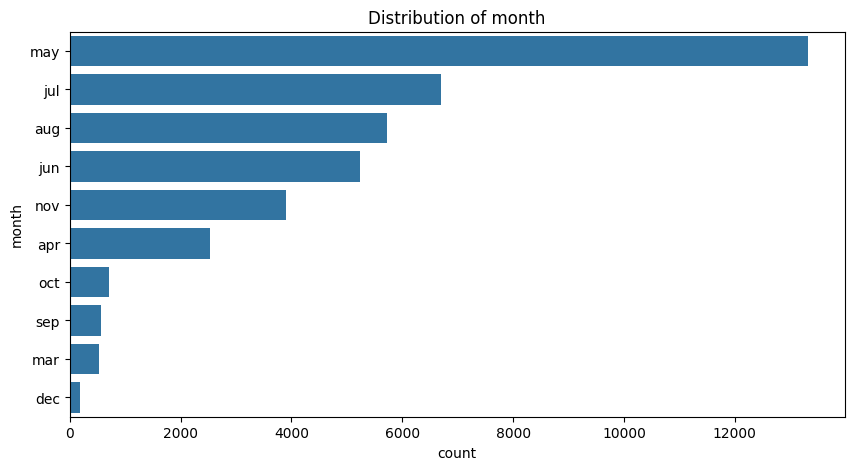

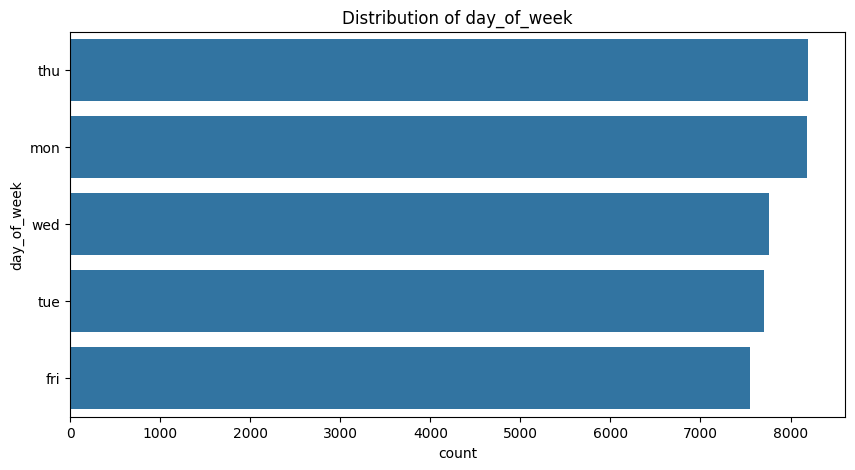

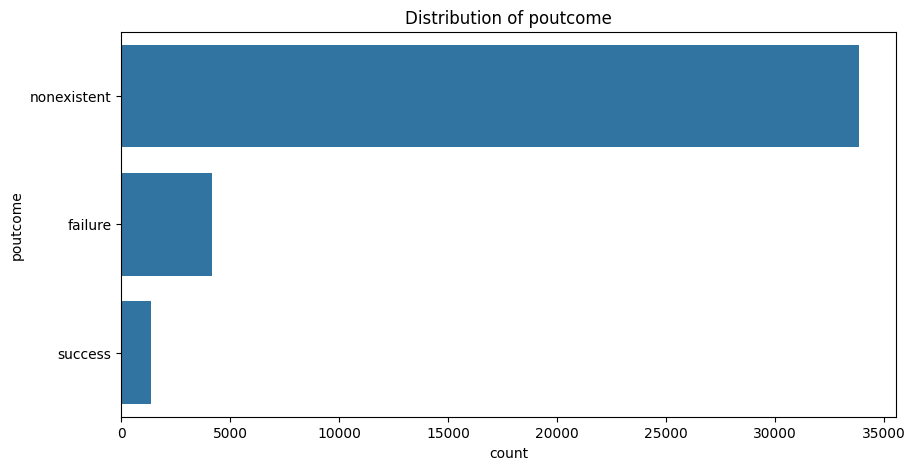

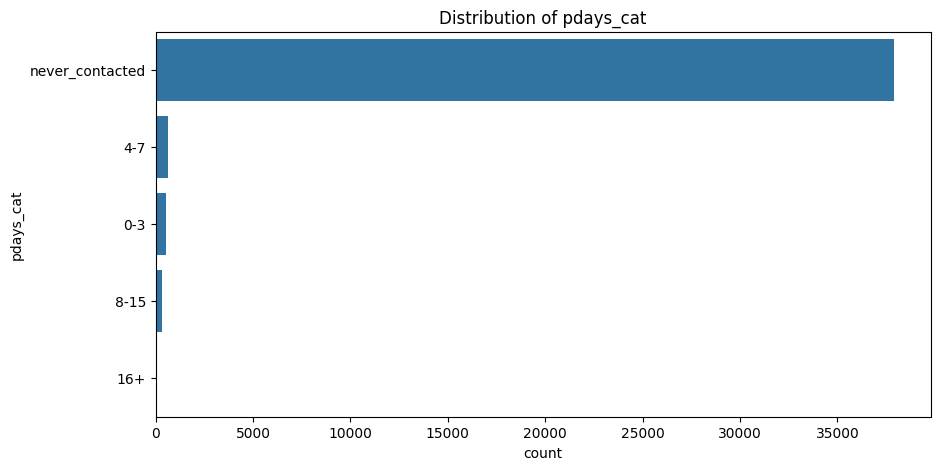

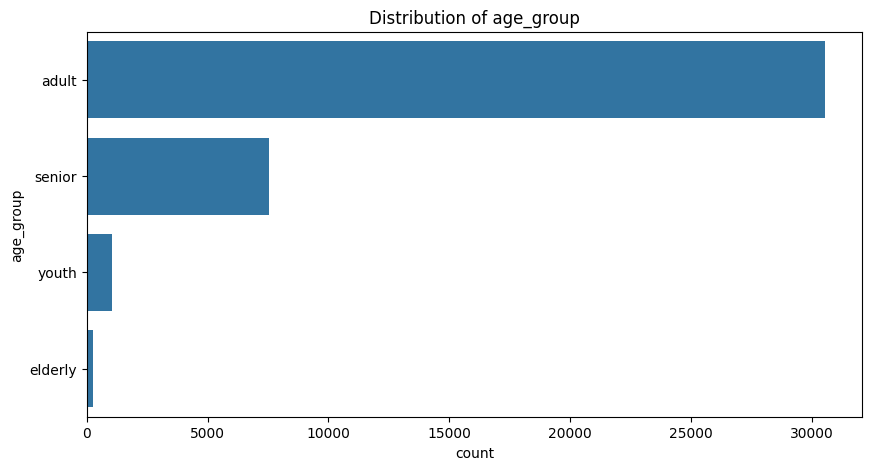

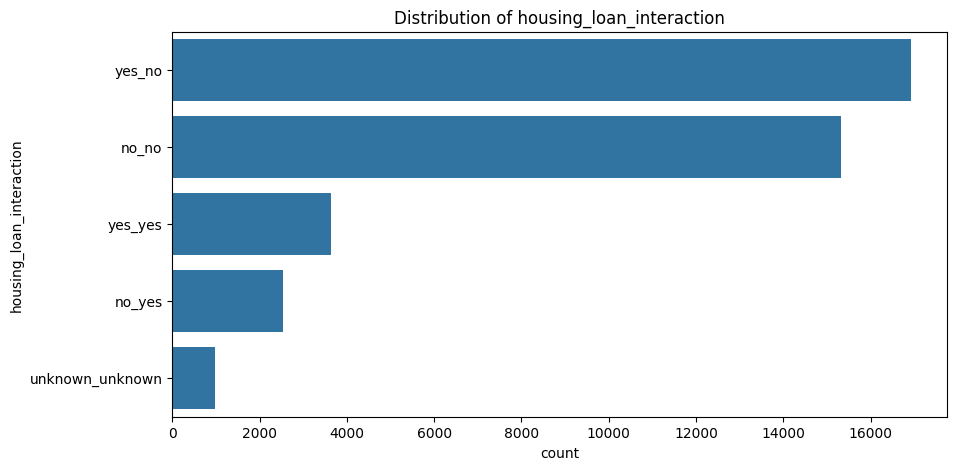

In [ ]:
# Create histograms for numerical features
df_act[numerical_cols].hist(bins=30, figsize=(15, 10))
plt.suptitle('Histograms of Numerical Features', y=1.02)
plt.tight_layout()
plt.show()

# Create bar plots for categorical features
for col in categorical_cols:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df_act, y=col, order=df_act[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.show()

Box plots of numerical features against the target variable 'y':


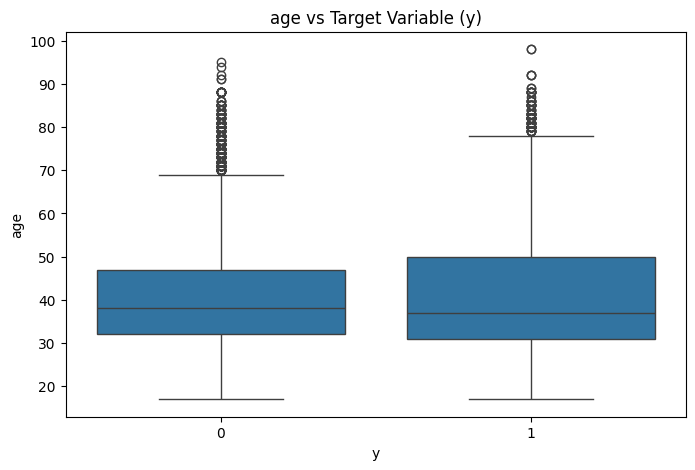

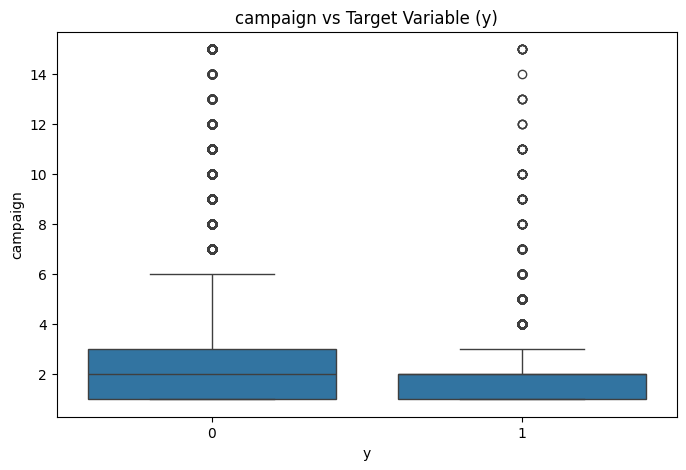

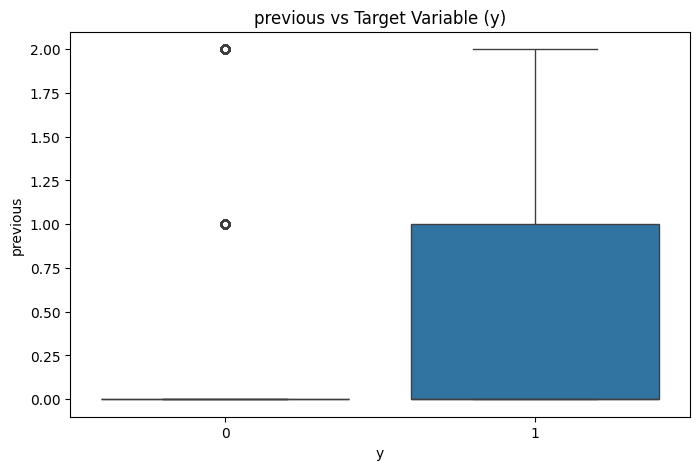

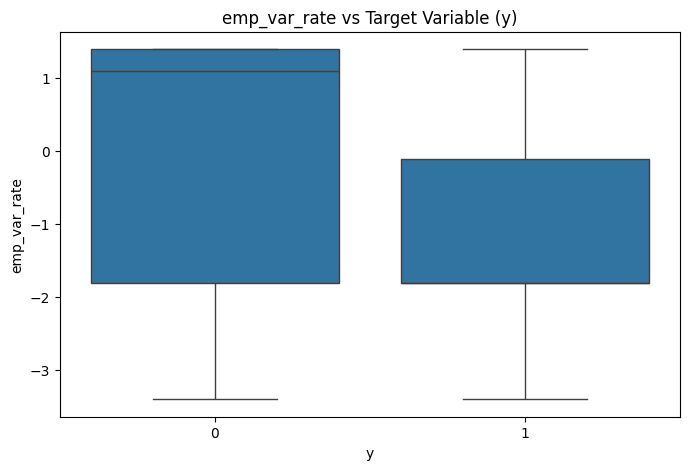

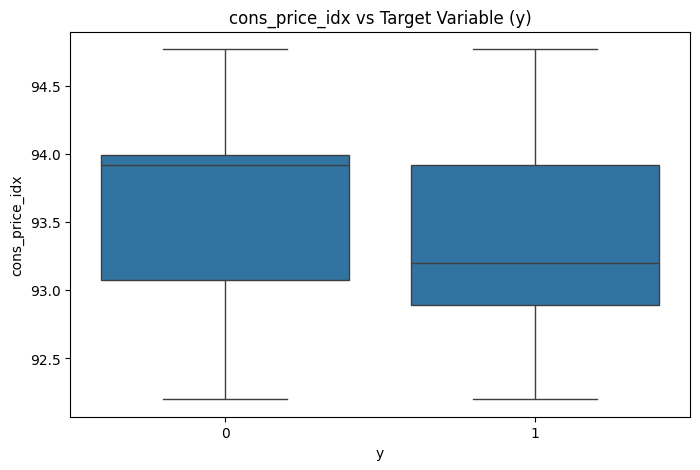

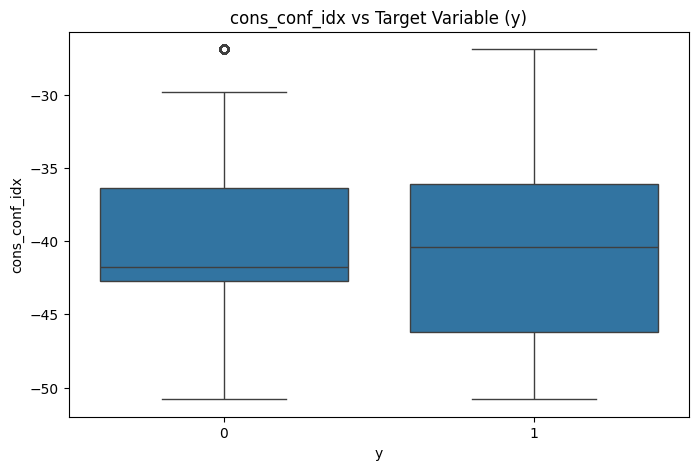

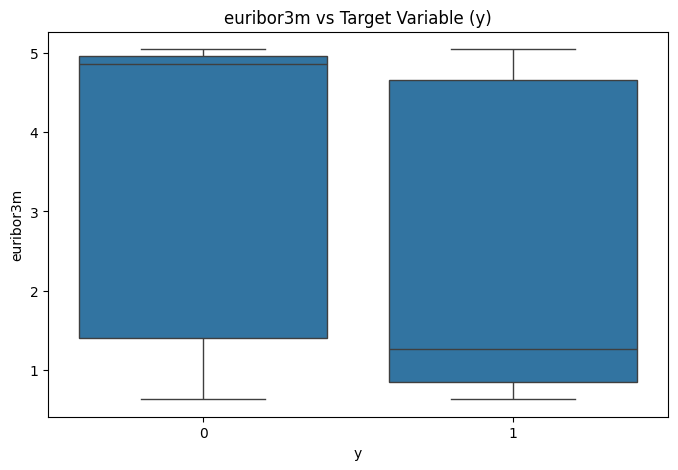

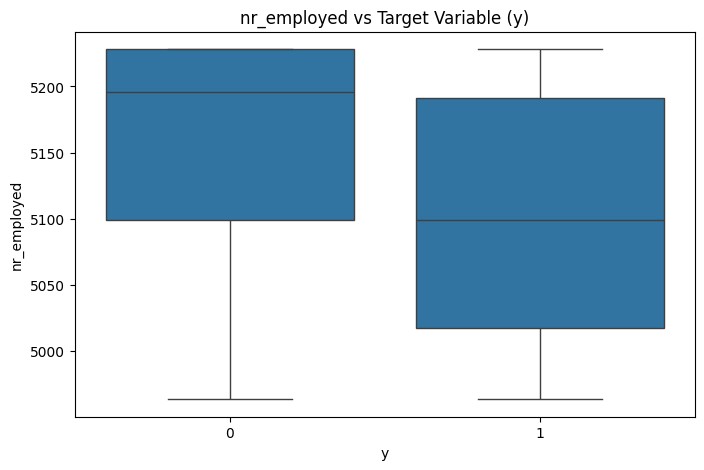


Grouped bar plots of categorical features against the target variable 'y':


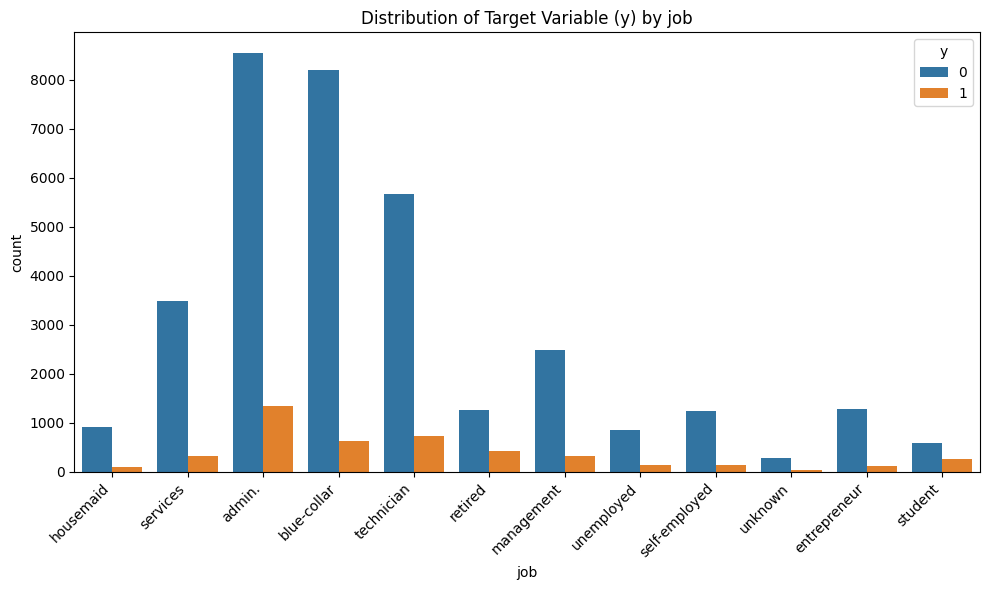

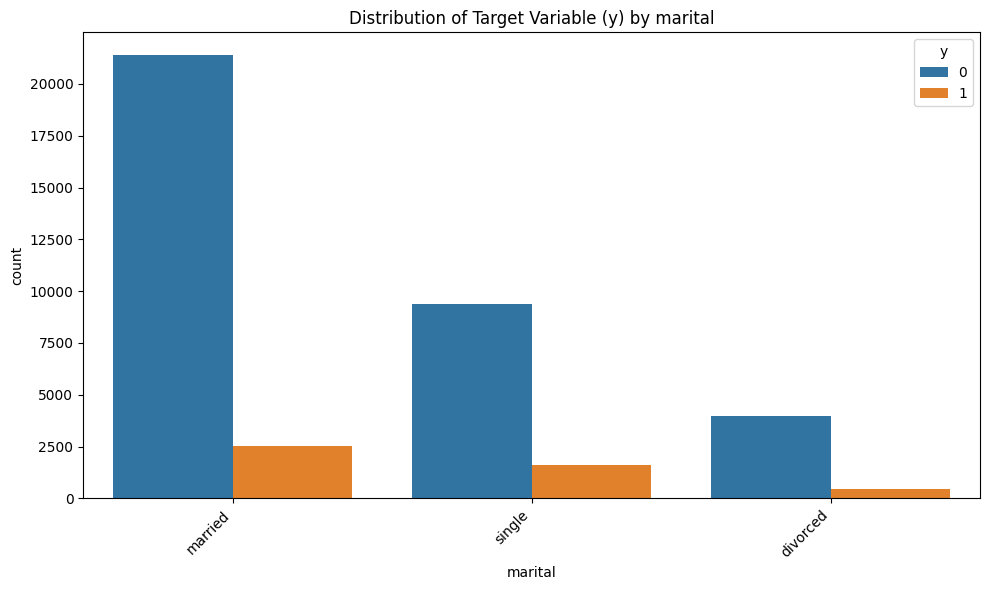

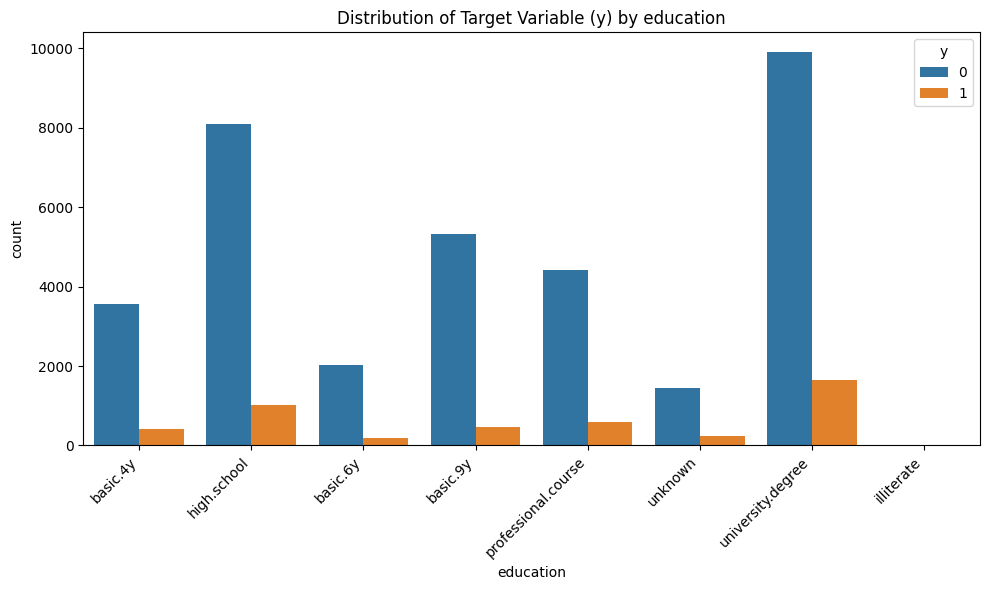

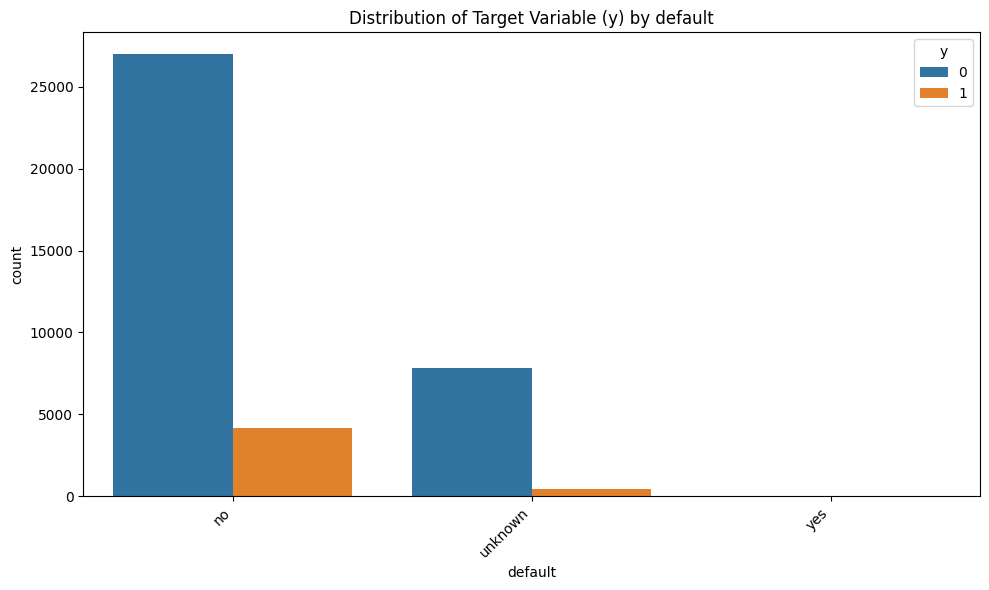

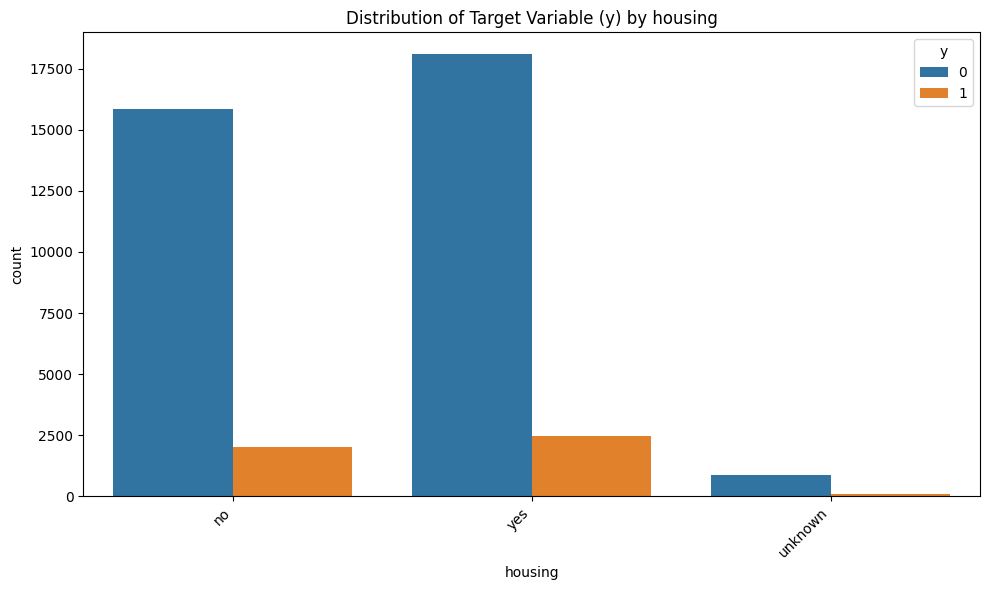

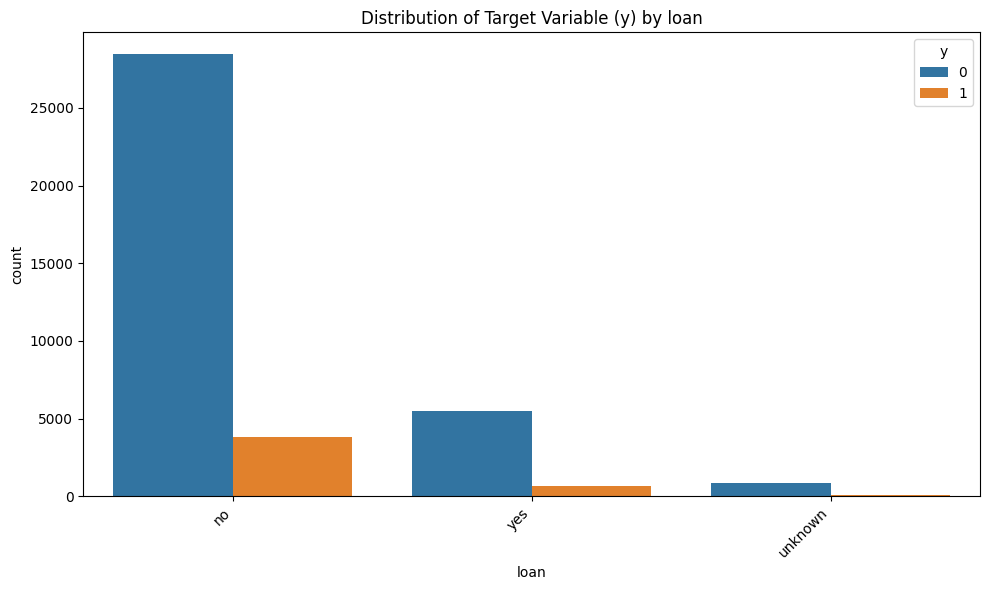

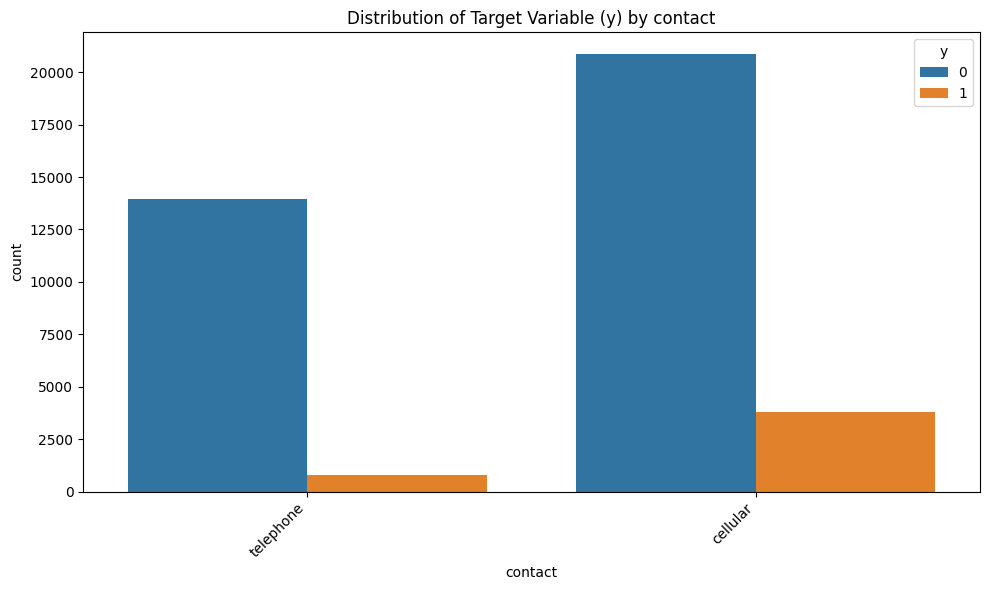

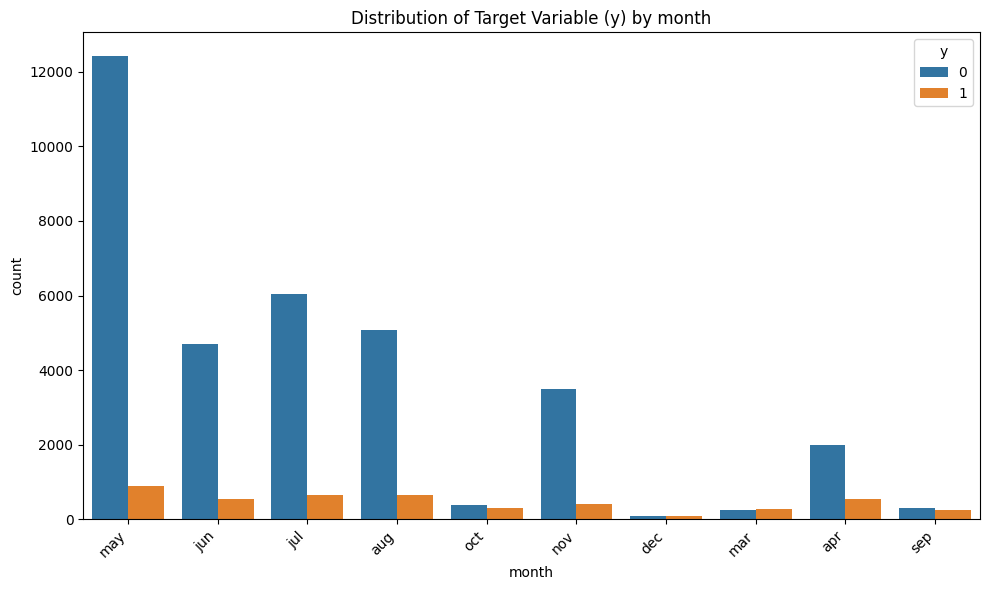

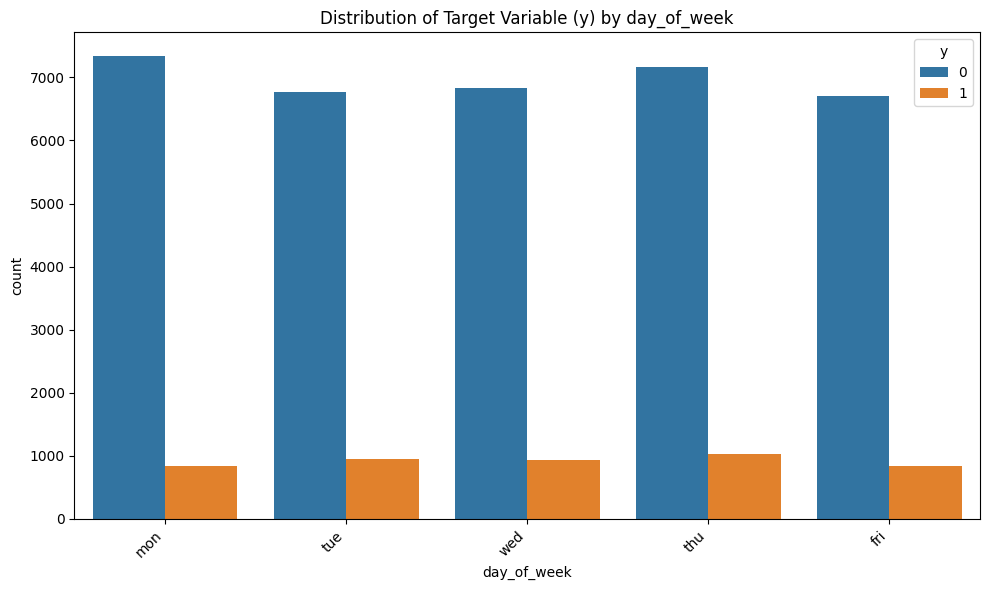

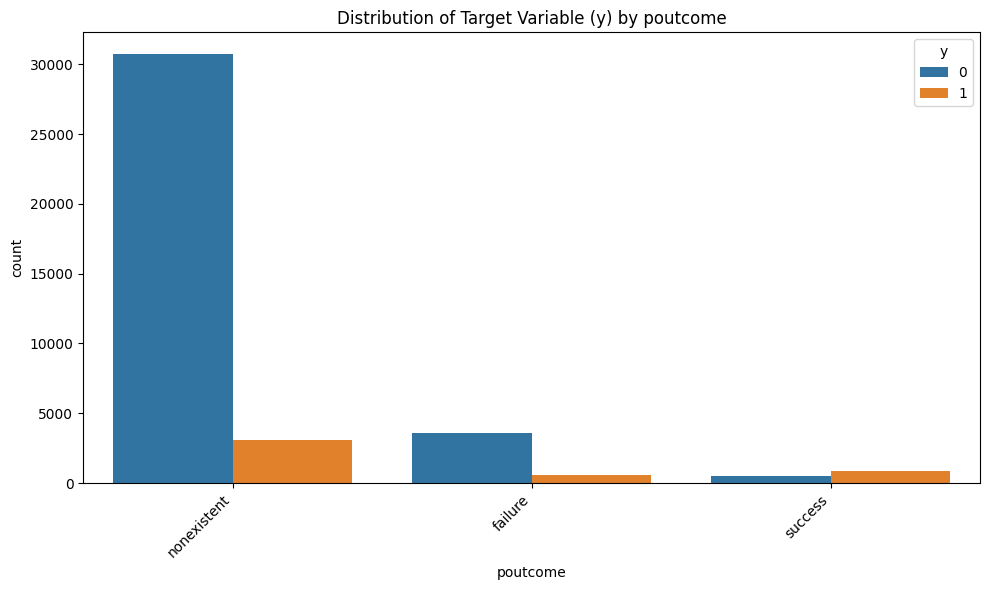

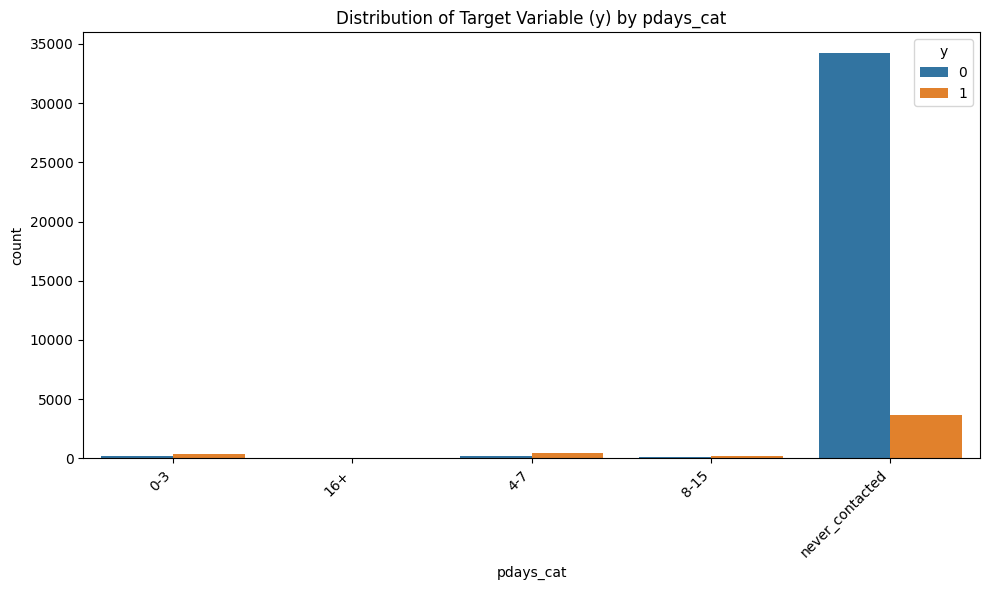

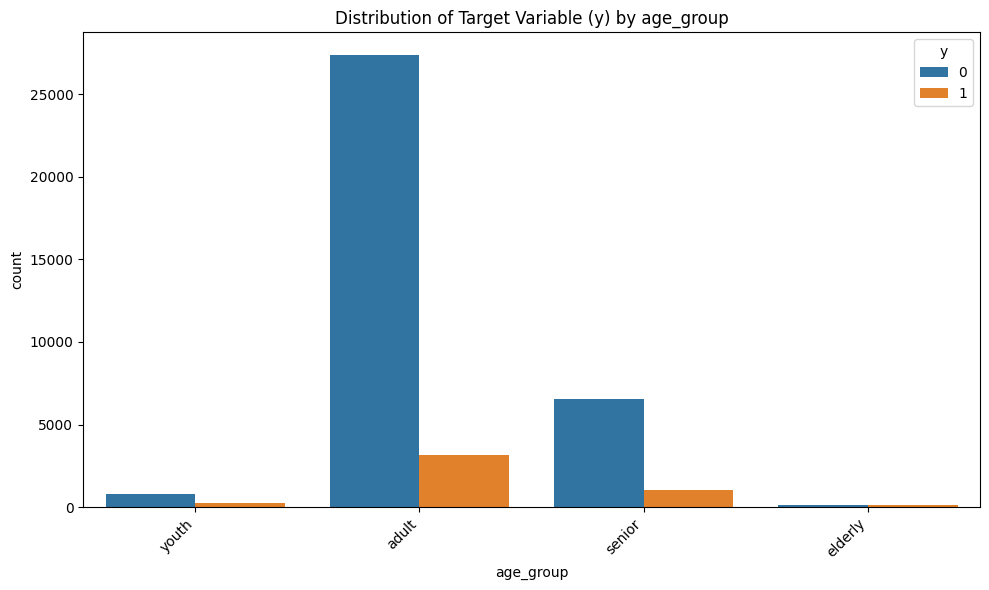

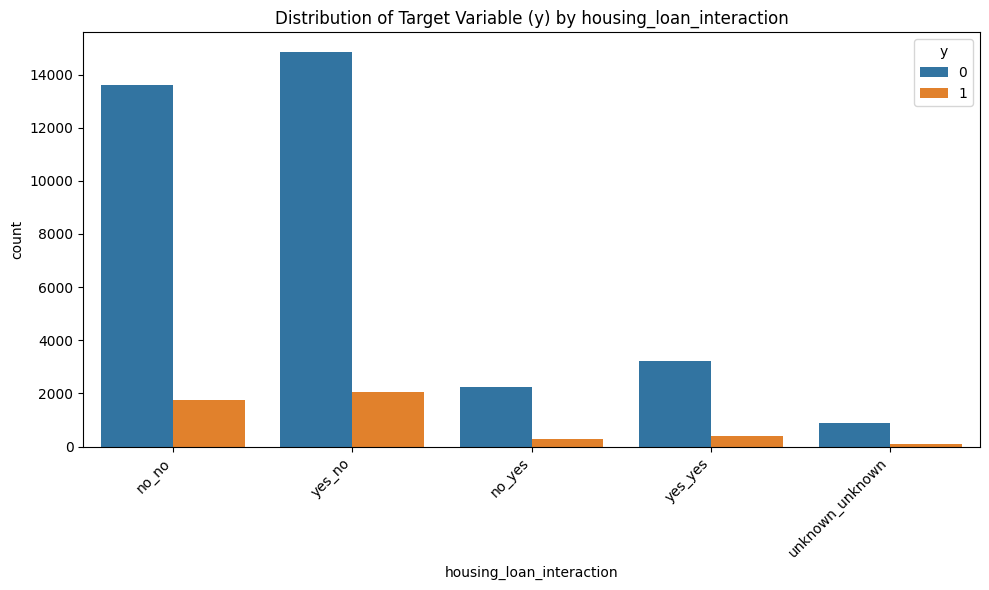

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Generate box plots for numerical features against the target variable 'y'
print("Box plots of numerical features against the target variable 'y':")
for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.boxplot(data=df_act, x='y', y=col)
    plt.title(f'{col} vs Target Variable (y)')
    plt.show()

# 2. Generate grouped bar plots for categorical features against the target variable 'y'
print("\nGrouped bar plots of categorical features against the target variable 'y':")
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=df_act, x=col, hue='y')
    plt.title(f'Distribution of Target Variable (y) by {col}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

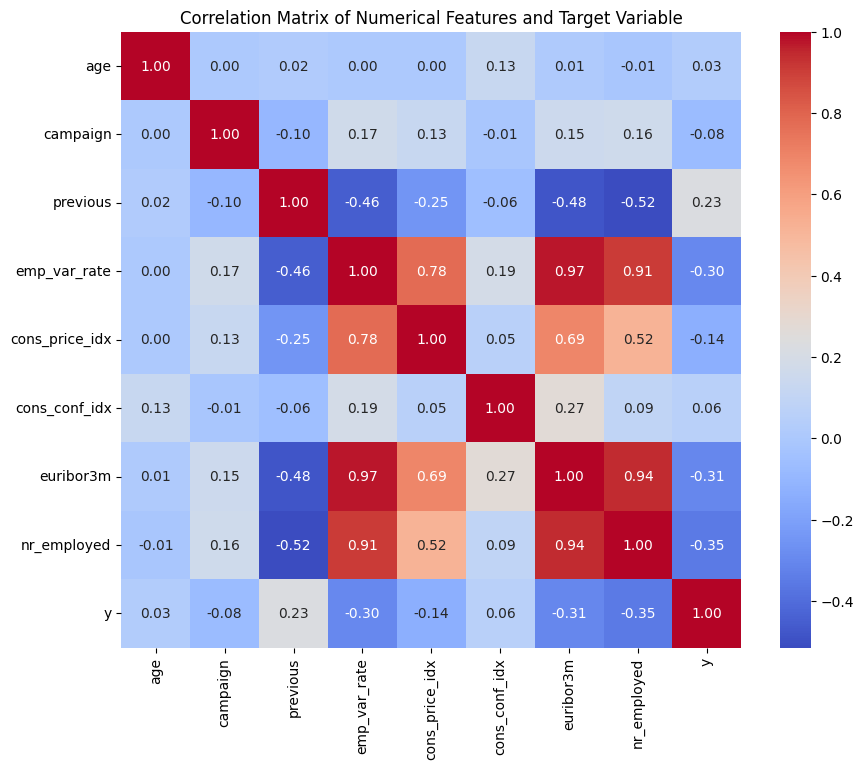

In [ ]:
# Create a heatmap of the correlation matrix for all numerical features and the target variable
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features and Target Variable')
plt.show()


In [ ]:
import plotly.express as px


# Create an interactive bar plot: counts of y for each month
fig_bar = px.bar(df_act, x='month', color='y',
                 title='Count of Target Variable (y) by Month')
fig_bar.show()

In [ ]:
# Group by 'age_group' and calculate conversion rate
age_group_conversion = df_act.groupby('age_group')['y'].mean().reset_index()
age_group_conversion.rename(columns={'y': 'conversion_rate'}, inplace=True)

# Group by 'marital' and calculate conversion rate
marital_conversion = df_act.groupby('marital')['y'].mean().reset_index()
marital_conversion.rename(columns={'y': 'conversion_rate'}, inplace=True)

# Group by 'education' and calculate conversion rate
education_conversion = df_act.groupby('education')['y'].mean().reset_index()
education_conversion.rename(columns={'y': 'conversion_rate'}, inplace=True)

# Print the conversion rates
print("Conversion Rate by Age Group:")
print(age_group_conversion)

print("\nConversion Rate by Marital Status:")
print(marital_conversion)

print("\nConversion Rate by Education Level:")
print(education_conversion)

Conversion Rate by Age Group:
  age_group  conversion_rate
0     youth         0.247070
1     adult         0.104195
2    senior         0.135486
3   elderly         0.518939

Conversion Rate by Marital Status:
    marital  conversion_rate
0  divorced         0.105853
1   married         0.105562
2    single         0.145312

Conversion Rate by Education Level:
             education  conversion_rate
0             basic.4y         0.106436
1             basic.6y         0.084608
2             basic.9y         0.080553
3          high.school         0.112159
4           illiterate         0.222222
5  professional.course         0.117975
6    university.degree         0.142808
7              unknown         0.147687


/tmp/ipython-input-2753482888.py:2: FutureWarning:

The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.



In [ ]:
# Group by 'job' and calculate conversion rate
job_conversion = df_act.groupby('job')['y'].mean().reset_index()
job_conversion.rename(columns={'y': 'conversion_rate'}, inplace=True)
print("Conversion Rate by Job:")
print(job_conversion)

# Group by 'housing' and calculate conversion rate
housing_conversion = df_act.groupby('housing')['y'].mean().reset_index()
housing_conversion.rename(columns={'y': 'conversion_rate'}, inplace=True)
print("\nConversion Rate by Housing Loan:")
print(housing_conversion)

# Group by 'loan' and calculate conversion rate
loan_conversion = df_act.groupby('loan')['y'].mean().reset_index()
loan_conversion.rename(columns={'y': 'conversion_rate'}, inplace=True)
print("\nConversion Rate by Personal Loan:")
print(loan_conversion)

# Group by 'contact' and calculate conversion rate
contact_conversion = df_act.groupby('contact')['y'].mean().reset_index()
contact_conversion.rename(columns={'y': 'conversion_rate'}, inplace=True)
print("\nConversion Rate by Contact Method:")
print(contact_conversion)

# Group by 'month' and calculate conversion rate
month_conversion = df_act.groupby('month')['y'].mean().reset_index()
month_conversion.rename(columns={'y': 'conversion_rate'}, inplace=True)
print("\nConversion Rate by Last Contact Month:")
print(month_conversion)

Conversion Rate by Job:
              job  conversion_rate
0          admin.         0.135217
1     blue-collar         0.071647
2    entrepreneur         0.086121
3       housemaid         0.103113
4      management         0.115603
5         retired         0.256090
6   self-employed         0.107504
7        services         0.084715
8         student         0.318075
9      technician         0.113523
10     unemployed         0.142137
11        unknown         0.110769

Conversion Rate by Housing Loan:
   housing  conversion_rate
0       no         0.112635
1  unknown         0.109184
2      yes         0.120568

Conversion Rate by Personal Loan:
      loan  conversion_rate
0       no         0.118116
1  unknown         0.109184
2      yes         0.110427

Conversion Rate by Contact Method:
     contact  conversion_rate
0   cellular         0.154460
1  telephone         0.053425

Conversion Rate by Last Contact Month:
  month  conversion_rate
0   apr         0.209862
1   aug     

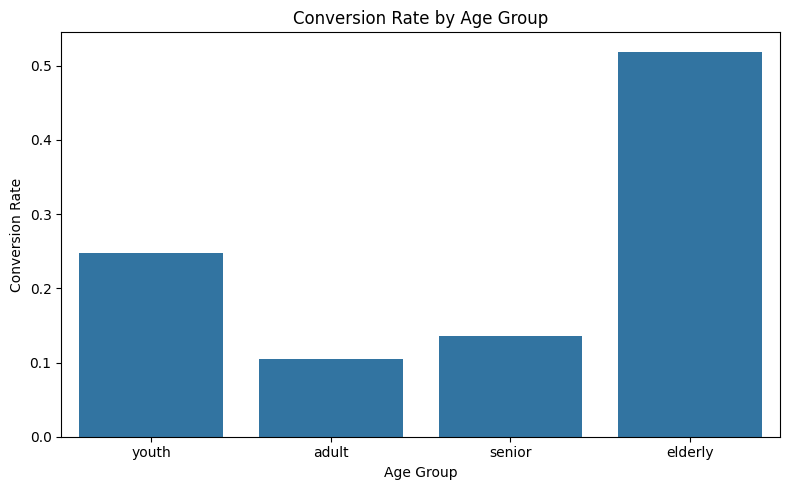

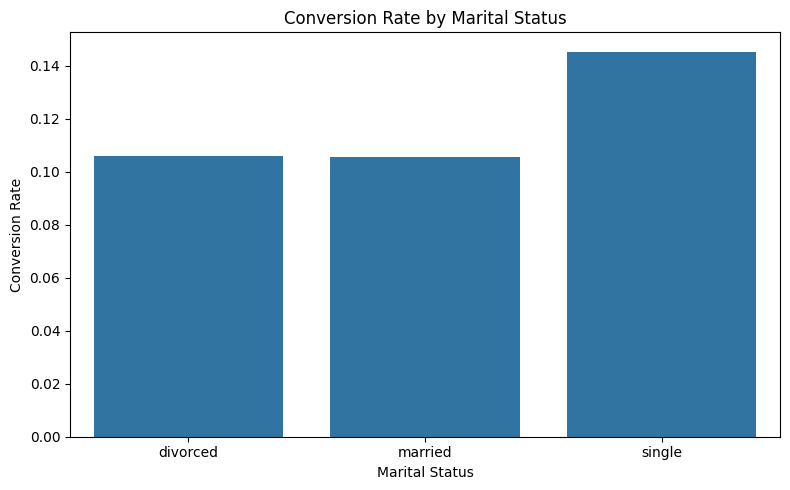

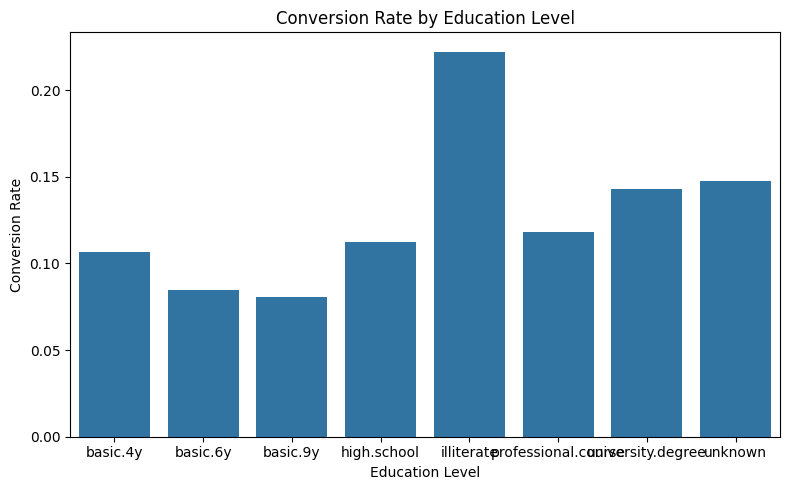

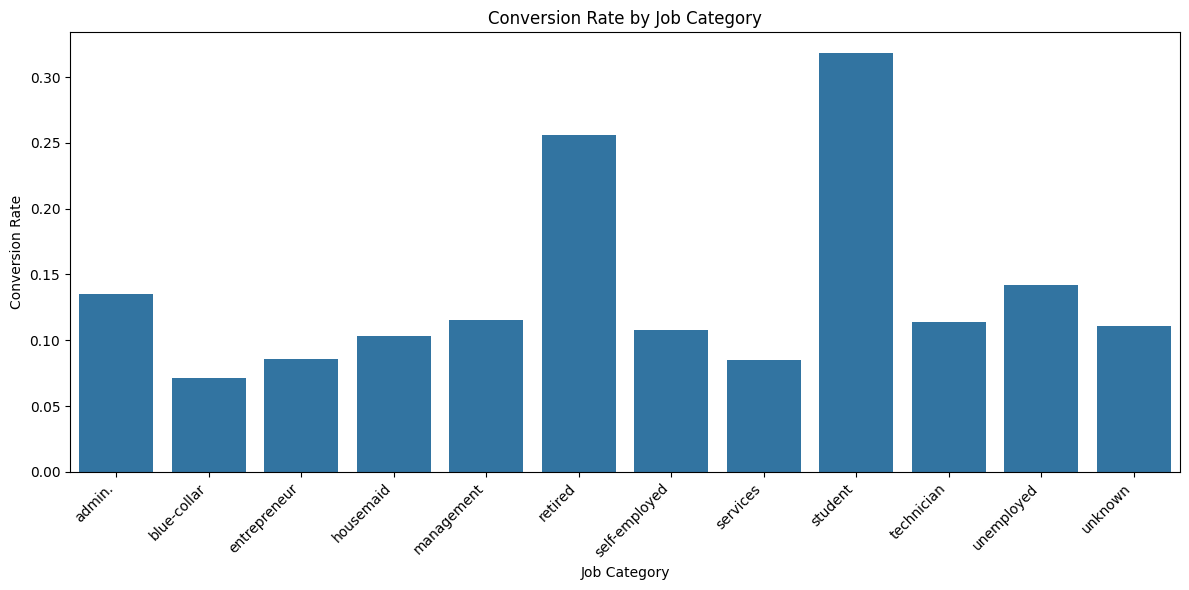

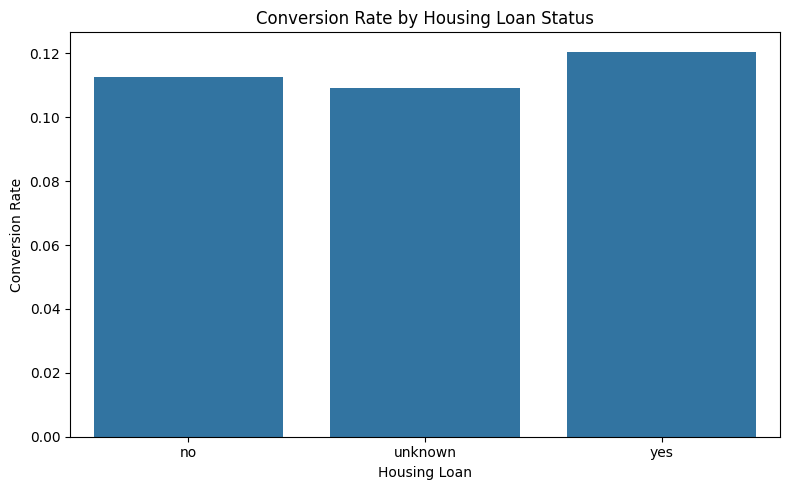

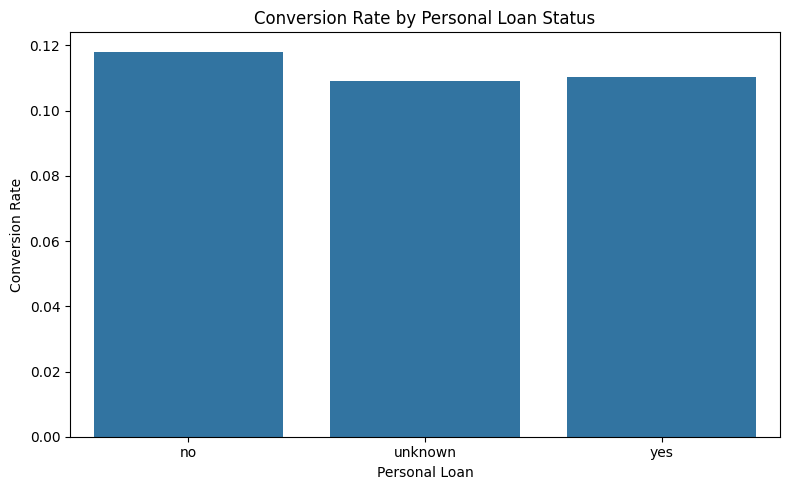

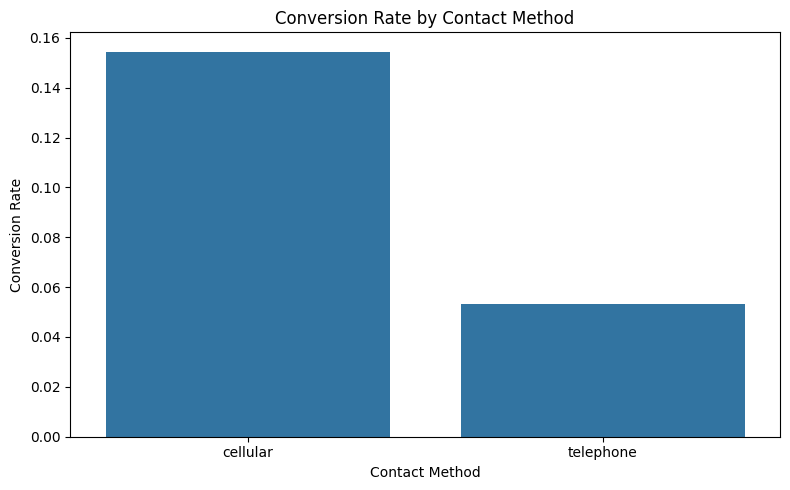

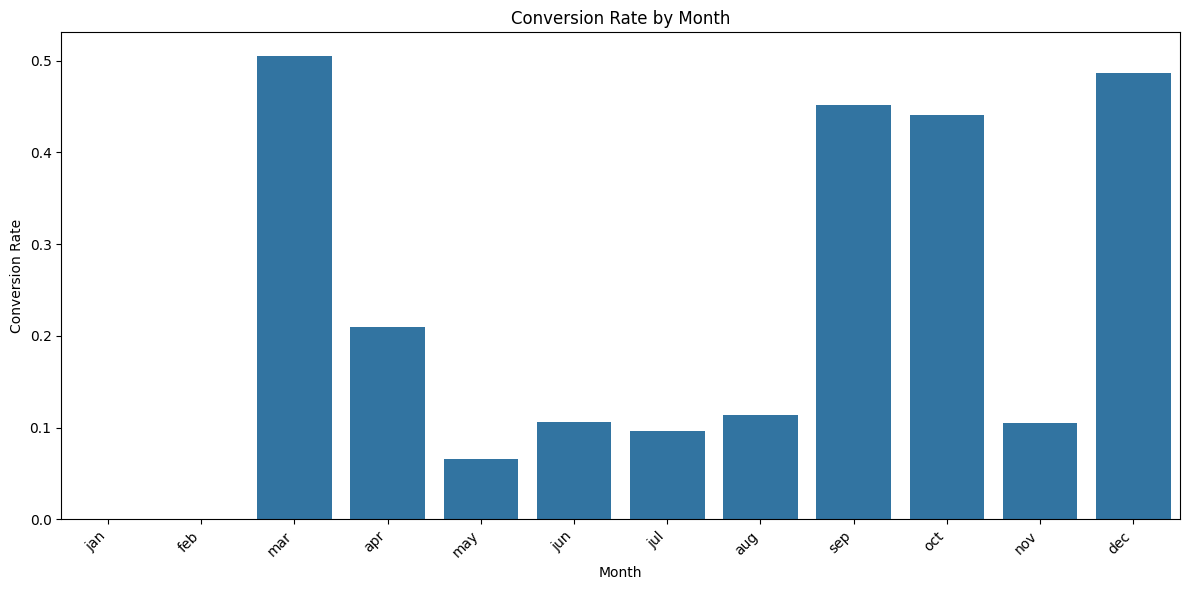

In [ ]:
# @title
# 1. Create a bar plot for age group conversion rate
plt.figure(figsize=(8, 5))
sns.barplot(data=age_group_conversion, x='age_group', y='conversion_rate')
plt.title('Conversion Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

# 2. Create a bar plot for marital status conversion rate
plt.figure(figsize=(8, 5))
sns.barplot(data=marital_conversion, x='marital', y='conversion_rate')
plt.title('Conversion Rate by Marital Status')
plt.xlabel('Marital Status')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

# 3. Create a bar plot for education level conversion rate
plt.figure(figsize=(8, 5))
sns.barplot(data=education_conversion, x='education', y='conversion_rate')
plt.title('Conversion Rate by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()



# 6. Create a bar plot for job category conversion rate
plt.figure(figsize=(12, 6))
sns.barplot(data=job_conversion, x='job', y='conversion_rate')
plt.title('Conversion Rate by Job Category')
plt.xlabel('Job Category')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 7. Create a bar plot for housing loan status conversion rate
plt.figure(figsize=(8, 5))
sns.barplot(data=housing_conversion, x='housing', y='conversion_rate')
plt.title('Conversion Rate by Housing Loan Status')
plt.xlabel('Housing Loan')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

# 8. Create a bar plot for personal loan status conversion rate
plt.figure(figsize=(8, 5))
sns.barplot(data=loan_conversion, x='loan', y='conversion_rate')
plt.title('Conversion Rate by Personal Loan Status')
plt.xlabel('Personal Loan')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

# 9. Create a bar plot for contact method conversion rate
plt.figure(figsize=(8, 5))
sns.barplot(data=contact_conversion, x='contact', y='conversion_rate')
plt.title('Conversion Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Conversion Rate')
plt.tight_layout()
plt.show()

# 10. Create a bar plot for month conversion rate
plt.figure(figsize=(12, 6))
sns.barplot(data=month_conversion, x='month', y='conversion_rate', order=['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec'])
plt.title('Conversion Rate by Month')
plt.xlabel('Month')
plt.ylabel('Conversion Rate')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 4. Feature Selection

We will use Spearman correlation to determine if we have redundant variables that should be removed due to their high correlation.

However, it's important to note that applying Spearman correlation to binary variables may not yield meaningful or accurate results. This correlation measure is more suitable for continuous and ordinal data.

Therefore:

Since our target is binary, we should not consider the correlation of the independent variables with the target variable to understand if they are "important".


In [ ]:
df_act

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,...,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,y,age_group,housing_loan_interaction,pdays_cat
0,housemaid,married,basic.4y,no,no,no,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_no,never_contacted
1,services,married,high.school,unknown,no,no,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_no,never_contacted
2,services,married,high.school,no,yes,no,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,adult,yes_no,never_contacted
3,admin.,married,basic.6y,no,no,no,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,adult,no_no,never_contacted
4,services,married,high.school,no,no,yes,telephone,may,mon,nonexistent,...,0.0,1.1,93.994,-36.4,4.857,5191.0,0,senior,no_yes,never_contacted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,...,0.0,-1.1,94.767,-50.8,1.028,4963.6,1,senior,yes_no,never_contacted
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,...,0.0,-1.1,94.767,-50.8,1.028,4963.6,0,adult,no_no,never_contacted
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,...,0.0,-1.1,94.767,-50.8,1.028,4963.6,0,senior,yes_no,never_contacted
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,...,0.0,-1.1,94.767,-50.8,1.028,4963.6,1,adult,no_no,never_contacted


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 1. Define features and target
target_column = 'y'  # replace with actual target name
X = df_act.drop(columns=target_column)
y = df_act[target_column]

# 2. Identify column types
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

from sklearn.preprocessing import OrdinalEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)

# 4. Time-based split
train_size = int(len(X) * 0.8)
X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

# 5. Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed  = preprocessor.transform(X_test)

print("Train shape:", X_train_processed.shape, y_train.shape)
print("Test shape:", X_test_processed.shape, y_test.shape)




Train shape: (31523, 72) (31523,)
Test shape: (7881, 72) (7881,)


In [ ]:
tscv = TimeSeriesSplit(n_splits=5)

In [ ]:
def cor_heatmap(cor):
    plt.figure(figsize=(9,6))
    sns.heatmap(data = cor, annot = True, cmap = plt.cm.Reds, fmt='.1')
    plt.show()

In [ ]:
categorical_cols =  X.select_dtypes(include=['object', 'category']).columns
def apply_correlation(X_train):

    correlation_data =  X.drop(categorical_cols, axis = 1).copy()
    matrix = correlation_data.corr(method = 'spearman', numeric_only = True)
    cor_heatmap(matrix)

In [ ]:
  categorical_cols = X.select_dtypes(include=['object', 'category']).columns
  categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'age_group',
       'housing_loan_interaction', 'pdays_cat'],
      dtype='object')

In [ ]:
def redundant_features(X,y):
    count = 1
    for train_index, val_index in tscv.split(X,y):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y.iloc[train_index], y.iloc[val_index]

        ######################################### SELECT FEATURES #################################################
        print('_________________________________________________________________________________________________\n')
        print('                                     SPLIT ' + str(count) + '                                    ')
        print('_________________________________________________________________________________________________')

        # check which features to use using spearman correlation
        apply_correlation(X_train)

        count+=1

_________________________________________________________________________________________________

                                     SPLIT 1                                    
_________________________________________________________________________________________________


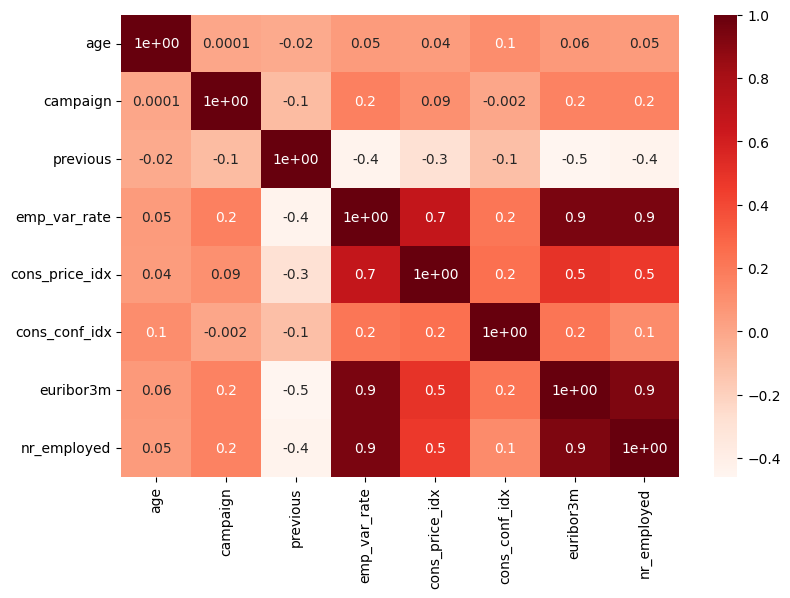

_________________________________________________________________________________________________

                                     SPLIT 2                                    
_________________________________________________________________________________________________


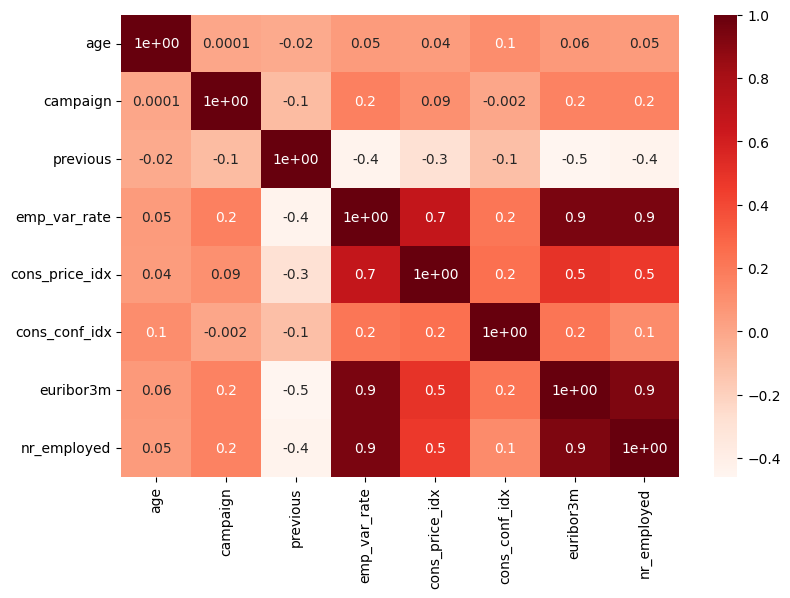

_________________________________________________________________________________________________

                                     SPLIT 3                                    
_________________________________________________________________________________________________


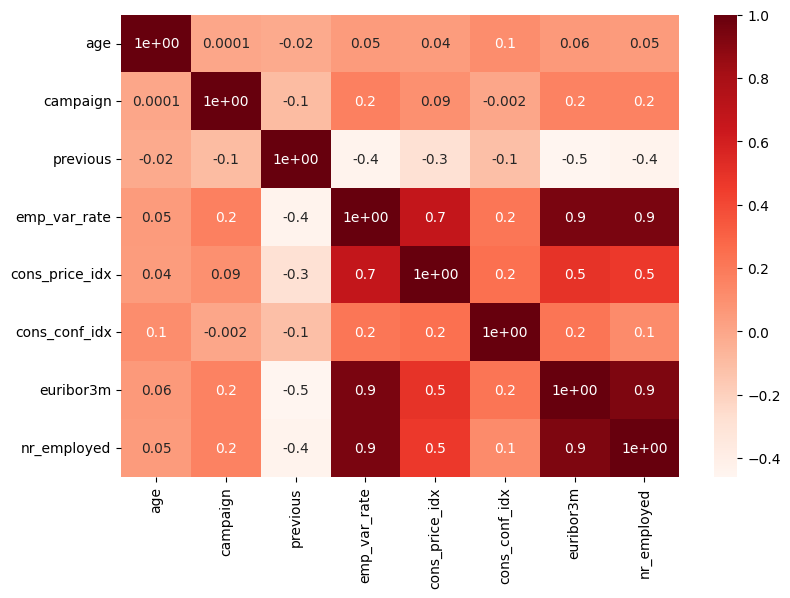

_________________________________________________________________________________________________

                                     SPLIT 4                                    
_________________________________________________________________________________________________


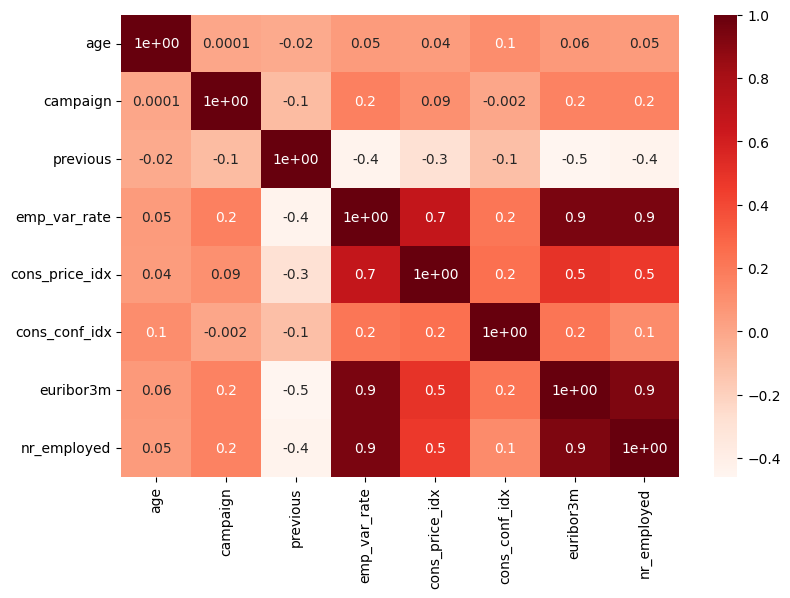

_________________________________________________________________________________________________

                                     SPLIT 5                                    
_________________________________________________________________________________________________


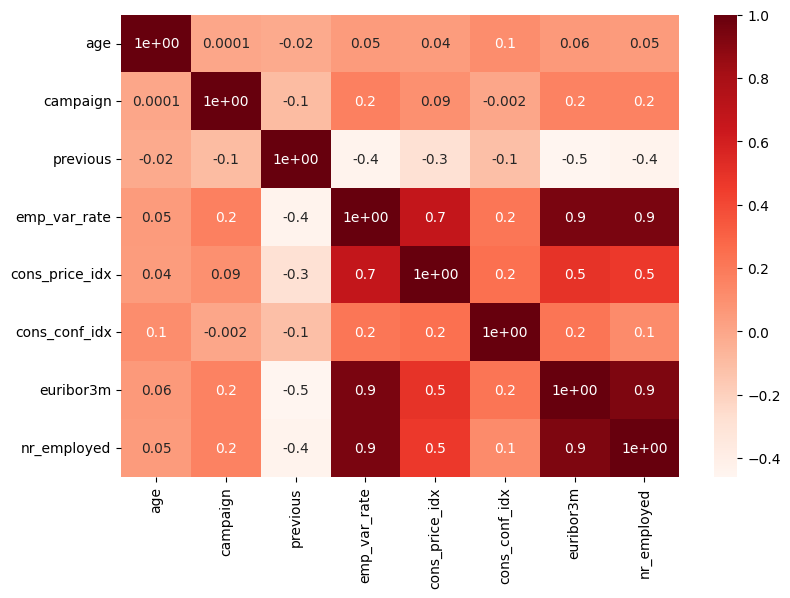

In [ ]:
redundant_features(X, y)

### Redundant Variables - Spearman Correlation (Correlation higher than |0.8|)

| Combination | Split 3 | Split 4 | Split 5 | Split 6 | Split 7 | Split 8 | Split 9 | Split 10 |
|-------------|---------|---------|---------|---------|---------|---------|---------|----------|
| **euribor3m vs emp_var_rate** | **0.8** | **0.9** | **0.9** | **0.8** | **0.9** | **0.9** | **0.9** | **0.9** |
| euribor3m vs cons_conf_idx | -0.8 | -0.9 | -0.9 | -0.6 | -0.1 | 0.3 | 0.5 | 0.5 |
| **euribor3m vs nr_employed** | **0.8** | **0.9** | **0.9** | **0.8** | **0.8** | **0.8** |**0.9** | **0.9** |
| emp_var_rate vs cons_conf_idx | -1.0 | -1.0 | -0.9 | -0.4 | -0.3 | 0.04 | 0.03 | 0.04 |
| **emp_var_rate vs nr_employed** | **1.0** | **1.0** | **1.0** | **1.0** | **0.9** | **0.9** | **0.9** | **1.0** |
| cons_conf_idx vs nr_employed |  |  |  |  |  |  |  |  |

Keep Euribon3m, cons_conf_idx
Remove emp_var_rate, nr_employed


Outliers

In [ ]:
df_act.shape

(39404, 22)

In [ ]:
Q1 = df_act['campaign'].quantile(0.10)
Q3 = df_act['campaign'].quantile(0.90)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_act[(df_act['campaign'] < lower_bound) | (df_act['campaign'] > upper_bound)]

df_act = df_act[(df_act['campaign'] >= lower_bound) & (df_act['campaign'] <= upper_bound)]

In [ ]:
Q1 = df_act['age'].quantile(0.10)
Q3 = df_act['age'].quantile(0.90)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_act[(df_act['age'] < lower_bound) | (df_act['age'] > upper_bound)]

df_act = df_act[(df_act['age'] >= lower_bound) & (df_act['age'] <= upper_bound)]

In [ ]:
Q1 = df_act['cons_conf_idx'].quantile(0.10)
Q3 = df_act['cons_conf_idx'].quantile(0.90)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Identify outliers
outliers = df_act[(df_act['cons_conf_idx'] < lower_bound) | (df_act['cons_conf_idx'] > upper_bound)]

df_act = df_act[(df_act['cons_conf_idx'] >= lower_bound) & (df_act['cons_conf_idx'] <= upper_bound)]

In [ ]:
df_act.shape

(38711, 22)

,0
age,"Axes(0.125,0.653529;0.227941x0.226471)"
campaign,"Axes(0.398529,0.653529;0.227941x0.226471)"
previous,"Axes(0.672059,0.653529;0.227941x0.226471)"
emp_var_rate,"Axes(0.125,0.381765;0.227941x0.226471)"
cons_price_idx,"Axes(0.398529,0.381765;0.227941x0.226471)"
cons_conf_idx,"Axes(0.672059,0.381765;0.227941x0.226471)"
euribor3m,"Axes(0.125,0.11;0.227941x0.226471)"
nr_employed,"Axes(0.398529,0.11;0.227941x0.226471)"
y,"Axes(0.672059,0.11;0.227941x0.226471)"


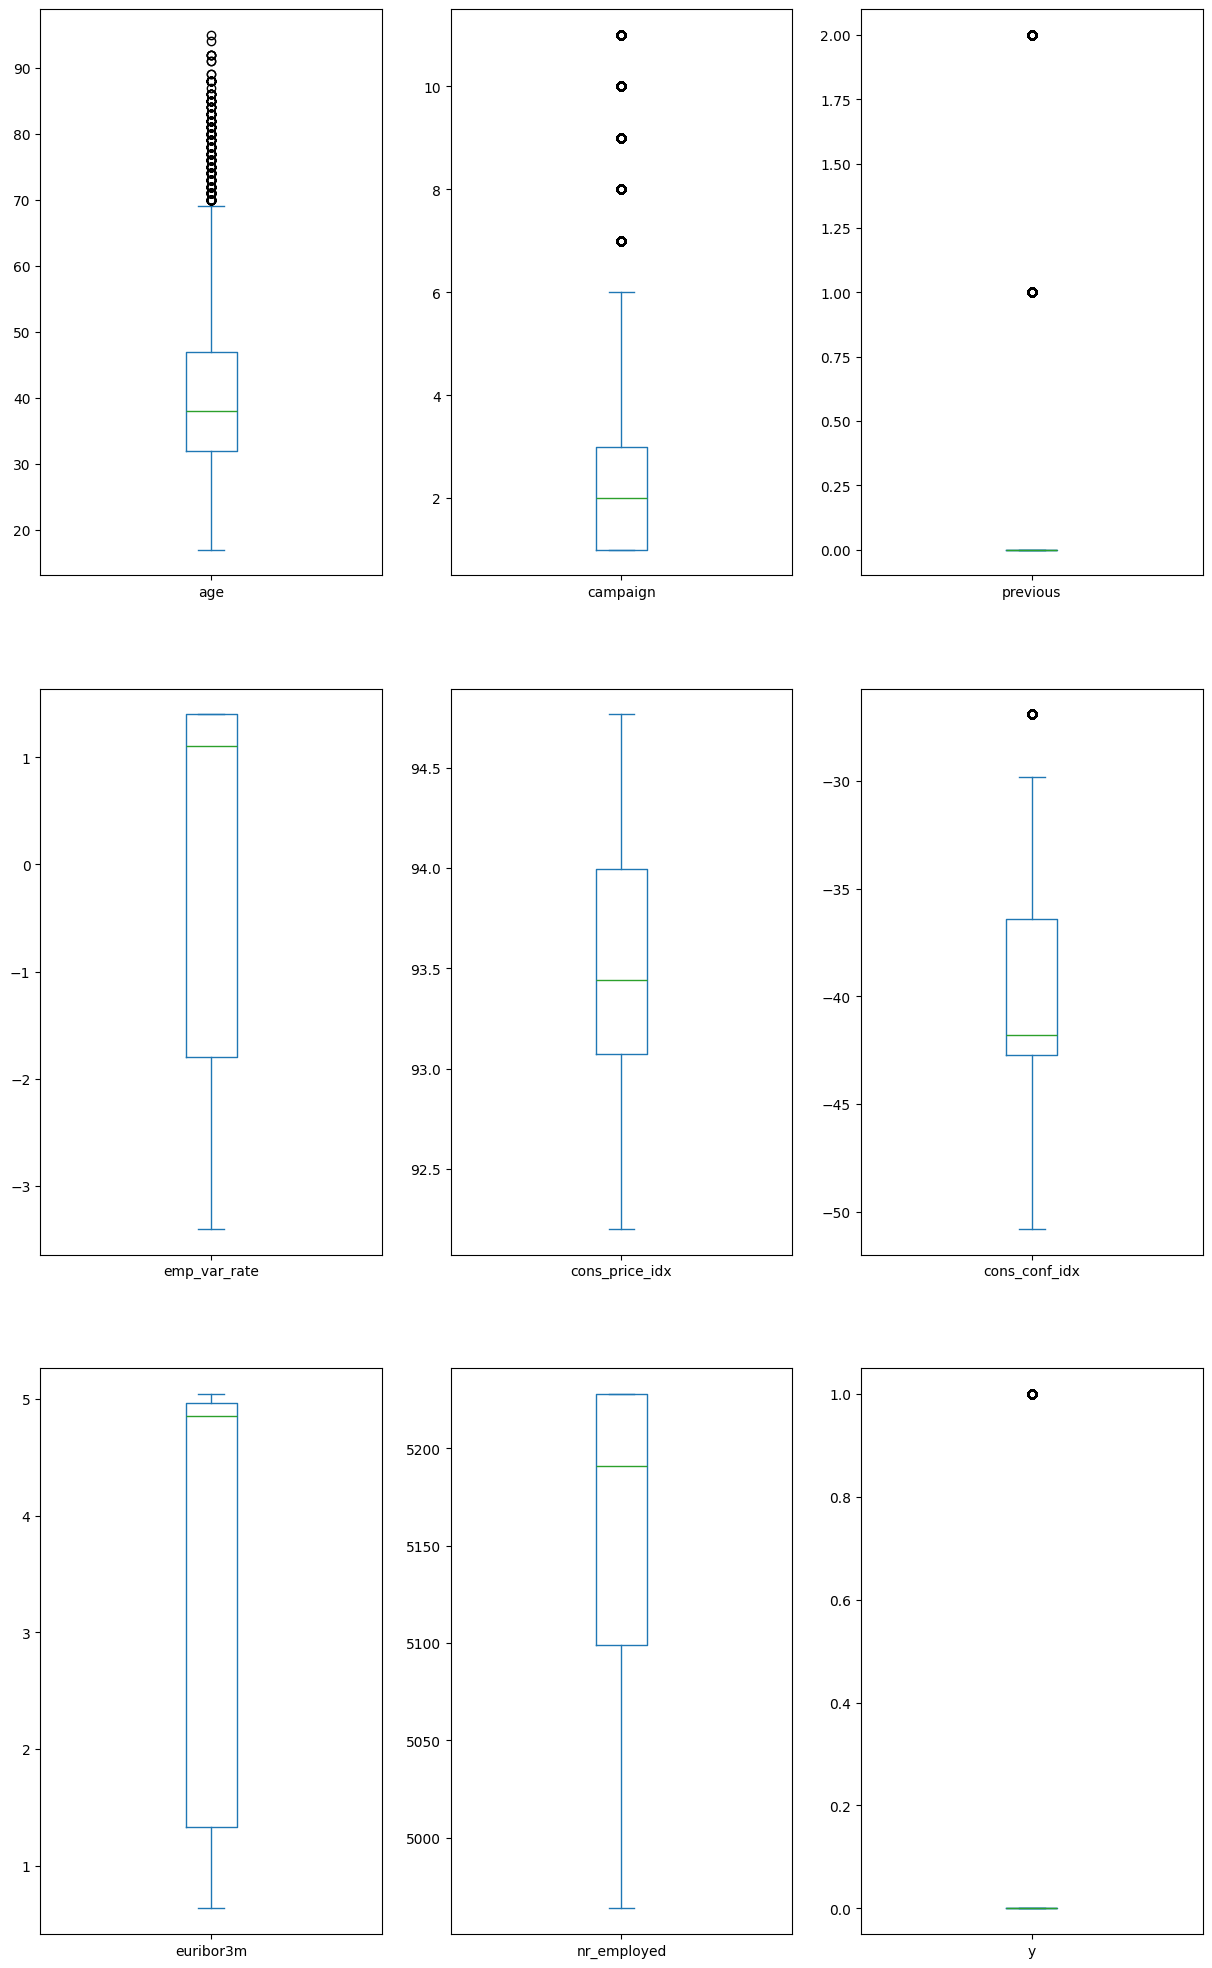

In [ ]:
df_act.plot(kind="box", subplots=True, figsize=(15, 25), layout=(3, 3))

In [ ]:
df_clean = df_act.drop(columns=['nr_employed',"default","campaign", 'previous','poutcome','pdays_cat', 'cons_price_idx']).copy()

#df_clean = df_act.drop(columns=['nr_employed',"default",'campaign', 'previous','poutcome','pdays_cat', 'cons_conf_idx',"emp_var_rate","nr_employed"]).copy()


In [ ]:
df_clean['marital'].value_counts()

,count
marital,
married,23512
single,10815
divorced,4384


In [ ]:
df_clean.shape

(38711, 15)

In [ ]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38711 entries, 0 to 41187
Data columns (total 15 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   job                       38711 non-null  object  
 1   marital                   38711 non-null  object  
 2   education                 38711 non-null  object  
 3   housing                   38711 non-null  object  
 4   loan                      38711 non-null  object  
 5   contact                   38711 non-null  object  
 6   month                     38711 non-null  object  
 7   day_of_week               38711 non-null  object  
 8   age                       38711 non-null  int64   
 9   emp_var_rate              38711 non-null  float64 
 10  cons_conf_idx             38711 non-null  float64 
 11  euribor3m                 38711 non-null  float64 
 12  y                         38711 non-null  int64   
 13  age_group                 38711 non-null  category


In [ ]:

# 2. Time-based split


train_size = int(len(df_clean) * 0.8)
X_train = X.iloc[:train_size]
X_test  = X.iloc[train_size:]
y_train = y.iloc[:train_size]
y_test  = y.iloc[train_size:]

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# 3. Identify column types
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()


preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ]
)


# 5. Fit on train, transform train and test
X_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

# 6. Convert to dense if needed
if hasattr(X_processed, "toarray"):
    X_processed = X_processed.toarray()
    X_test_processed = X_test_processed.toarray()

print("Train shape:", X_processed.shape, y_train.shape)
print("Test shape:", X_test_processed.shape, y_test.shape)

Train shape: (30968, 72) (30968,)
Test shape: (8436, 72) (8436,)


#Models

Evaluation Function

In [ ]:

# ===============================================================
# UNIVERSAL EVALUATION FUNCTION FOR ALL MODELS — Dual Thresholds
# ===============================================================

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

def evaluate_model(pipe, X_test_processed, y_test, model_name="Model", custom_threshold=0.6):
    print(f"\n==================== {model_name} — TEST EVALUATION ====================\n")

    # -----------------------------
    # Predictions
    # -----------------------------
    y_proba = pipe.predict_proba(X_test_processed)[:, 1]
    y_pred_default = (y_proba >= 0.5).astype(int)
    y_pred_custom  = (y_proba >= custom_threshold).astype(int)

    # -----------------------------
    # Confusion Matrices
    # -----------------------------
    cm_default = confusion_matrix(y_test, y_pred_default)
    cm_custom  = confusion_matrix(y_test, y_pred_custom)

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    sns.heatmap(cm_default, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{model_name} — Confusion Matrix @ 0.5")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.subplot(1, 2, 2)
    sns.heatmap(cm_custom, annot=True, fmt='d', cmap='Oranges')
    plt.title(f"{model_name} — Confusion Matrix @ {custom_threshold}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    # -----------------------------
    # Metrics
    # -----------------------------
    metrics_default = {
        "accuracy": accuracy_score(y_test, y_pred_default),
        "precision": precision_score(y_test, y_pred_default, zero_division=0),
        "recall": recall_score(y_test, y_pred_default, zero_division=0),
        "f1": f1_score(y_test, y_pred_default, zero_division=0),
    }

    metrics_custom = {
        "accuracy": accuracy_score(y_test, y_pred_custom),
        "precision": precision_score(y_test, y_pred_custom, zero_division=0),
        "recall": recall_score(y_test, y_pred_custom, zero_division=0),
        "f1": f1_score(y_test, y_pred_custom, zero_division=0),
    }

    roc_auc = roc_auc_score(y_test, y_proba)

    print("Evaluation Metrics — Default (0.5)")
    print("----------------------------------")
    for k, v in metrics_default.items():
        print(f"{k.capitalize():<10}: {v:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}\n")

    print(f"Evaluation Metrics — Custom ({custom_threshold})")
    print("----------------------------------")
    for k, v in metrics_custom.items():
        print(f"{k.capitalize():<10}: {v:.4f}")
    print(f"ROC-AUC   : {roc_auc:.4f}")

    # -----------------------------
    # ROC Curve (same for both thresholds)
    # -----------------------------
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"{model_name} — ROC Curve")
    plt.legend()
    plt.grid(True)
    plt.show()

    # -----------------------------
    # Lift Curves
    # -----------------------------
    def plot_lift(y_true, y_proba, label):
        df = pd.DataFrame({"y_true": y_true, "y_proba": y_proba})
        df = df.sort_values(by="y_proba", ascending=False).reset_index(drop=True)
        df["bucket"] = pd.qcut(df.index, 10, labels=False)
        lift = df.groupby("bucket")["y_true"].mean() / df["y_true"].mean()
        plt.plot(range(1, 11), lift.values, label=label)

    plt.figure(figsize=(7, 4))
    plot_lift(y_test, y_proba, "Lift @ 0.5")
    plot_lift(y_test, y_proba, f"Lift @ {custom_threshold}")
    plt.title(f"{model_name} — Lift Curve Comparison")
    plt.xlabel("Top Deciles")
    plt.ylabel("Lift")
    plt.legend()
    plt.grid(True)
    plt.show()

    return {
        "default_threshold": metrics_default,
        "custom_threshold": metrics_custom,
        "roc_auc": roc_auc
    }

###1. Logistic Regression



In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

tscv = TimeSeriesSplit(n_splits=5)

logreg_pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy='minority', random_state=42)),
    ("model", LogisticRegression(solver="liblinear", class_weight="balanced"))
])

# Cross-validation with per-fold output
cv_results = cross_validate(
    logreg_pipe,
    X_processed,
    y_train,
    cv=tscv,
    scoring="roc_auc",
    return_train_score=False
)

print("ROC-AUC for each fold:")
for i, score in enumerate(cv_results["test_score"], 1):
    print(f"  Fold {i}: {score:.4f}")

print("\nMean CV ROC-AUC:", cv_results["test_score"].mean())

# Train on full train data
logreg_pipe.fit(X_processed, y_train)

# Test predictions
y_pred = logreg_pipe.predict(X_test_processed)
y_proba = logreg_pipe.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))



ROC-AUC for each fold:
  Fold 1: 0.5202
  Fold 2: 0.5113
  Fold 3: 0.5196
  Fold 4: 0.4609
  Fold 5: 0.5855

Mean CV ROC-AUC: 0.5195090343115002

Test Results:
Accuracy: 0.53366524419156
Precision: 0.3789803375674265
Recall: 0.8564687377113646
F1: 0.5254523522316044
ROC-AUC: 0.7312606003817321


####Logistic Regression Grid Search

In [ ]:
from sklearn.model_selection import GridSearchCV

logreg_pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy= 'minority', random_state=42)),
    ("model", LogisticRegression(solver="liblinear"))
])

param_grid = {
    "model__C": [0.01, 0.1, 1,5, 10],
    "model__class_weight": ["balanced", None]
}

gs_logreg = GridSearchCV(
    logreg_pipe,
    param_grid,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1
)

gs_logreg.fit(X_processed, y_train)

print("Best Params:", gs_logreg.best_params_)
print("Best CV ROC-AUC:", gs_logreg.best_score_)

y_pred = gs_logreg.predict(X_test_processed)
y_proba = gs_logreg.predict_proba(X_test_processed)[:, 1]

#Decision threshold
threshold = 0.5
y_pred = (y_proba >= threshold).astype(int)


print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))



Best Params: {'model__C': 0.01, 'model__class_weight': 'balanced'}
Best CV ROC-AUC: 0.5303059507203406

Test Results:
Accuracy: 0.4704836415362731
Precision: 0.3560311284046693
Recall: 0.9355092410538733
F1: 0.5157723577235772
ROC-AUC: 0.7526511756151566



==================== Logistic Regression — TEST EVALUATION ====================



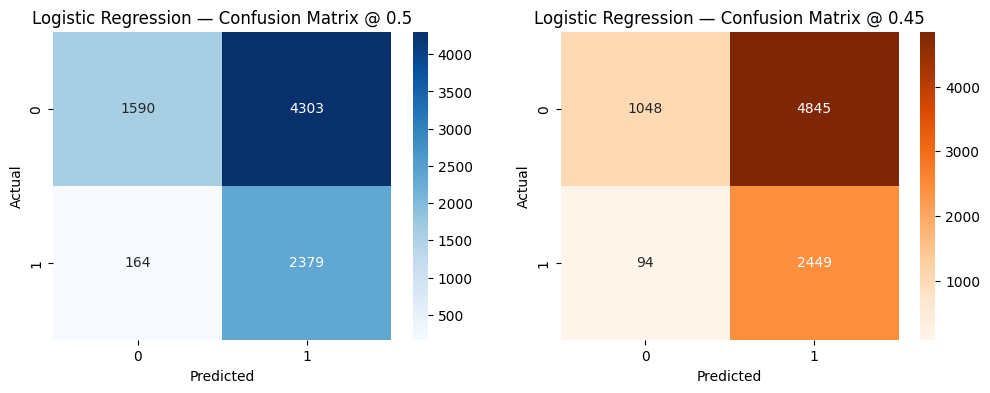

Evaluation Metrics — Default (0.5)
----------------------------------
Accuracy  : 0.4705
Precision : 0.3560
Recall    : 0.9355
F1        : 0.5158
ROC-AUC   : 0.7527

Evaluation Metrics — Custom (0.45)
----------------------------------
Accuracy  : 0.4145
Precision : 0.3358
Recall    : 0.9630
F1        : 0.4979
ROC-AUC   : 0.7527


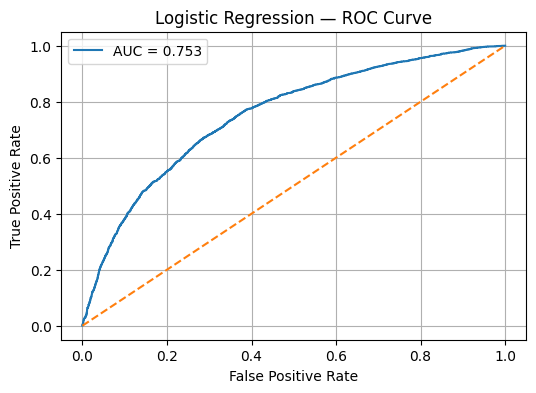

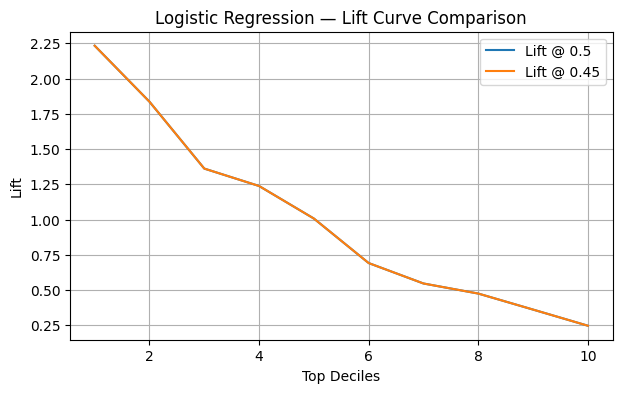

In [ ]:
results = evaluate_model(gs_logreg, X_test_processed, y_test, model_name="Logistic Regression", custom_threshold=0.45)

###2. Decision Trees

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, TimeSeriesSplit

# Example: set up a time series CV
tscv = TimeSeriesSplit(n_splits=5)

tree_pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy='minority',random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

# Run cross-validation
cv_scores = cross_val_score(tree_pipe, X_processed, y_train, cv=tscv, scoring="roc_auc")
print("CV ROC-AUC:", cv_scores.mean())




tree_pipe.fit(X_processed, y_train)
y_pred = tree_pipe.predict(X_test_processed)

y_proba = tree_pipe.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


CV ROC-AUC: 0.5037059169716194

Test Results:
Accuracy: 0.6505452821242295
Precision: 0.34265734265734266
Recall: 0.17341722375147464
F1: 0.23028720626631854
ROC-AUC: 0.5177784128933473


####Decision Trees Grid Search

In [ ]:
param_grid = {
    "model__max_depth": [1,2,3,4,5,6,7,None],
    "model__min_samples_split": [2,3,4, 5, 10],
    'model__criterion': ['gini','entropy'],
    'model__splitter' : ['best','random'],
    'model__max_features' : ['auto','sqrt','log2',None]
}

tree_pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy='minority',random_state=42)),
    ("model", DecisionTreeClassifier(random_state=42))
])

gs_dt = GridSearchCV(tree_pipe, param_grid, scoring="roc_auc", cv=tscv)
gs_dt.fit(X_processed, y_train)

print("Best Params:", gs_dt.best_params_)
print("Best CV ROC-AUC:", gs_dt.best_score_)

y_pred = gs_dt.predict(X_test_processed)
y_proba = gs_dt.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning:


800 fits failed out of a total of 3200.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
800 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1389, in wrapper
    return fit_method(estimator, *args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/imblearn/pipeline.py", line 526, in fit
    self._final_estimator.fit(Xt, y

Best Params: {'model__criterion': 'gini', 'model__max_depth': 4, 'model__max_features': None, 'model__min_samples_split': 2, 'model__splitter': 'random'}
Best CV ROC-AUC: 0.5182743699330218

Test Results:
Accuracy: 0.6325272641062115
Precision: 0.44019755207214945
Recall: 0.8061344868265827
F1: 0.5694444444444444
ROC-AUC: 0.6973152895265076



==================== Decision Trees — TEST EVALUATION ====================



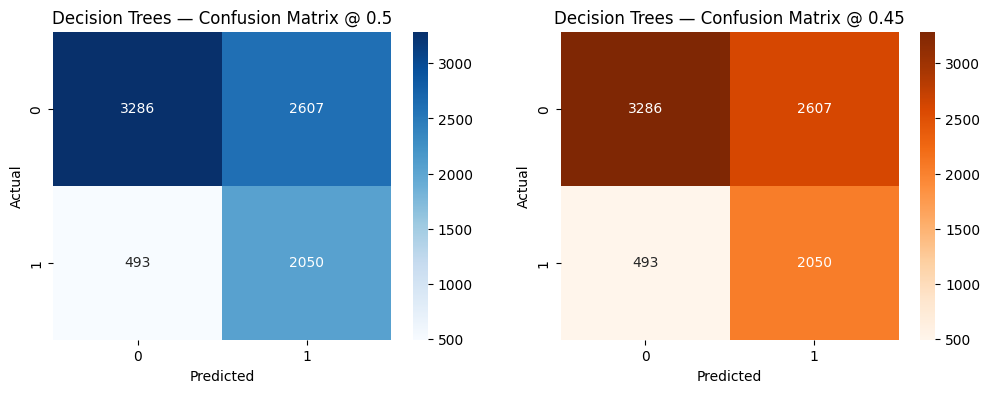

Evaluation Metrics — Default (0.5)
----------------------------------
Accuracy  : 0.6325
Precision : 0.4402
Recall    : 0.8061
F1        : 0.5694
ROC-AUC   : 0.6973

Evaluation Metrics — Custom (0.45)
----------------------------------
Accuracy  : 0.6325
Precision : 0.4402
Recall    : 0.8061
F1        : 0.5694
ROC-AUC   : 0.6973


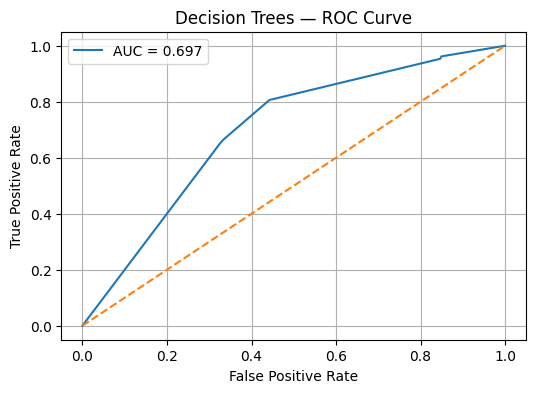

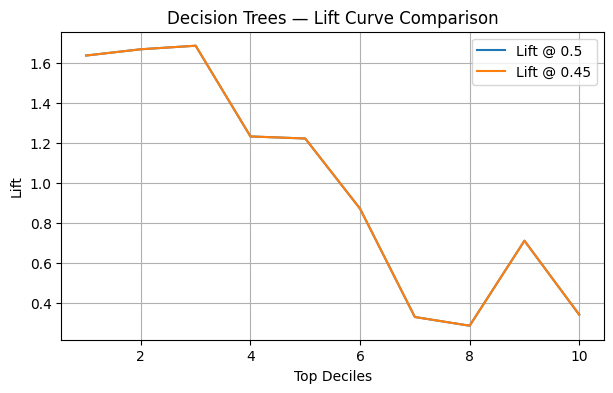

In [ ]:
results = evaluate_model(gs_dt, X_test_processed, y_test, model_name="Decision Trees", custom_threshold=0.45)

###3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

tscv = TimeSeriesSplit(n_splits=5)

rf_pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy='minority',random_state=42)),
    ("model", RandomForestClassifier(n_estimators=200, random_state=42))
])

cv_scores = cross_val_score(rf_pipe, X_processed, y_train, cv=tscv, scoring="roc_auc")
print("CV ROC-AUC:", cv_scores.mean())

rf_pipe.fit(X_processed, y_train)
y_pred = rf_pipe.predict(X_test_processed)
y_proba = rf_pipe.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


CV ROC-AUC: 0.5131727105265301

Test Results:
Accuracy: 0.6999762920815552
Precision: 0.5236220472440944
Recall: 0.05230043255996854
F1: 0.09510189488737933
ROC-AUC: 0.7189993072821323


####Random Forest Grid Search

In [ ]:
param_grid = {
    "model__n_estimators": [200,250, 300,350],
    "model__max_depth": [4,5,6,7,8],
    "model__min_samples_split": [2,3,4,5]
}

rf_pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy='minority',random_state=42)),
    ("model", RandomForestClassifier(random_state=42))
])

gs_rf = GridSearchCV(rf_pipe, param_grid, scoring="roc_auc", cv=tscv, n_jobs=-1)
gs_rf.fit(X_processed, y_train)

print("Best Params:", gs_rf.best_params_)
print("Best CV ROC-AUC:", gs_rf.best_score_)

y_pred = gs_rf.predict(X_test_processed)
y_proba = gs_rf.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Best Params: {'model__max_depth': 8, 'model__min_samples_split': 2, 'model__n_estimators': 350}
Best CV ROC-AUC: 0.5015247012240674

Test Results:
Accuracy: 0.6679706021811285
Precision: 0.4621700879765396
Recall: 0.6197404640188754
F1: 0.5294809339828658
ROC-AUC: 0.7008014000361273



==================== Random Forest — TEST EVALUATION ====================



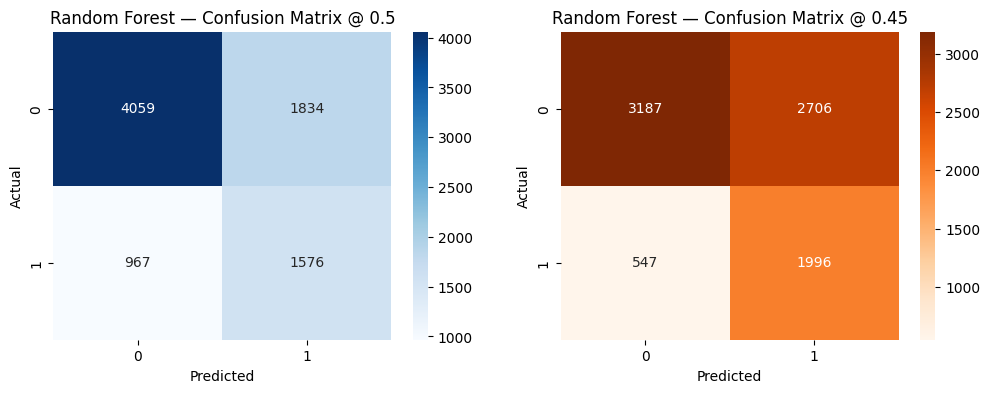

Evaluation Metrics — Default (0.5)
----------------------------------
Accuracy  : 0.6680
Precision : 0.4622
Recall    : 0.6197
F1        : 0.5295
ROC-AUC   : 0.7008

Evaluation Metrics — Custom (0.45)
----------------------------------
Accuracy  : 0.6144
Precision : 0.4245
Recall    : 0.7849
F1        : 0.5510
ROC-AUC   : 0.7008


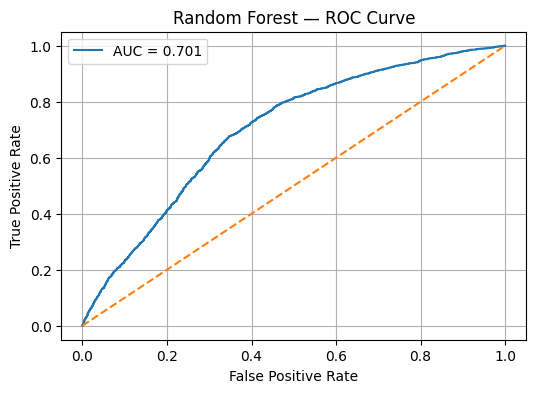

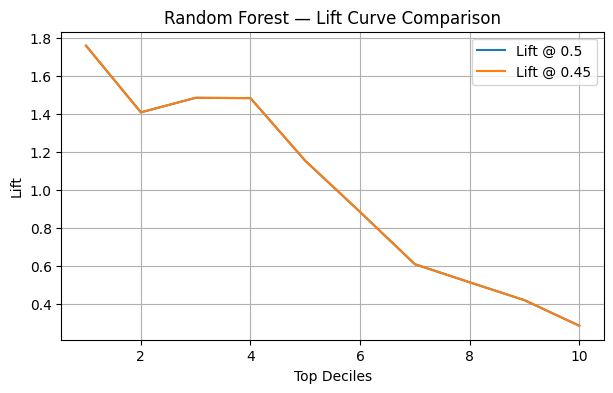

In [ ]:
results = evaluate_model(gs_rf, X_test_processed, y_test, model_name="Random Forest", custom_threshold=0.45)

###4. Support Vector Machines (SVM)

In [ ]:
from sklearn.svm import SVC

svm_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(kernel="rbf", probability=True))
])

cv_scores = cross_val_score(svm_pipe, X_processed, y_train, cv=tscv, scoring="roc_auc")
print("CV ROC-AUC:", cv_scores.mean())

svm_pipe.fit(X_processed, y_train)
y_pred = svm_pipe.predict(X_test_processed)
y_proba = svm_pipe.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


CV ROC-AUC: 0.46002165623322144

Test Results:
Accuracy: 0.670697012802276
Precision: 0.12218649517684887
Recall: 0.014942980731419583
F1: 0.026629292221443588
ROC-AUC: 0.3065105069772591


####SVM Grid Search

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform

param_dist = {
    "model__kernel": ["linear", "rbf"],
    "model__C": uniform(0.01, 10),
    "model__gamma": ["scale", "auto"],
    "model__class_weight": ["balanced"]
}

svm_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", SVC(probability=True))
])

rs_svm = RandomizedSearchCV(
    svm_pipe,
    param_distributions=param_dist,
    n_iter=12,               # only 12 random configs!
    scoring="roc_auc",
    cv=tscv,
    n_jobs=-1,
    random_state=42
)

rs_svm.fit(X_processed, y_train)


print("Best Params:", rs_svm.best_params_)
print("Best CV ROC-AUC:", rs_svm.best_score_)

y_pred = rs_svm.predict(X_test_processed)
y_proba = rs_svm.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


KeyboardInterrupt: 

In [ ]:
results = evaluate_model(rs_svm, X_test_processed, y_test, model_name="Support Vector Machine", custom_threshold=0.45)

###5. Neural Networks

In [1]:
from sklearn.neural_network import MLPClassifier

mlp_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", MLPClassifier(hidden_layer_sizes=(32,16), max_iter=300, random_state=42))
])

cv_scores = cross_val_score(mlp_pipe, X_processed, y_train, cv=tscv, scoring="roc_auc")
print("CV ROC-AUC:", cv_scores.mean())

mlp_pipe.fit(X_processed, y_train)
y_pred = mlp_pipe.predict(X_test_processed)
y_proba = mlp_pipe.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


NameError: name 'Pipeline' is not defined

####Neural Networks Grid Search

In [ ]:
param_grid = {
    "model__hidden_layer_sizes": [(32,), (64,), (32,16)],
    "model__alpha": [0.0001, 0.001],
    "model__learning_rate_init": [0.001, 0.01]
}

mlp_pipe = Pipeline([
    ("smote", SMOTE(random_state=42)),
    ("model", MLPClassifier(max_iter=300, random_state=42))
])

gs_nn = GridSearchCV(mlp_pipe, param_grid, scoring="roc_auc", cv=tscv, n_jobs=-1)
gs_nn.fit(X_processed, y_train)

print("Best Params:", gs_nn.best_params_)
print("Best CV ROC-AUC:", gs_nn.best_score_)

y_pred = gs_nn.predict(X_test_processed)
y_proba = gs_nn.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Best Params: {'model__alpha': 0.0001, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.01}
Best CV ROC-AUC: 0.494533334482491

Test Results:
Accuracy: 0.6672593646277857
Precision: 0.31868131868131866
Recall: 0.09123082972866693
F1: 0.14185264445123816
ROC-AUC: 0.42687292233852636



==================== Neural Network — TEST EVALUATION ====================



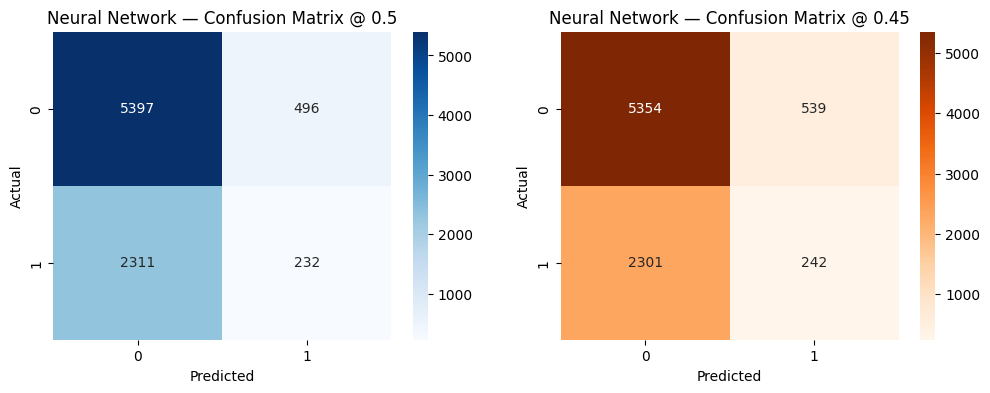

Evaluation Metrics — Default (0.5)
----------------------------------
Accuracy  : 0.6673
Precision : 0.3187
Recall    : 0.0912
F1        : 0.1419
ROC-AUC   : 0.4269

Evaluation Metrics — Custom (0.45)
----------------------------------
Accuracy  : 0.6633
Precision : 0.3099
Recall    : 0.0952
F1        : 0.1456
ROC-AUC   : 0.4269


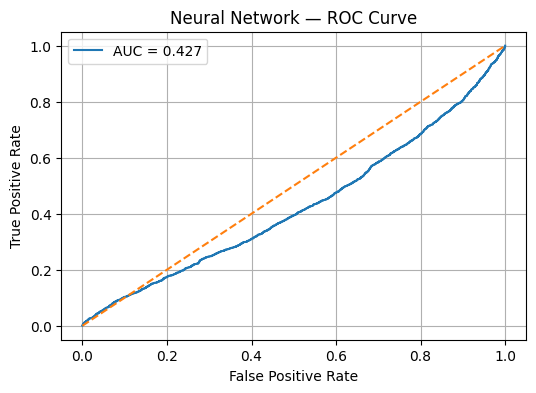

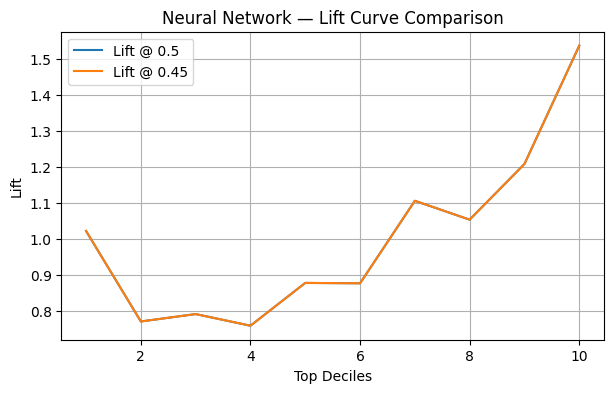

In [ ]:
results = evaluate_model(gs_nn, X_test_processed, y_test, model_name="Neural Network", custom_threshold=0.45)

###XGBoost


In [2]:
from xgboost import XGBClassifier

tscv = TimeSeriesSplit(n_splits=5)

xgb_pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy='minority', random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        n_estimators=300,
        learning_rate=0.05,
        max_depth=4,
        subsample=0.9,
        colsample_bytree=0.9,
        scale_pos_weight=1,   # we override via SMOTE
        random_state=42,
        n_jobs=-1
    ))
])

# Cross-validation
cv_results = cross_validate(
    xgb_pipe,
    X_processed,
    y_train,
    cv=tscv,
    scoring="roc_auc",
    return_train_score=False
)

print("XGBoost ROC-AUC for each fold:")
for i, score in enumerate(cv_results["test_score"], 1):
    print(f"  Fold {i}: {score:.4f}")

print("\nMean CV ROC-AUC:", cv_results["test_score"].mean())

# Train on all training data
xgb_pipe.fit(X_processed, y_train)

# Test predictions
y_pred = xgb_pipe.predict(X_test_processed)
y_proba = xgb_pipe.predict_proba(X_test_processed)[:, 1]

print("\nTest Results:")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


NameError: name 'TimeSeriesSplit' is not defined

###XGBoost Grid Search

In [ ]:


xgb_pipe = Pipeline([
    ("smote", SMOTE(sampling_strategy='minority', random_state=42)),
    ("model", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=42,
        n_jobs=-1
    ))
])

param_grid = {
    "model__n_estimators": [200, 300, 500],
    "model__learning_rate": [0.01, 0.05, 0.1],
    "model__max_depth": [3, 4, 5],
    "model__subsample": [0.8, 1.0],
    "model__colsample_bytree": [0.8, 1.0]
}

gs_xgb = GridSearchCV(
    xgb_pipe,
    param_grid,
    cv=tscv,
    scoring="roc_auc",
    n_jobs=-1,
    verbose=1
)

gs_xgb.fit(X_processed, y_train)

print("Best Params:", gs_xgb.best_params_)
print("Best CV ROC-AUC:", gs_xgb.best_score_)

# Test
y_pred = gs_xgb.predict(X_test_processed)
y_proba = gs_xgb.predict_proba(X_test_processed)[:, 1]

print("\nTest Results (with best estimator):")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1:", f1_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_proba))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Params: {'model__colsample_bytree': 1.0, 'model__learning_rate': 0.1, 'model__max_depth': 5, 'model__n_estimators': 200, 'model__subsample': 1.0}
Best CV ROC-AUC: 0.5212934310732964

Test Results (with best estimator):
Accuracy: 0.7000948316737791
Precision: 0.525691699604743
Recall: 0.05230043255996854
F1: 0.09513590844062947
ROC-AUC: 0.6152658242258272



==================== XGBoost — TEST EVALUATION ====================



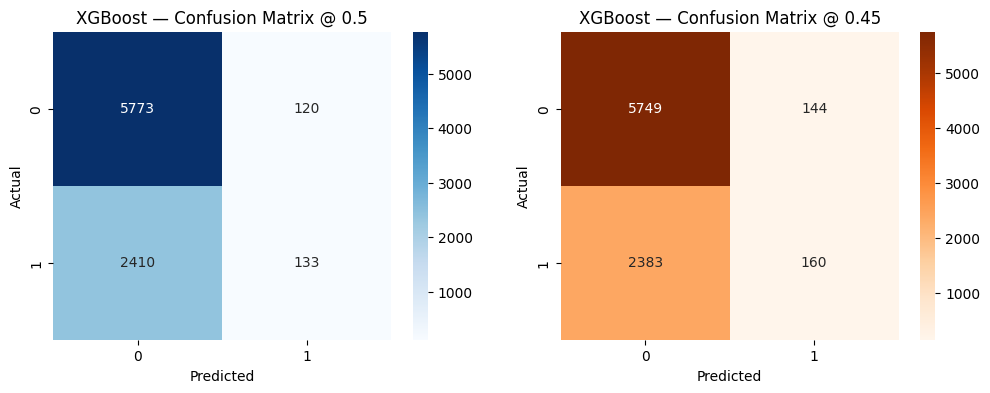

Evaluation Metrics — Default (0.5)
----------------------------------
Accuracy  : 0.7001
Precision : 0.5257
Recall    : 0.0523
F1        : 0.0951
ROC-AUC   : 0.6153

Evaluation Metrics — Custom (0.45)
----------------------------------
Accuracy  : 0.7005
Precision : 0.5263
Recall    : 0.0629
F1        : 0.1124
ROC-AUC   : 0.6153


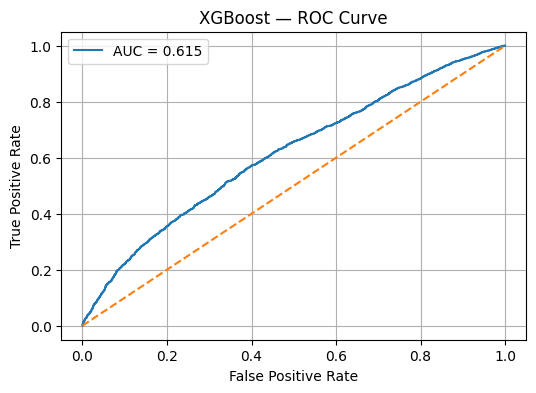

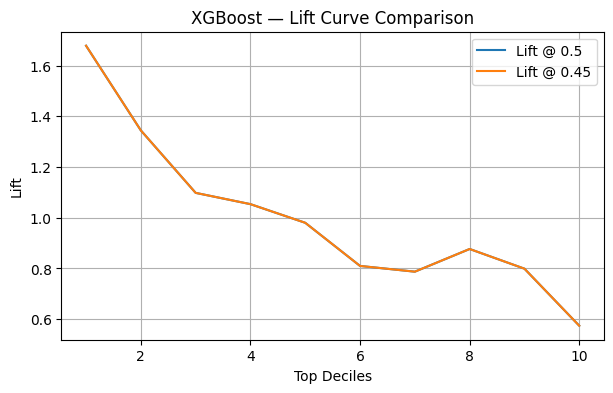

In [ ]:
results = evaluate_model(gs_xgb, X_test_processed, y_test, model_name="XGBoost", custom_threshold=0.45)

Model Comparison

In [ ]:
models = {
    "LogisticRegression": gs_logreg.best_estimator_,   # or logreg_pipe after .fit
    "DecisionTree": gs_dt.best_estimator_,
    "RandomForest": gs_rf.best_estimator_,
    ##"SVM": gs_svm.best_estimator_,
    "NeuralNet": gs_nn.best_estimator_,
    "XGBoost": gs_xgb.best_estimator_
}


Creating a csv file with Model comparison table

In [ ]:
# ===== Model comparison table =====
import numpy as np
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score
)

def lift_at_k(y_true, y_score, k=0.10):
    # top k fraction lift
    df = pd.DataFrame({"y": np.array(y_true), "score": np.array(y_score)})
    df = df.sort_values("score", ascending=False).reset_index(drop=True)
    n_top = max(1, int(np.floor(k * len(df))))
    top_pos = df.loc[:n_top-1, "y"].sum()
    overall_rate = df["y"].sum() / len(df)
    if overall_rate == 0:
        return np.nan
    return (top_pos / n_top) / overall_rate

results = []
for name, pipe in models.items():
    print(f"Evaluating {name} ...")
    # ensure the model is fitted
    try:
        y_proba = pipe.predict_proba(X_test_processed)[:,1]
    except Exception:
        # fallback: decision_function or predictions
        try:
            y_proba = pipe.decision_function(X_test_processed)
        except Exception:
            # last resort: binary predictions as 0/1 probabilities
            y_proba = pipe.predict(X_test_processed).astype(float)

    y_pred = (y_proba >= 0.45).astype(int) if y_proba.ndim==1 else pipe.predict(X_test_processed)

    res = {
        "model": name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall": recall_score(y_test, y_pred, zero_division=0),
        "f1": f1_score(y_test, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "lift@10%": lift_at_k(y_test, y_proba, 0.10),
        "lift@20%": lift_at_k(y_test, y_proba, 0.20)
    }
    results.append(res)

comp_df = pd.DataFrame(results).set_index("model").sort_values("roc_auc", ascending=False)
display(comp_df)

# Save CSV for report
comp_df.to_csv("/content/drive/MyDrive/telemarketing project/model_comparison.csv")
print("Saved model comparison to /mnt/data/model_comparison.csv")


Evaluating LogisticRegression ...
Evaluating DecisionTree ...
Evaluating RandomForest ...
Evaluating NeuralNet ...
Evaluating XGBoost ...


,accuracy,precision,recall,f1,roc_auc,lift@10%,lift@20%
model,,,,,,,
LogisticRegression,0.414533,0.335755,0.963036,0.497916,0.752651,2.235172,2.035239
RandomForest,0.614391,0.424500,0.784900,0.551001,0.700801,1.759017,1.582964
DecisionTree,0.632527,0.440198,0.806134,0.569444,0.697315,1.640963,1.653755
XGBoost,0.700450,0.526316,0.062918,0.112399,0.615266,1.680314,1.510207
NeuralNet,0.663348,0.309859,0.095163,0.145608,0.426873,1.019207,0.896685


Saved model comparison to /mnt/data/model_comparison.csv


####Unified Training + Test Confusion Matrix Function

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

def plot_train_test_confusion(model, X_train, y_train, X_test, y_test, model_name="Model"):
    # ============================================
    # Helper function to annotate confusion matrix
    # ============================================
    def plot_cm(cm, title):
        plt.figure(figsize=(6,4))

        # Labels for TN, FP, FN, TP
        group_labels = ["TN", "FP", "FN", "TP"]
        group_counts = [f"{value}" for value in cm.flatten()]
        labels = [f"{name}\n{count}" for name, count in zip(group_labels, group_counts)]
        labels = np.asarray(labels).reshape(2,2)

        sns.heatmap(
            cm,
            annot=labels,
            fmt="",
            cmap="Blues" if "Train" in title else "Greens",
            cbar=False
        )

        plt.title(title)
        plt.xlabel("Predicted")
        plt.ylabel("Actual")
        plt.show()

    # -------- TRAIN CONFUSION MATRIX --------
    y_train_pred = model.predict(X_train)
    cm_train = confusion_matrix(y_train, y_train_pred)
    plot_cm(cm_train, f"{model_name} — Training Confusion Matrix")

    # -------- TEST CONFUSION MATRIX --------
    y_test_pred = model.predict(X_test)
    cm_test = confusion_matrix(y_test, y_test_pred)
    plot_cm(cm_test, f"{model_name} — Test Confusion Matrix")

    return cm_train, cm_test


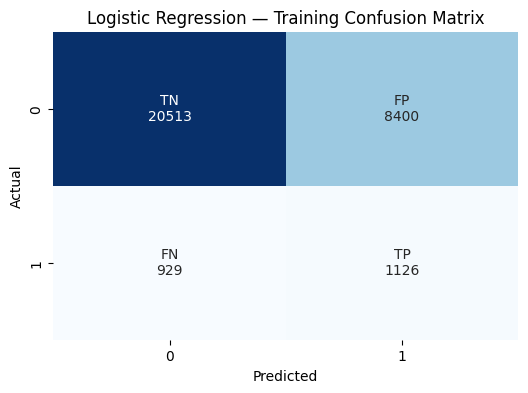

ValueError: Found input variables with inconsistent numbers of samples: [6194, 8436]

In [ ]:
plot_train_test_confusion(
    gs_logreg,
    X_processed, y_train,
    X_test_processed, y_test,
    model_name="Logistic Regression"
)


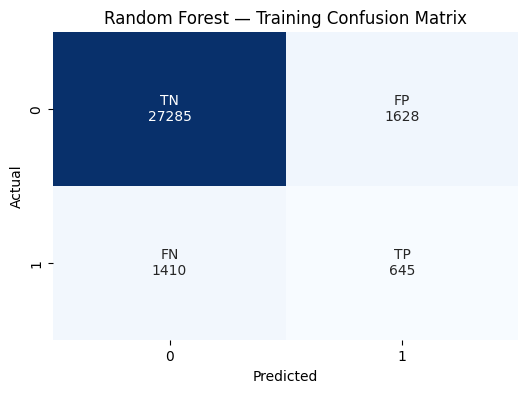

ValueError: Found input variables with inconsistent numbers of samples: [6194, 8436]

In [ ]:
plot_train_test_confusion(
    gs_rf,
    X_processed, y_train,
    X_test_processed, y_test,
    model_name="Random Forest"
)


###Error Analysis

In [ ]:
#Using Logistric Regression

y_pred = gs_logreg.predict(X_test_processed)
y_proba = gs_logreg.predict_proba(X_test_processed)[:, 1]

In [ ]:
errors = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "y_proba": y_proba
}, index=X_test.index)

false_positives = errors[(errors["y_true"] == 0) & (errors["y_pred"] == 1)]
false_negatives = errors[(errors["y_true"] == 1) & (errors["y_pred"] == 0)]

In [ ]:
false_negatives

,y_true,y_pred,y_proba
32638,1,0,0.436552
32654,1,0,0.466004
32665,1,0,0.457811
32668,1,0,0.398297
32843,1,0,0.490785
...,...,...,...
39018,1,0,0.495770
39411,1,0,0.414258
39479,1,0,0.471648
39485,1,0,0.462818


In [ ]:
### 2. **Merge Back Features**
##- Joining these error subsets with the original feature set (`X_test`) to see which customer attributes are common in misclassifications:

fp_analysis = X_test.loc[false_positives.index]
fn_analysis = X_test.loc[false_negatives.index]


In [ ]:
#fp_analysis["job"].value_counts(normalize=True)
fn_analysis["education"].value_counts(normalize=True)


,proportion
education,
high.school,0.237805
university.degree,0.195122
basic.9y,0.164634
basic.4y,0.164634
professional.course,0.140244
unknown,0.067073
basic.6y,0.030488


In [ ]:
X_test

,job,marital,education,default,housing,loan,contact,month,day_of_week,poutcome,...,campaign,previous,emp_var_rate,cons_price_idx,cons_conf_idx,euribor3m,nr_employed,age_group,housing_loan_interaction,pdays_cat
32583,blue-collar,single,basic.6y,unknown,yes,no,cellular,may,mon,nonexistent,...,1.0,0.0,-1.8,92.893,-46.2,1.299,5099.1,adult,yes_no,never_contacted
32584,services,single,high.school,no,yes,no,cellular,may,mon,nonexistent,...,1.0,0.0,-1.8,92.893,-46.2,1.299,5099.1,adult,yes_no,never_contacted
32585,blue-collar,single,high.school,unknown,yes,no,cellular,may,mon,nonexistent,...,1.0,0.0,-1.8,92.893,-46.2,1.299,5099.1,adult,yes_no,never_contacted
32586,blue-collar,married,basic.6y,no,no,no,cellular,may,mon,nonexistent,...,1.0,0.0,-1.8,92.893,-46.2,1.299,5099.1,adult,no_no,never_contacted
32587,blue-collar,married,basic.4y,unknown,unknown,unknown,cellular,may,mon,nonexistent,...,2.0,0.0,-1.8,92.893,-46.2,1.299,5099.1,adult,unknown_unknown,never_contacted
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41183,retired,married,professional.course,no,yes,no,cellular,nov,fri,nonexistent,...,1.0,0.0,-1.1,94.767,-50.8,1.028,4963.6,senior,yes_no,never_contacted
41184,blue-collar,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,...,1.0,0.0,-1.1,94.767,-50.8,1.028,4963.6,adult,no_no,never_contacted
41185,retired,married,university.degree,no,yes,no,cellular,nov,fri,nonexistent,...,2.0,0.0,-1.1,94.767,-50.8,1.028,4963.6,senior,yes_no,never_contacted
41186,technician,married,professional.course,no,no,no,cellular,nov,fri,nonexistent,...,1.0,0.0,-1.1,94.767,-50.8,1.028,4963.6,adult,no_no,never_contacted


Tensorflow

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from sklearn.metrics import accuracy_score

import random
import os

# Set global seed
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)


In [ ]:
# Chronological split: train on past, test on future
train_size = int(len(X_processed) * 0.8)
X_train_full, X_test = X_processed[:train_size], X_processed[train_size:]
y_train_full, y_test = y_train[:train_size], y_train[train_size:]

In [ ]:
from sklearn.model_selection import train_test_split

# Stratified split from training portion
X_train_tf, X_val_tf, y_train_tf, y_val_tf = train_test_split(
    X_train_full, y_train_full,
    test_size=0.2,
    stratify=y_train_full,   # ensures both classes appear
    shuffle=True,            # required for stratification
    random_state=42
)

print("Train class distribution:", pd.Series(y_train_tf).value_counts())
print("Val class distribution:", pd.Series(y_val_tf).value_counts())

Train class distribution: y
0    18825
1      994
Name: count, dtype: int64
Val class distribution: y
0    4707
1     248
Name: count, dtype: int64


In [ ]:
print(pd.Series(y_val_tf).value_counts())

y
0    4707
1     248
Name: count, dtype: int64


In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model(input_dim):
    model = Sequential([
        Dense(units=32, activation='relu', input_shape=(input_dim,)),
        Dropout(0.25),
        Dense(units=16, activation='relu'),
        Dense(units=1, activation='sigmoid')
    ])
    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=[
            tf.keras.metrics.Precision(name="precision"),
            tf.keras.metrics.Recall(name="recall"),
            tf.keras.metrics.AUC(name="roc_auc", curve="ROC"),
            tf.keras.metrics.AUC(name="pr_auc", curve="PR")
        ]
    )
    return model

model = build_model(X_train_tf.shape[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

history = model.fit(
    X_train_tf, y_train_tf,
    epochs=20,
    batch_size=64,
    validation_data=(X_val_tf, y_val_tf),
    verbose=1,   # optional if skipping SMOTE
    callbacks=[
        tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(patience=3)
    ]
)


In [ ]:
print("X_train shape:", X_train.shape, "y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape, "y_test shape:", y_test.shape)
print("X_processed shape:", X_processed.shape, "y_train shape:", y_train.shape)
print("X_test_processed shape:", X_test_processed.shape, "y_test shape:", y_test.shape)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, precision_recall_curve

# Predict probabilities on chronological test set
y_proba = model.predict(X_test).flatten()

# Default threshold = 0.5
y_pred = (y_proba >= 0.5).astype(int)

# Compute metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

print("=== Evaluation at threshold 0.5 ===")
print(f"Test Accuracy : {accuracy:.2f}")
print(f"Precision      : {precision:.2f}")
print(f"Recall         : {recall:.2f}")
print(f"F1-score       : {f1:.2f}")
print(f"ROC-AUC        : {roc_auc:.2f}")


In [ ]:
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping


# Define model
model_tune = Sequential([
    Input(shape=(72,)),
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dropout(0.25),              # after second hidden layer
    Dense(1, activation='sigmoid')
])


# Compile model
model_tune.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# Train model
history = model_tune.fit(
    X_resampled,y_resampled,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1, callbacks=[early_stop]
)

In [ ]:

# Predict class labels and probabilities
y_pred = (model_tune.predict(X_test_processed) > 0.5).astype(np.int32)
y_proba = model_tune.predict(X_test_processed).flatten()  # for ROC-AUC

# Compute metrics
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall    = recall_score(y_test, y_pred, zero_division=0)
f1        = f1_score(y_test, y_pred, zero_division=0)
roc_auc   = roc_auc_score(y_test, y_proba)

# Print results
print(f"Test Accuracy : {accuracy:.2f}")
print(f"Precision      : {precision:.2f}")
print(f"Recall         : {recall:.2f}")
print(f"F1-score       : {f1:.2f}")
print(f"ROC-AUC        : {roc_auc:.2f}")

In [ ]:
df_act.shape

In [ ]:
df_act.plot(kind="box", subplots=True, figsize=(15, 25), layout=(3, 3))

In [ ]:
import pandas as pd

# Predictions
y_pred = gs.predict(X_test_processed)
y_proba = gs.predict_proba(X_test_processed)[:, 1]

# Combine into a dataframe for inspection
df_results = pd.DataFrame({
    "y_true": y_test,
    "y_pred": y_pred,
    "y_proba": y_proba
})

# True Positives: predicted = 1 and actual = 1
df_true_positives = df_results[(df_results["y_true"] == 1) & (df_results["y_pred"] == 1)]

# False Positives: predicted = 1 but actual = 0
df_false_positives = df_results[(df_results["y_true"] == 0) & (df_results["y_pred"] == 1)]

# Optional: attach original features for deeper analysis
df_true_positives = pd.concat([X_test.reset_index(drop=True), df_true_positives.reset_index(drop=True)], axis=1)
df_false_positives = pd.concat([X_test.reset_index(drop=True), df_false_positives.reset_index(drop=True)], axis=1)



In [ ]:
df_true_positives

In [ ]:
df_true=df_true_positives[df_true_positives['y_true']==1 & df_true_positives['y_pred']==1]

In [ ]:
df_false_positives

ROC Curve

In [ ]:
from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
RocCurveDisplay.from_predictions(y_test, y_proba_gb, name="Gradient Boosting", color="blue")
RocCurveDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression", color="orange")
plt.plot([0, 1], [0, 1], 'k--')  # diagonal line
plt.title("ROC Curves on Test Data")
plt.show()

📉 Precision–Recall Curve

In [ ]:
from sklearn.metrics import PrecisionRecallDisplay

plt.figure(figsize=(8,6))
PrecisionRecallDisplay.from_predictions(y_test, y_proba_gb, name="Gradient Boosting", color="blue")
PrecisionRecallDisplay.from_predictions(y_test, y_proba_lr, name="Logistic Regression", color="orange")
plt.title("Precision–Recall Curves on Test Data")
plt.show()

Confusion Matrices

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Gradient Boosting
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_gb, cmap="Blues")
plt.title("Gradient Boosting Confusion Matrix")
plt.show()

# Logistic Regression
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lr, cmap="Oranges")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
print(gs.best_estimator_)


In [ ]:
# Initialize storage
all_y_test = []
all_y_pred_proba = []

# Inside the loop, after prediction
all_y_test.append(y_test)
all_y_pred_proba.append(y_pred_proba)

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve, average_precision_score

# Concatenate all folds
y_test_all = np.concatenate(all_y_test)
y_pred_all = np.concatenate(all_y_pred_proba)

# Compute precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test_all, y_pred_all)
avg_pr_auc = average_precision_score(y_test_all, y_pred_all)

# Plot PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'PR Curve (AP={avg_pr_auc:.2f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve Across All Folds')
plt.legend()
plt.grid(True)
plt.show()

# Plot threshold tuning
plt.figure(figsize=(8, 6))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision and Recall vs Decision Threshold')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:


# 2. Instantiate a DecisionTreeClassifier model
dt_model = DecisionTreeClassifier(random_state=SEED)

# 3. Instantiate a RandomForestClassifier model
rf_model = RandomForestClassifier(n_estimators=100, random_state=SEED)

# 4. Initialize lists to store evaluation scores for both models
dt_auc_scores = []
dt_pr_auc_scores = []
dt_brier_scores = []
rf_auc_scores = []
rf_pr_auc_scores = []
rf_brier_scores = []

# 5. Iterate through the splits generated by the existing TimeSeriesSplit object tscv
for train_index, test_index in tscv.split(X_processed):
    # 6. Inside the loop, split the processed features (X_processed) and the target variable (y)
    X_train, X_test = X_processed[train_index], X_processed[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Applying SMOTE

    smote = SMOTE(sampling_strategy=0.3, k_neighbors=3, random_state=SEED)
    X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

    # 7. Fit the Decision Tree model to the training data and predict probabilities on the test data
    dt_model.fit(X_train, y_train)
    dt_y_pred_proba = dt_model.predict_proba(X_test)[:, 1]

    # 8. Calculate AUC, PR AUC, and Brier Score for the Decision Tree model on the test data and append them
    dt_auc = roc_auc_score(y_test, dt_y_pred_proba)
    dt_auc_scores.append(dt_auc)

    dt_pr_auc = average_precision_score(y_test, dt_y_pred_proba)
    dt_pr_auc_scores.append(dt_pr_auc)

    dt_brier = brier_score_loss(y_test, dt_y_pred_proba)
    dt_brier_scores.append(dt_brier)

    # 9. Fit the Random Forest model to the training data and predict probabilities on the test data
    rf_model.fit(X_train, y_train)
    rf_y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

    # 10. Calculate AUC, PR AUC, and Brier Score for the Random Forest model on the test data and append them
    rf_auc = roc_auc_score(y_test, rf_y_pred_proba)
    rf_auc_scores.append(rf_auc)

    rf_pr_auc = average_precision_score(y_test, rf_y_pred_proba)
    rf_pr_auc_scores.append(rf_pr_auc)

    rf_brier = brier_score_loss(y_test, rf_y_pred_proba)
    rf_brier_scores.append(rf_brier)

# 11. After the loop, calculate the mean and standard deviation of the scores for both models
mean_dt_auc = np.mean(dt_auc_scores)
std_dt_auc = np.std(dt_auc_scores)
mean_dt_pr_auc = np.mean(dt_pr_auc_scores)
std_dt_pr_auc = np.std(dt_pr_auc_scores)
mean_dt_brier = np.mean(dt_brier_scores)
std_dt_brier = np.std(dt_brier_scores)

mean_rf_auc = np.mean(rf_auc_scores)
std_rf_auc = np.std(rf_auc_scores)
mean_rf_pr_auc = np.mean(rf_pr_auc_scores)
std_rf_pr_auc = np.std(rf_pr_auc_scores)
mean_rf_brier = np.mean(rf_brier_scores)
std_rf_brier = np.std(rf_brier_scores)


# 12. Print the mean and standard deviation of the scores for both the Decision Tree and Random Forest models
print(f"Decision Tree Cross-Validation Results:")
print(f"  ROC AUC: {mean_dt_auc:.4f} +/- {std_dt_auc:.4f}")
print(f"  PR AUC:  {mean_dt_pr_auc:.4f} +/- {std_dt_pr_auc:.4f}")
print(f"  Brier Score: {mean_dt_brier:.4f} +/- {std_dt_brier:.4f}")

print(f"\nRandom Forest Cross-Validation Results:")
print(f"  ROC AUC: {mean_rf_auc:.4f} +/- {std_rf_auc:.4f}")
print(f"  PR AUC:  {mean_rf_pr_auc:.4f} +/- {std_rf_pr_auc:.4f}")
print(f"  Brier Score: {mean_rf_brier:.4f} +/- {std_rf_brier:.4f}")

In [ ]:
# Model tuning


dt_param_grid = {
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

rf_param_grid = {
    'n_estimators':[100, 200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features': ['log2', 'sqrt'],
    'bootstrap': [True, False]
}

In [ ]:
grid_dt = GridSearchCV(estimator=dt_model, param_grid=dt_param_grid,
                       cv=5, scoring='accuracy', n_jobs=-1)
grid_rf = GridSearchCV(estimator=rf_model, param_grid=rf_param_grid,
                       cv=5, scoring='accuracy', n_jobs=-1)

In [ ]:
grid_dt.fit(X_train, y_train)
grid_rf.fit(X_train, y_train)

In [ ]:
print("Best Decision Tree Params:", grid_dt.best_params_)
print("Best Random Forest Params:", grid_rf.best_params_)

print("Best DT Score:", grid_dt.best_score_)
print("Best RF Score:", grid_rf.best_score_)

In [ ]:
# Extract best parameters
best_params = grid_dt.best_params_

# Create a new model using these parameters
best_dt_model = DecisionTreeClassifier(**best_params, random_state=42)

# Fit on your training data
best_dt_model.fit(X_train, y_train)

In [ ]:
#best_rf = grid_rf.best_params_
#best_rf.fit(X_train, y_train)

best_rf_model = grid_rf.best_estimator_
best_rf_model.fit(X_train, y_train)

In [ ]:

from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, brier_score_loss

# Instantiate model with best parameters
best_dt_model = DecisionTreeClassifier(**grid_dt.best_params_, random_state=42)
best_dt_model.fit(X_train, y_train)

# Predict probabilities on test set
y_pred_proba_dt = best_dt_model.predict_proba(X_test_processed)[:,1]

# Evaluate
roc_dt = roc_auc_score(y_test, y_pred_proba_dt)
precision_dt, recall_dt, _ = precision_recall_curve(y_test, y_pred_proba_dt)
pr_auc_dt = auc(recall_dt, precision_dt)
brier_dt = brier_score_loss(y_test, y_pred_proba_dt)

print(f"Decision Tree - ROC AUC: {roc_dt:.4f}, PR AUC: {pr_auc_dt:.4f}, Brier Score: {brier_dt:.4f}")


In [ ]:
# === Imports ===
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import RobustScaler, OneHotEncoder
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.svm import SVC

# === 1) Reuse the column lists you already computed ===
numerical_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X_train.select_dtypes(include=['object', 'category']).columns.tolist()

# === 2) Preprocessor (same as before) ===
preprocessor = ColumnTransformer([
    ('num', RobustScaler(), numerical_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

# === 3) Define model instances (tweak hyperparams as desired) ===
models = {
    "Random Forest": RandomForestClassifier(n_estimators=250, max_depth=5, n_jobs=-1, random_state=42),
    "Decision Tree": DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(n_estimators=250, max_depth=10, random_state=42),
    "Logistic Regression": LogisticRegression(solver='liblinear', class_weight='balanced', max_iter=1000, random_state=42),

    "Neural Network (MLP)": MLPClassifier(
        hidden_layer_sizes=(128, 64),    # common good architecture
        activation='relu',
        max_iter=300,
        learning_rate='adaptive',
        random_state=42
    ),
    # ⭐ NEW: Support Vector Machine (RBF SVM)
    "SVM (RBF Kernel)": SVC(
        kernel='rbf',
        C=1.0,
        gamma='scale',
        probability=True,     # IMPORTANT -> allows predict_proba for ROC-AUC
        class_weight='balanced',
        random_state=42
    )

    }

# === 4) Function to train & evaluate a single model pipeline ===
def train_and_eval_model(name, estimator, X_train, y_train, X_test, y_test):
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=15)),
        ('classifier', estimator)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    # some classifiers support predict_proba
    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
        roc = roc_auc_score(y_test, y_proba)
    except Exception:
        y_proba = None
        roc = np.nan

    return {
        "Model (Baseline)": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC AUC": roc,
        "estimator": pipe  # optional: keep pipeline for later inspection
    }

# === 5) Run for all models ===
results = []
for name, estimator in models.items():
    print(f"Training & evaluating: {name} ...")
    res = train_and_eval_model(name, estimator, X_train, y_train, X_test, y_test)
    results.append(res)

# === 6) Build results DataFrame and display ===
results_df = pd.DataFrame(results).drop(columns=['estimator'])
results_df = results_df.set_index('Model (Baseline)')
results_df = results_df.sort_values(by='ROC AUC', ascending=False)
print("\n=== Results (Test set) ===")
display(results_df)

# === 7) Plot comparison (metrics 0..1) ===
metrics = ["Accuracy", "F1", "Precision", "Recall", "ROC AUC"]
ax = results_df[metrics].plot(kind='bar', figsize=(10,5), ylim=(0,1))
ax.set_title("Baseline Model Performance Comparison on Test Set")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

# === 8) (Optional) Keep the trained pipelines for later use ===
trained_pipelines = {r['Model (Baseline)']: r['estimator'] for r in results}
# e.g. access trained_pipelines['Gradient Boosting'] to inspect feature importances etc.

Trying out different thresholds

In [ ]:
# === 4) Updated function to support threshold tuning ===
def train_and_eval_model(name, estimator, X_train, y_train, X_test, y_test, threshold=0.5):
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=15)),
        ('classifier', estimator)
    ])
    pipe.fit(X_train, y_train)

    try:
        y_proba = pipe.predict_proba(X_test)[:, 1]
        y_pred = (y_proba >= threshold).astype(int)
        roc = roc_auc_score(y_test, y_proba)
    except Exception:
        y_pred = pipe.predict(X_test)
        y_proba = None
        roc = np.nan

    return {
        "Model": name,
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "ROC AUC": roc
    }

# === 5) Loop through thresholds and models ===
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]
results = []

for t in thresholds:
    print(f"\n--- Threshold: {t} ---")
    for name, estimator in models.items():
        res = train_and_eval_model(name, estimator, X_train, y_train, X_test, y_test, threshold=t)
        results.append(res)

# === 6) Create DataFrame and visualize ===
results_df = pd.DataFrame(results)
pivot_df = results_df.pivot(index='Model', columns='Threshold', values='F1')
print("\n=== F1 Score by Threshold ===")
display(pivot_df)

# Optional: visualize F1 across thresholds
pivot_df.plot(kind='bar', figsize=(10, 5))
plt.title("F1 Score Across Thresholds")
plt.ylabel("F1 Score")
plt.xticks(rotation=45)
plt.legend(title="Threshold", bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import precision_recall_curve

def plot_pr_threshold(pipe, X_test, y_test, model_name):
    y_proba = pipe.predict_proba(X_test)[:, 1]
    precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
    plt.plot(thresholds, precision[:-1], label='Precision')
    plt.plot(thresholds, recall[:-1], label='Recall')
    plt.title(f'Precision & Recall vs Threshold ({model_name})')
    plt.xlabel('Threshold')
    plt.ylabel('Score')
    plt.legend()
    plt.grid()


In [ ]:
plot_pr_threshold(
    trained_pipelines['Logistic Regression'],
    X_test,
    y_test,
    model_name='Logistic Regression'
)

In [ ]:
plot_pr_threshold(
    trained_pipelines['Random Forest'],
    X_test,
    y_test,
    model_name='Random Forest'
)

In [ ]:
plot_pr_threshold(trained_pipelines['SVM (RBF Kernel)'], X_test, y_test, 'SVM')
plot_pr_threshold(trained_pipelines['Neural Network (MLP)'], X_test, y_test, 'MLP')
plot_pr_threshold(trained_pipelines['Gradient Boosting'], X_test, y_test, 'Gradient Boosting')